# Sprint 3 — Final Evaluation and Analysis

**CONTEXT MATTERS — Evaluating Diversity-Aware Retrieval for RAG**

This notebook is the final project-wide evaluation layer.

It reports the frozen **Phase 4 evaluation** and **Phase 5 analysis** using only the canonical input package prepared from verified project artifacts.

No retrieval, generation, embedding computation, metric computation, or plot generation is performed here.


## 1. Final experimental scope

The final experiment contains:

- **PubMedQA** — 1,000 questions
- **HotpotQA** — 7,405 official test queries
- **ASQA** — 948 protected-final dev questions
- **8 retrieval conditions**
- **3 generators**
- **4 retrievers** for PubMedQA and HotpotQA
- **3 retrievers** for ASQA: BM25, DPR, Contriever
- candidate pool = **20**
- final context size = **5 passages**
- total frozen generation matrix = **875,136 generations**

ASQA ColBERTv2 is not reported as a final full-corpus result.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

HERE = Path.cwd()
PKG = HERE / "input_package"
MANIFEST = PKG / "PACKAGE_MANIFEST.csv"

package_manifest = pd.read_csv(MANIFEST)

print("Packaged files:", len(package_manifest))
print(
    package_manifest["package_group"]
    .value_counts()
    .sort_index()
)


Packaged files: 51
package_group
FROZEN_FIGURE      22
PRIMARY_RESULT     22
SOURCE_OF_TRUTH     7
Name: count, dtype: int64


In [2]:
def result_path(logical_id):
    rows = package_manifest[
        (package_manifest["package_group"] == "PRIMARY_RESULT")
        & (package_manifest["logical_id"] == logical_id)
    ]

    if len(rows) != 1:
        raise RuntimeError(
            f"Expected exactly one primary result for {logical_id}, found {len(rows)}"
        )

    return PKG / rows.iloc[0]["relative_path"]

def figure_path(core_id):
    rows = package_manifest[
        (package_manifest["package_group"] == "FROZEN_FIGURE")
        & (package_manifest["phase_or_id"] == core_id)
    ]

    if len(rows) != 1:
        raise RuntimeError(
            f"Expected exactly one figure for {core_id}, found {len(rows)}"
        )

    return PKG / rows.iloc[0]["relative_path"]

def load_csv(logical_id):
    return pd.read_csv(result_path(logical_id))

def load_json(logical_id):
    return json.loads(
        result_path(logical_id).read_text(encoding="utf-8")
    )

def show_figure(core_id):
    display(Image(filename=str(figure_path(core_id))))

print("Notebook input helpers ready.")


Notebook input helpers ready.


## 2. Evaluation metrics

### Correctness

- **PubMedQA:** decision accuracy
- **HotpotQA:** token-level F1 as primary correctness metric; EM retained as secondary
- **ASQA:** QA-F1 as primary correctness metric

### Faithfulness and hallucination

Claims are evaluated against the retrieved Top-5 passages using the frozen NLI pipeline.

- **Faithfulness:** fraction of claims supported by at least one retrieved passage
- **Hallucination:** whether an answer contains at least one unsupported claim

These are not mathematical complements.

### Coverage

Coverage semantics are dataset-specific:

- PubMedQA: retrieval relevance/coverage summaries
- HotpotQA: supporting-document coverage
- ASQA: final answer-side STR-EM / STR-Hit reporting

Protected-final ASQA retrieval `S-Recall@5`, `alpha-nDCG@5`, coverability and `c*` values are not reconstructed because no frozen protected-final numeric artifact exists.

### Retrieval diversity

Mean pairwise cosine distance among the selected Top-5 passage embeddings.

This is treated as a **manipulation diagnostic**, not independent evidence of retrieval quality.

### Output diversity

For ASQA, answer sentences are embedded and pairwise sentence diversity is measured only for answers with at least two sentences.


# Phase 4 — Final Evaluation


## 3. Phase 4.1 — Correctness

The following tables are the frozen final correctness summaries for each dataset.


In [3]:
pqa_correctness = load_csv("pubmedqa_correctness_summary.csv")
hotpot_correctness = load_csv("summary.csv")
asqa_correctness = load_csv("asqa_correctness_summary.csv")

print("PubMedQA rows:", len(pqa_correctness))
display(pqa_correctness.head(12))

print("HotpotQA rows:", len(hotpot_correctness))
display(hotpot_correctness.head(12))

print("ASQA rows:", len(asqa_correctness))
display(asqa_correctness.head(12))


PubMedQA rows: 96


,retriever,condition,llm_logical_id,physical_model_id,total_n,measurable_n,correct_n,decision_accuracy,ok_n,refusal_n,parse_failure_n,truncated_n,error_n
0,bm25,agglo_k3,gemma4-26b,gemma4-26b,1000,998,332,0.332665,998,0,2,0,0
1,bm25,agglo_k3,llama-3.3-70b,llama-3.3-70b,1000,1000,641,0.641000,1000,0,0,0,0
2,bm25,agglo_k3,ministral-3-14b,qwen3.6-36b,1000,1000,573,0.573000,1000,0,0,0,0
3,bm25,dpp_map,gemma4-26b,gemma4-26b,1000,997,312,0.312939,997,0,3,0,0
4,bm25,dpp_map,llama-3.3-70b,llama-3.3-70b,1000,1000,614,0.614000,1000,0,0,0,0
5,bm25,dpp_map,ministral-3-14b,qwen3.6-36b,1000,1000,531,0.531000,1000,0,0,0,0
6,bm25,kmeans_k2,gemma4-26b,gemma4-26b,1000,999,375,0.375375,999,0,1,0,0
7,bm25,kmeans_k2,llama-3.3-70b,llama-3.3-70b,1000,1000,646,0.646000,1000,0,0,0,0
8,bm25,kmeans_k2,ministral-3-14b,qwen3.6-36b,1000,999,583,0.583584,999,0,0,1,0
9,bm25,mmr_0,gemma4-26b,gemma4-26b,1000,995,202,0.203015,995,0,5,0,0


HotpotQA rows: 96


,retriever,condition,logical_model_id,total_n,measurable_n,ok_n,refusal_n,parse_failure_n,truncated_n,mean_f1,mean_em
0,bm25,none,gemma4-26b,7405,7388,7388,0,14,3,0.363566,0.276394
1,bm25,none,llama-3.3-70b,7405,7354,7354,0,2,49,0.522998,0.397743
2,bm25,none,ministral-3-14b,7405,7251,7251,0,12,142,0.508997,0.389050
3,bm25,mmr_0,gemma4-26b,7405,7387,7387,0,13,5,0.289558,0.214702
4,bm25,mmr_0,llama-3.3-70b,7405,7356,7356,0,3,46,0.489612,0.370854
5,bm25,mmr_0,ministral-3-14b,7405,7229,7229,0,11,165,0.471725,0.354683
6,bm25,mmr_0.25,gemma4-26b,7405,7381,7381,0,17,7,0.335966,0.256063
7,bm25,mmr_0.25,llama-3.3-70b,7405,7341,7341,0,2,62,0.511946,0.390410
8,bm25,mmr_0.25,ministral-3-14b,7405,7241,7241,0,16,148,0.498142,0.379367
9,bm25,mmr_0.5,gemma4-26b,7405,7387,7387,0,13,5,0.354474,0.267768


ASQA rows: 72


,retriever,condition,logical_model_id,total_n,measurable_n,ok_n,refusal_n,parse_failure_n,truncated_n,QA-EM,QA-F1,QA-Hit,STR-EM,STR-Hit
0,bm25,agglo_k3,gemma4-26b,948,948,948,0,0,0,14.743319,19.775743,3.164557,25.094937,8.333333
1,bm25,agglo_k3,llama-3.3-70b,948,947,947,0,0,1,24.098909,30.811712,4.963041,39.148187,14.677930
2,bm25,agglo_k3,ministral-3-14b,948,946,946,0,0,2,18.130726,23.794659,4.334038,31.409443,11.945032
3,bm25,dpp_map,gemma4-26b,948,948,948,0,0,0,14.917370,19.583271,3.797468,25.119550,8.649789
4,bm25,dpp_map,llama-3.3-70b,948,946,946,0,0,2,24.119098,31.683789,5.813953,39.413319,14.587738
5,bm25,dpp_map,ministral-3-14b,948,943,943,0,1,4,18.257335,24.047758,4.559915,31.350300,11.240721
6,bm25,kmeans_k2,gemma4-26b,948,948,948,0,0,0,15.263713,19.988327,3.691983,25.193390,8.649789
7,bm25,kmeans_k2,llama-3.3-70b,948,947,947,0,0,1,24.853925,31.925301,5.491024,39.924322,15.100317
8,bm25,kmeans_k2,ministral-3-14b,948,944,944,0,0,4,19.553319,24.956182,5.190678,32.229873,13.347458
9,bm25,mmr_0,gemma4-26b,948,948,948,0,0,0,12.297820,16.440034,2.426160,20.416667,5.907173


### Frozen correctness figures


F01


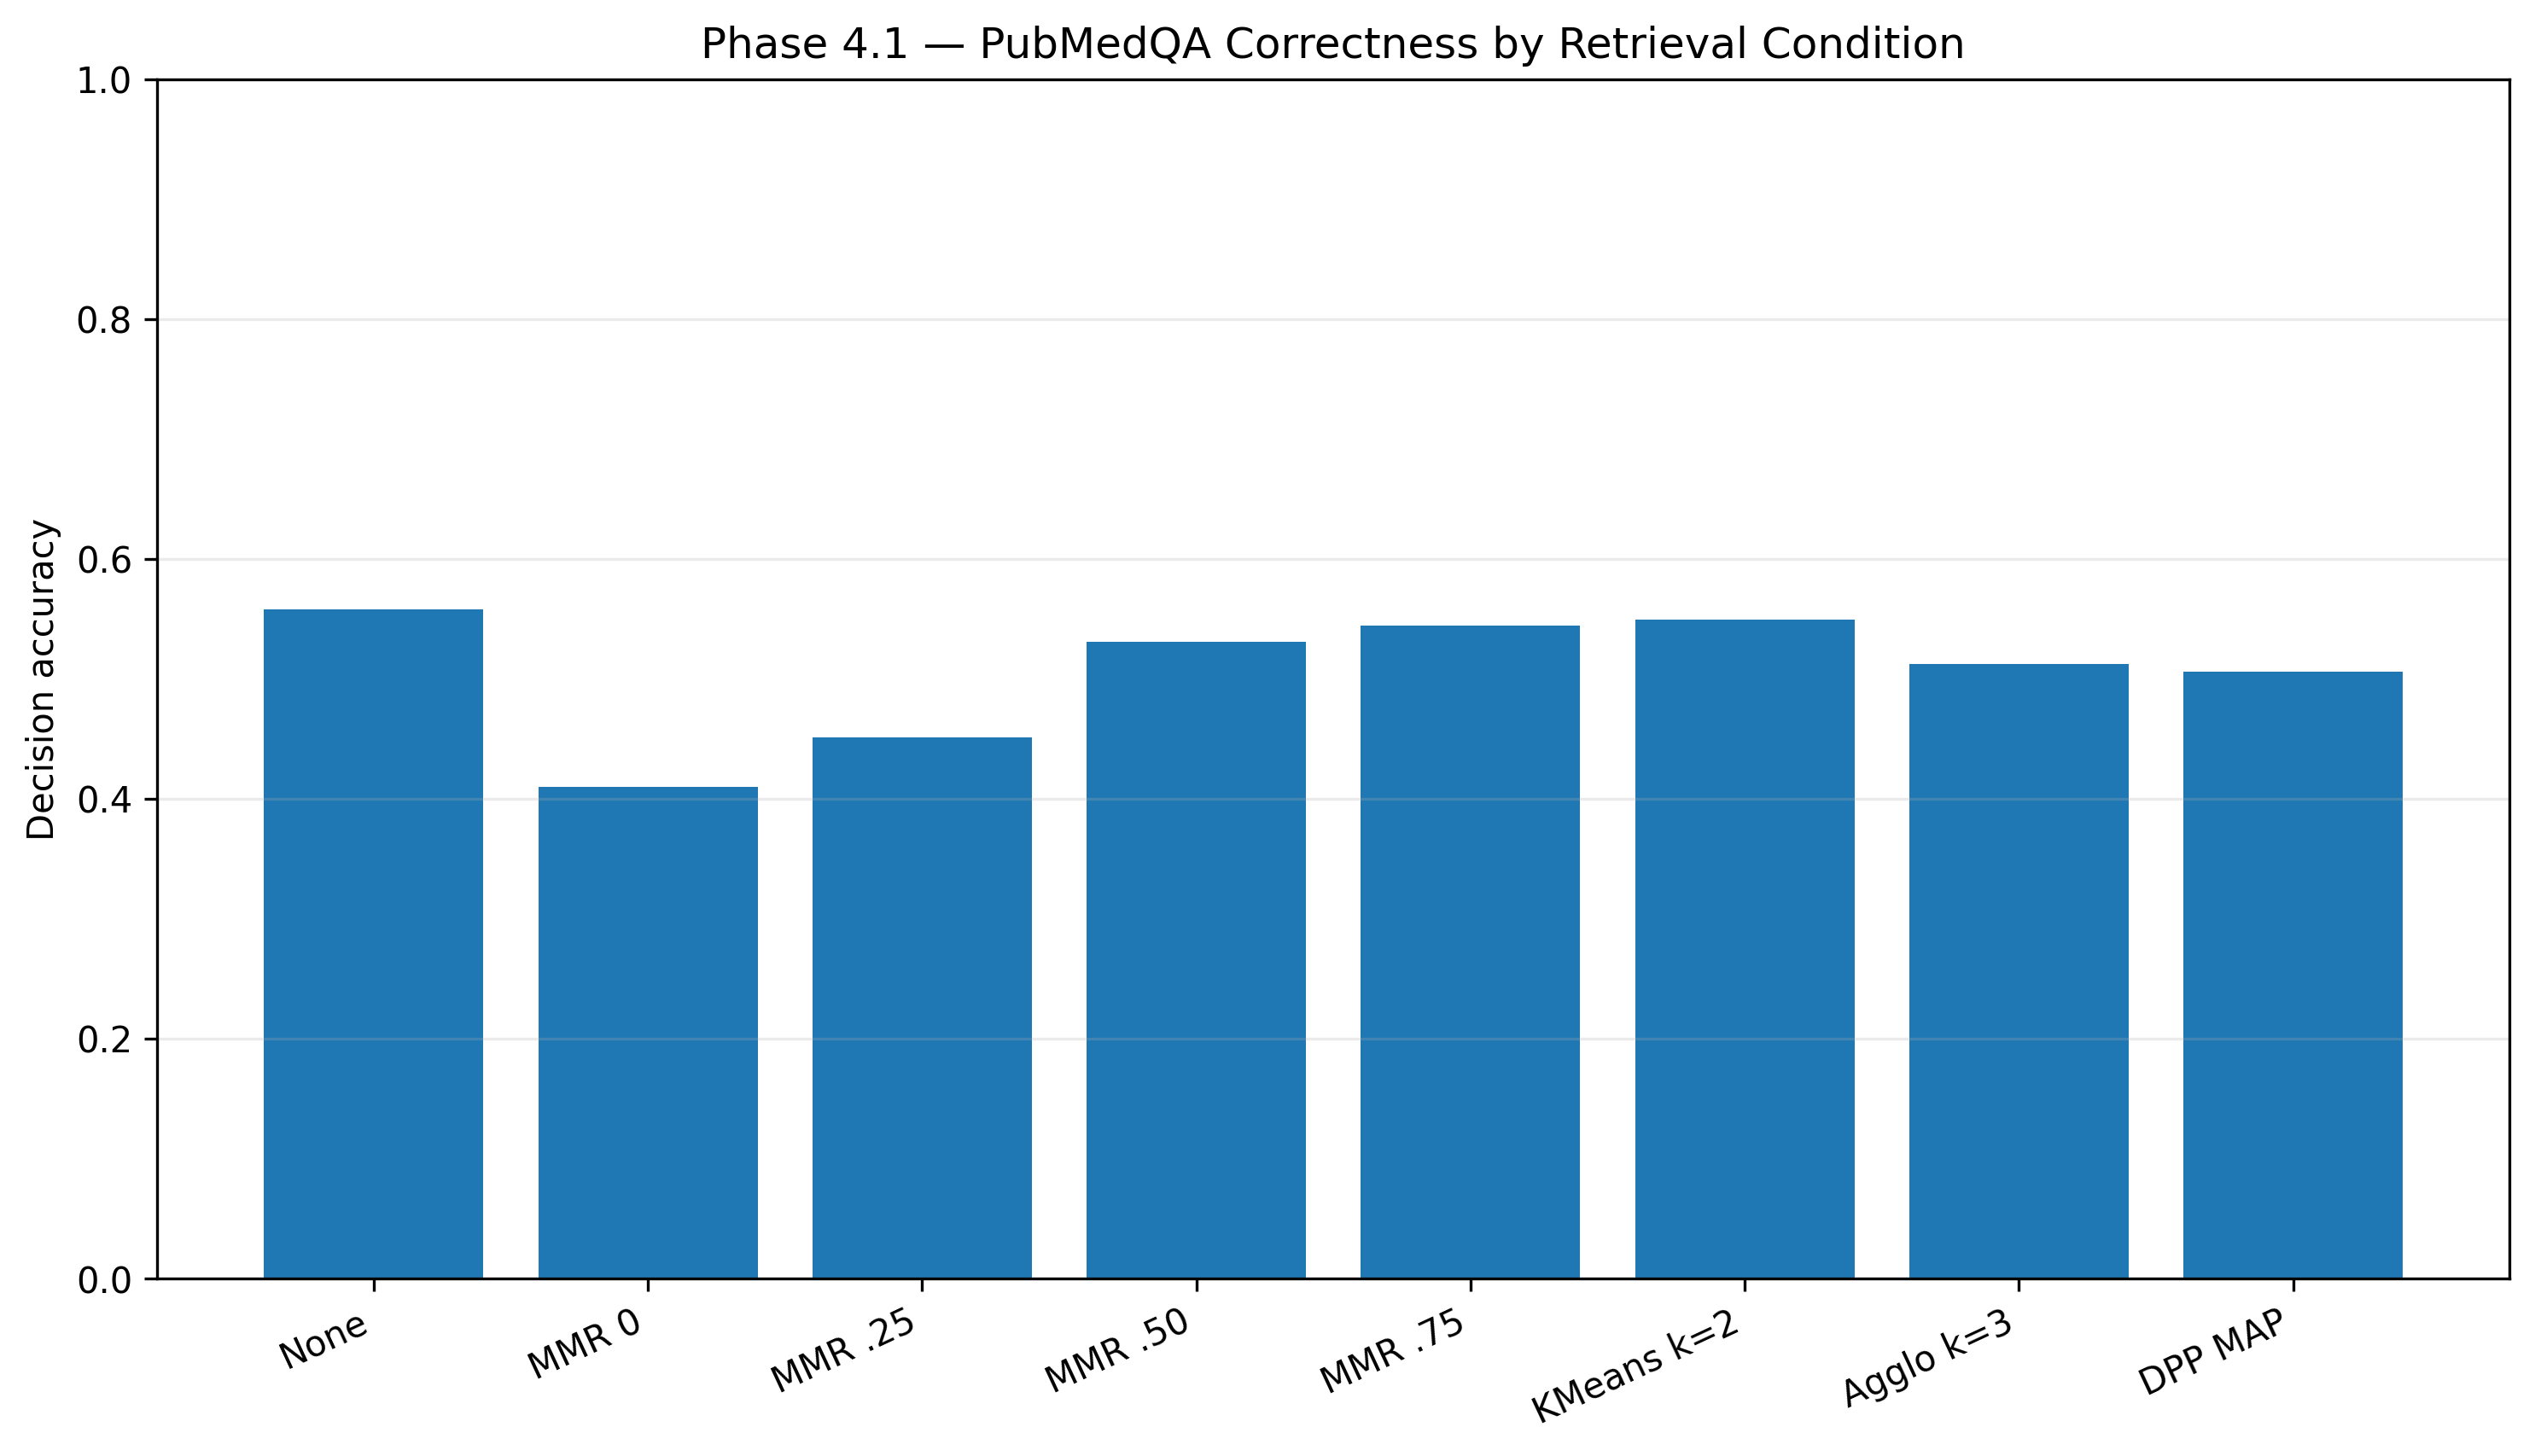

F02


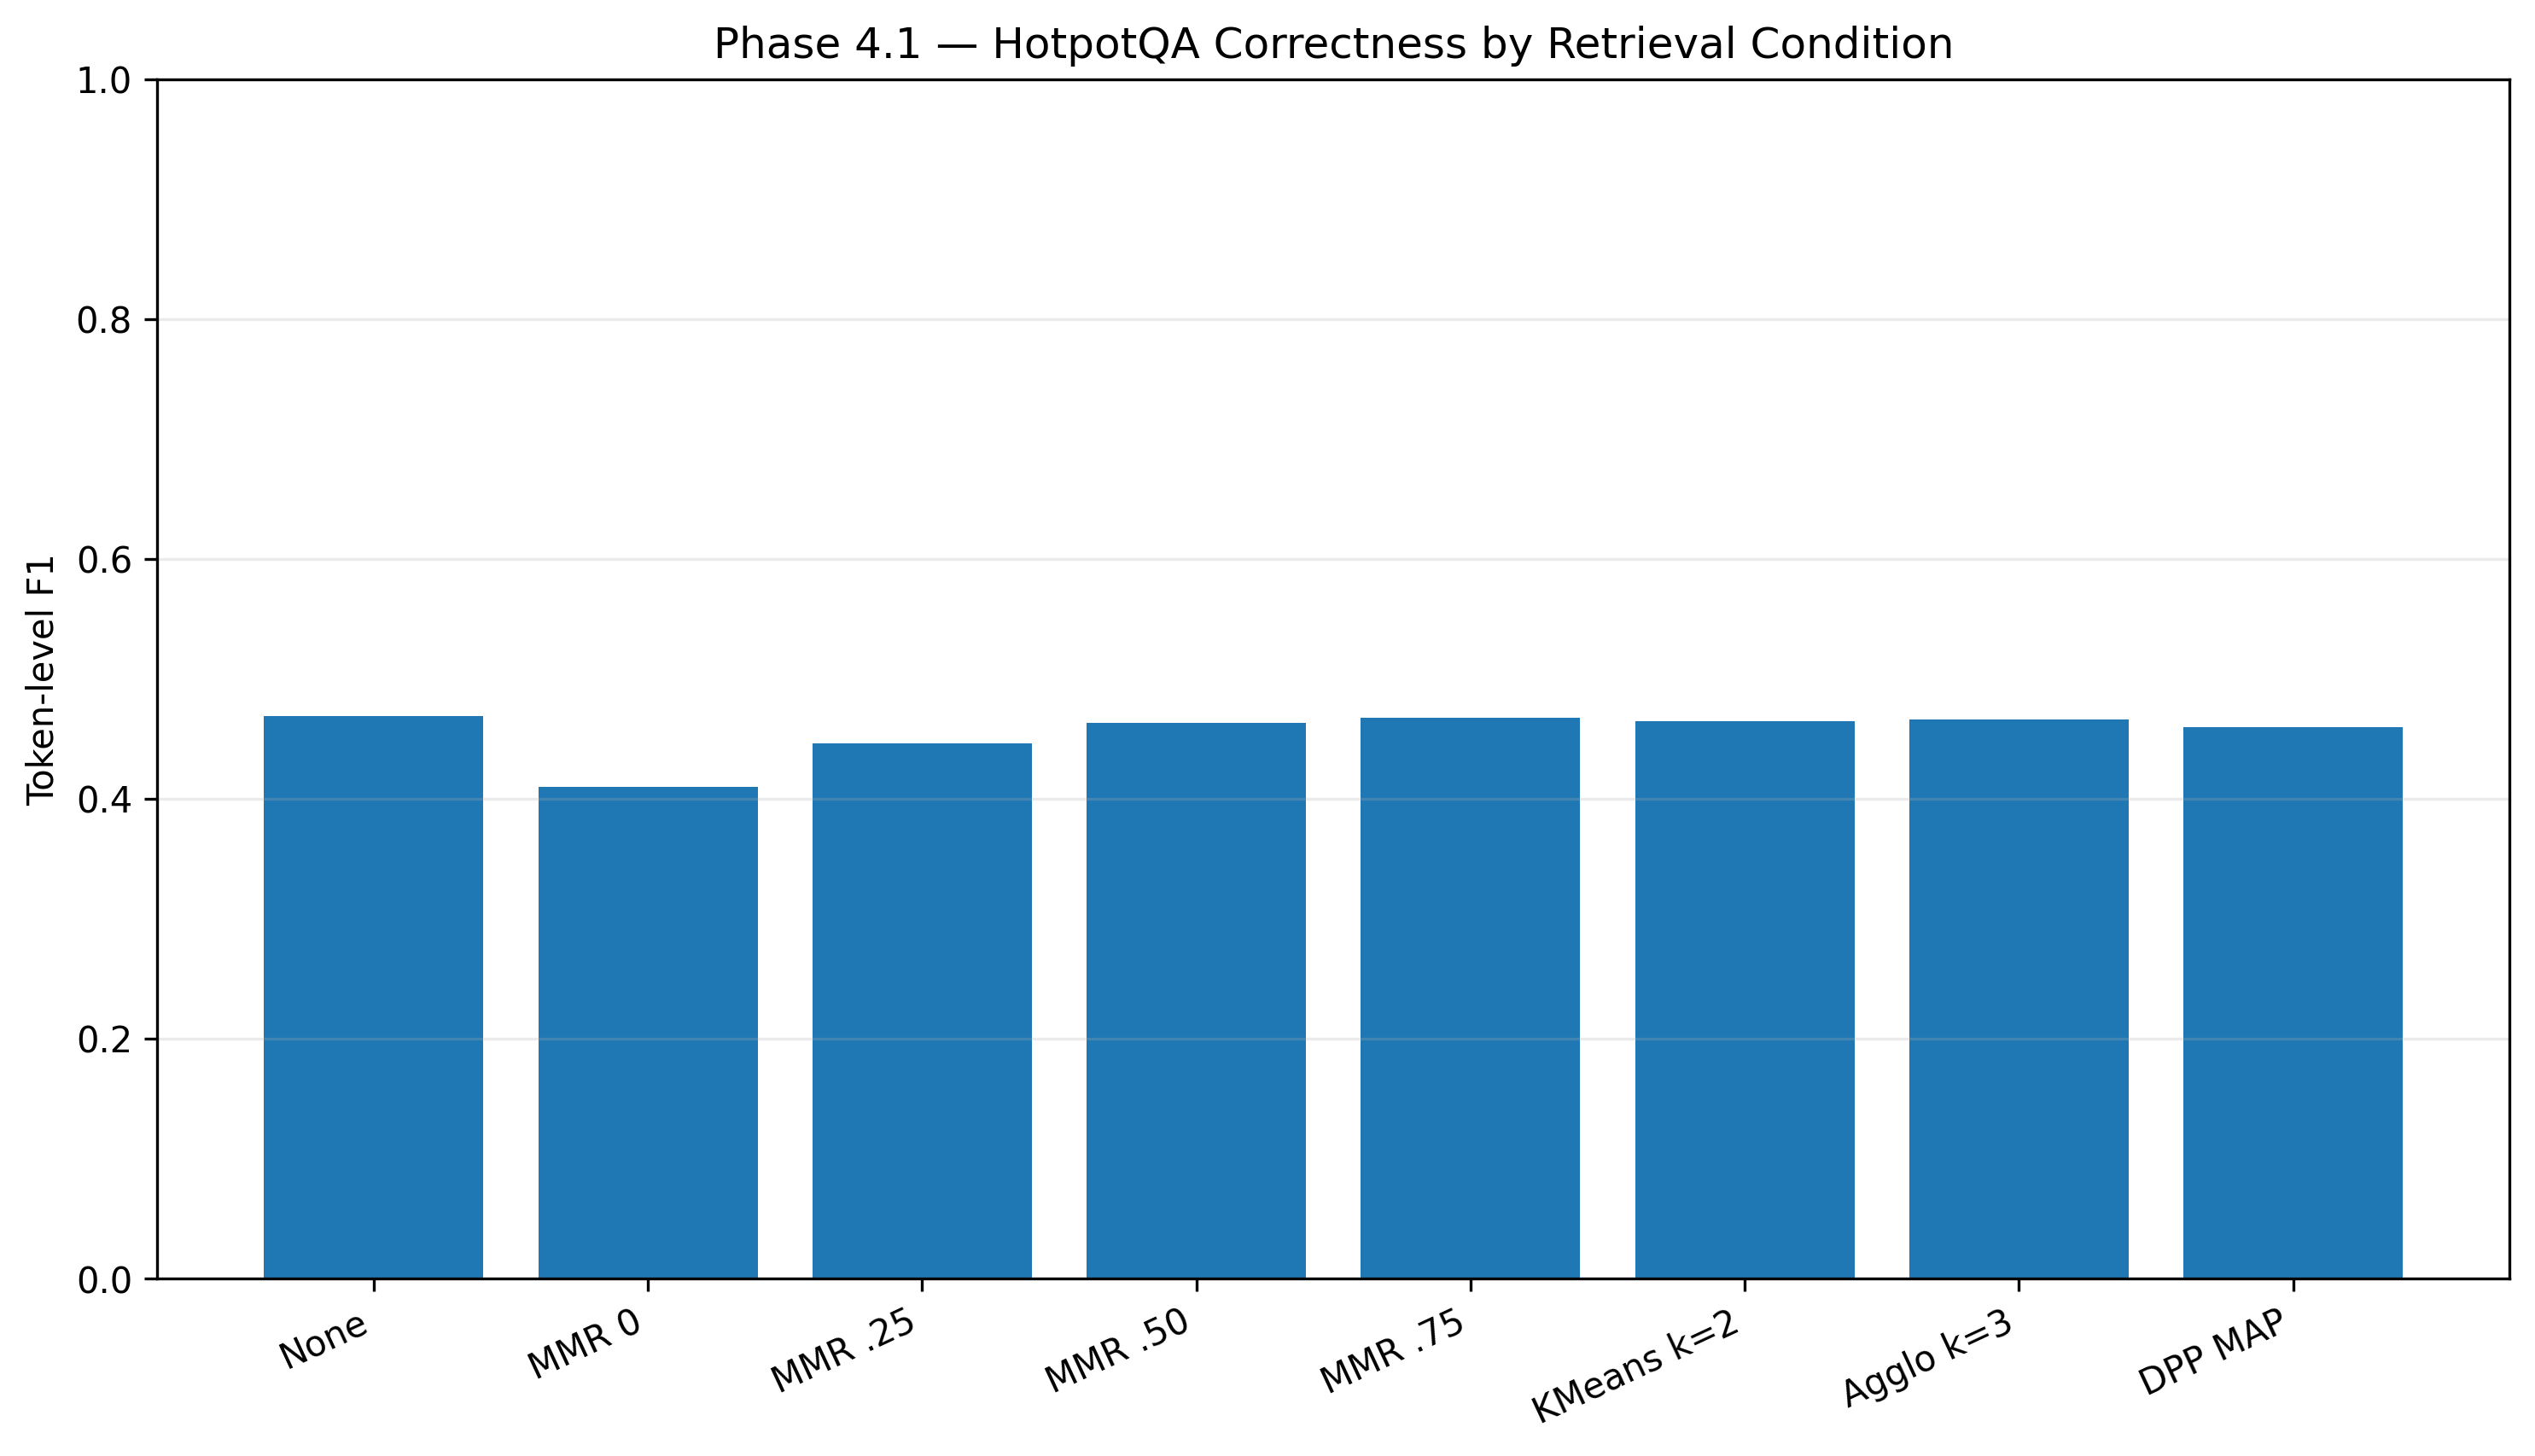

F03


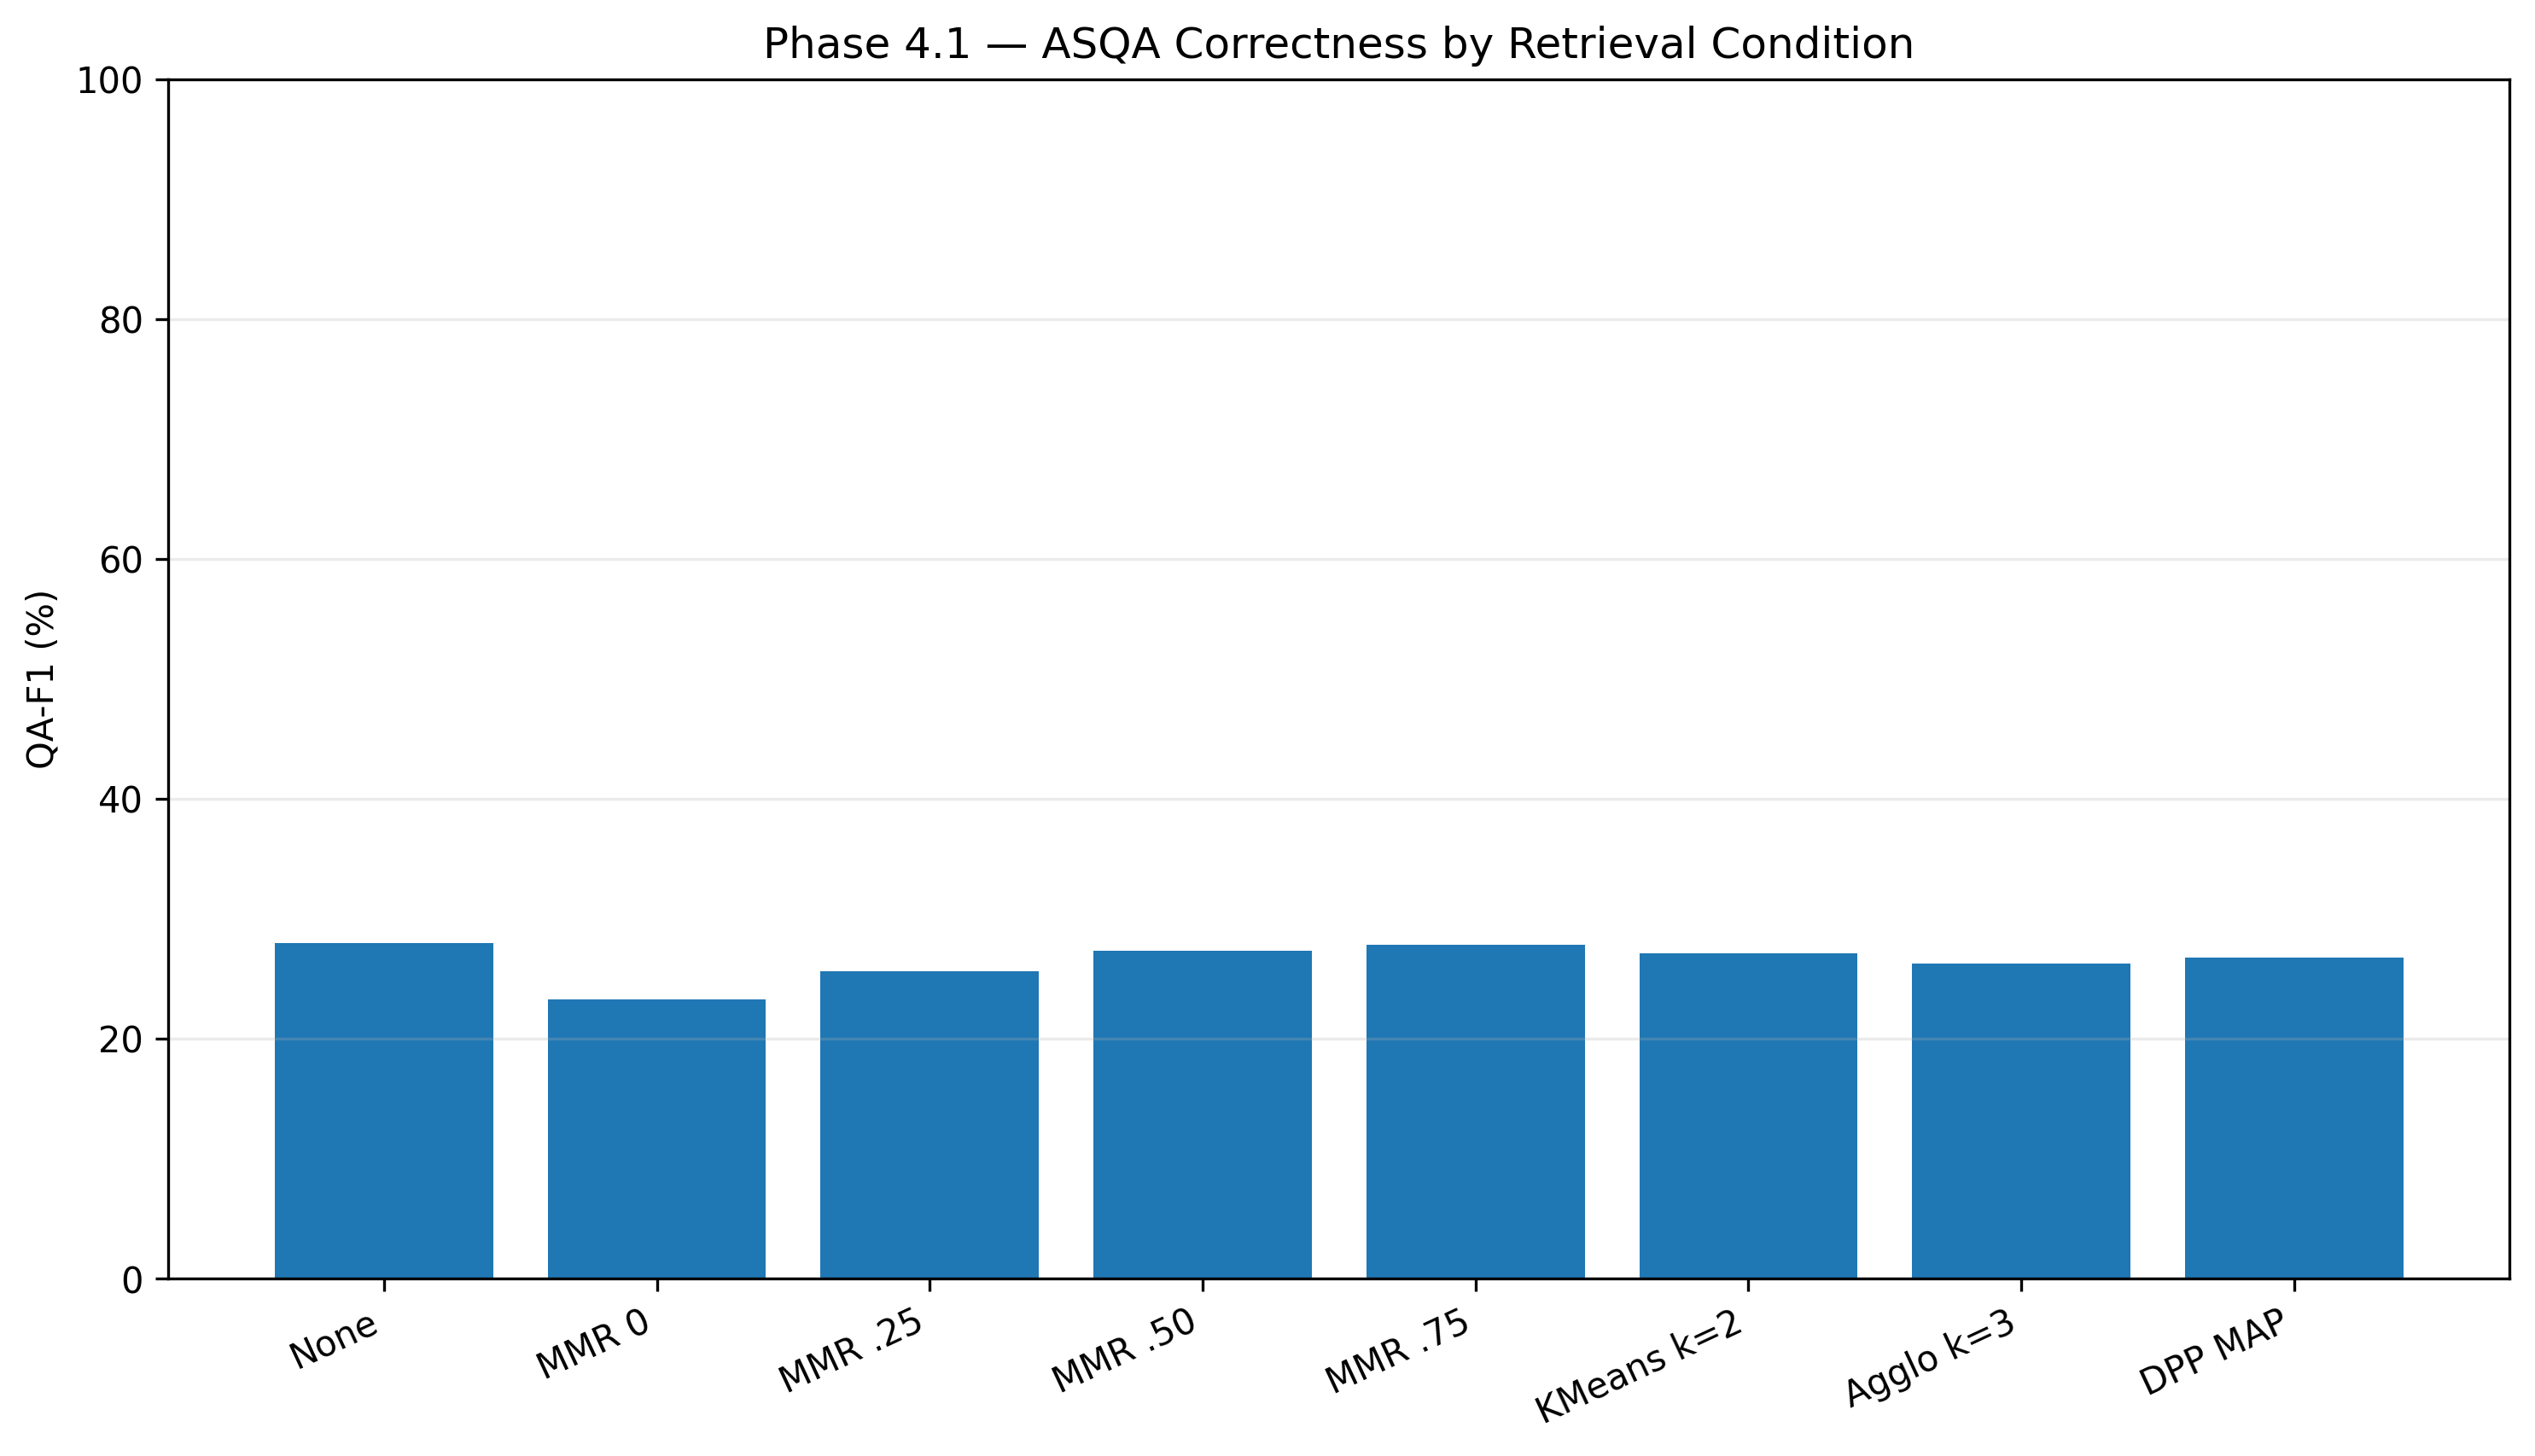

In [4]:
for fid in ["F01", "F02", "F03"]:
    print(fid)
    show_figure(fid)


F01–F03 show correctness across diversification conditions for PubMedQA, HotpotQA and ASQA.

The central observation is not a universal gain from diversification. The response depends on the dataset, retriever, generator and operating point.


### Generator-specific correctness views


F04


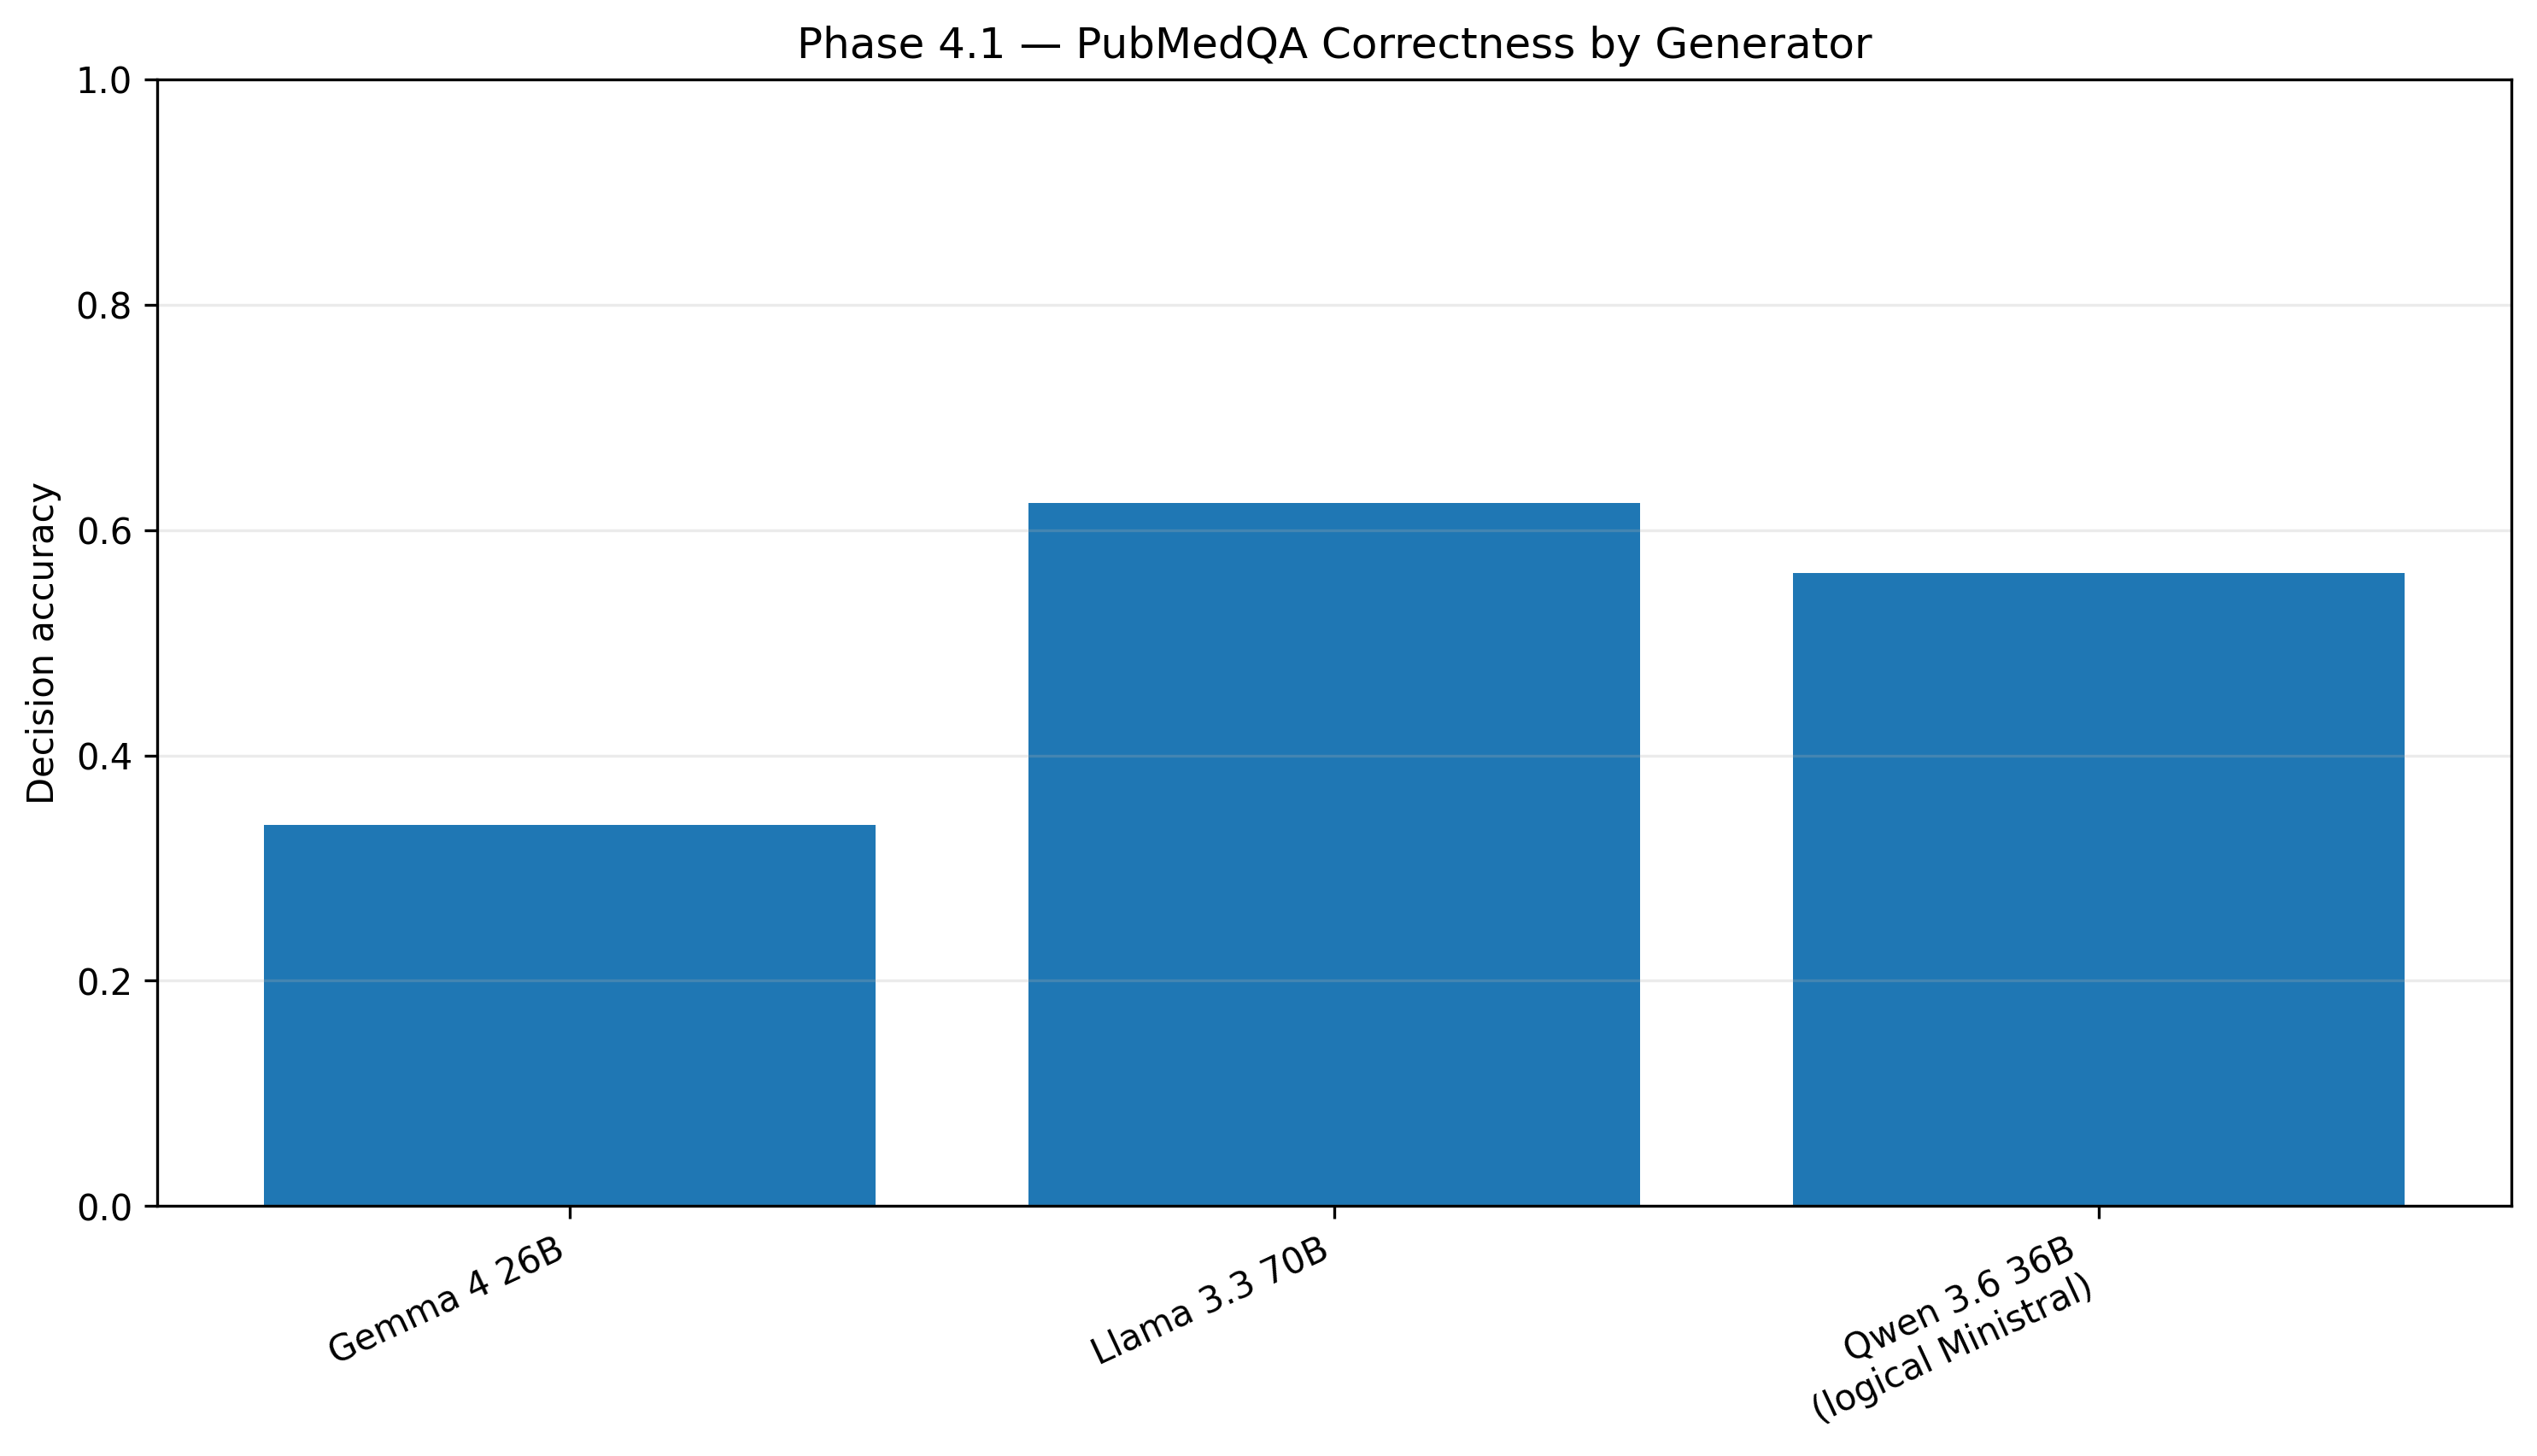

F05


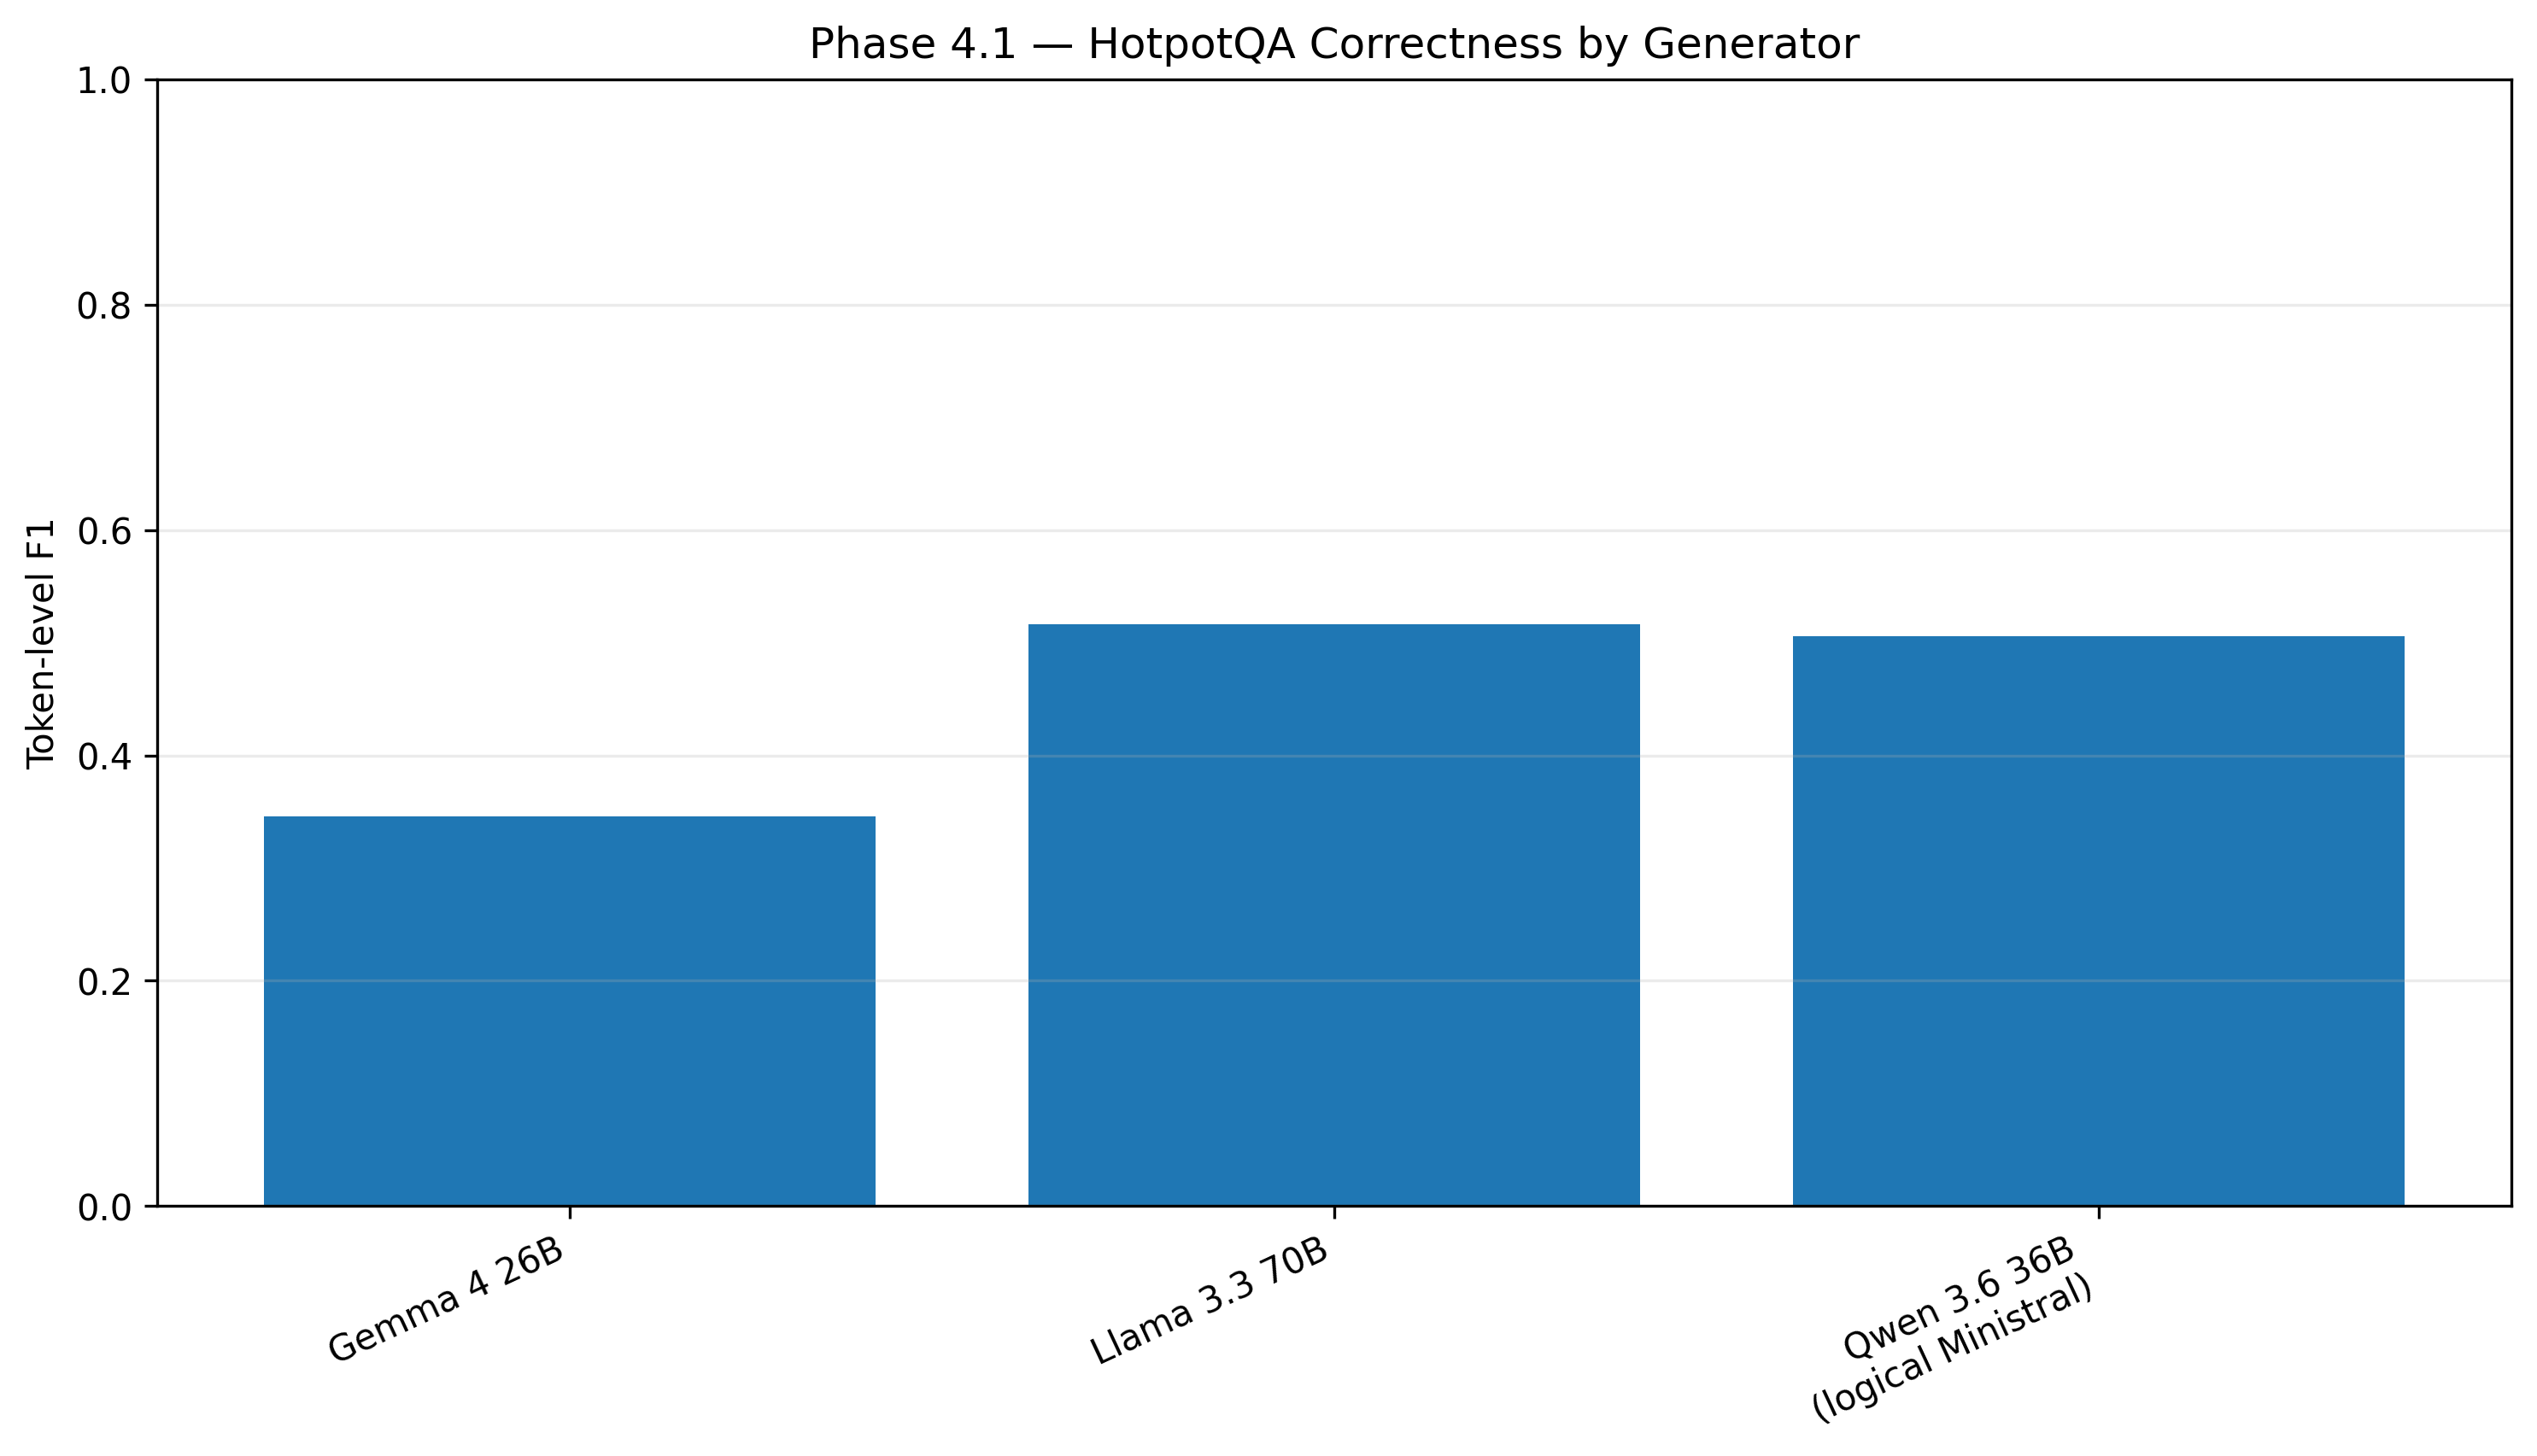

F06


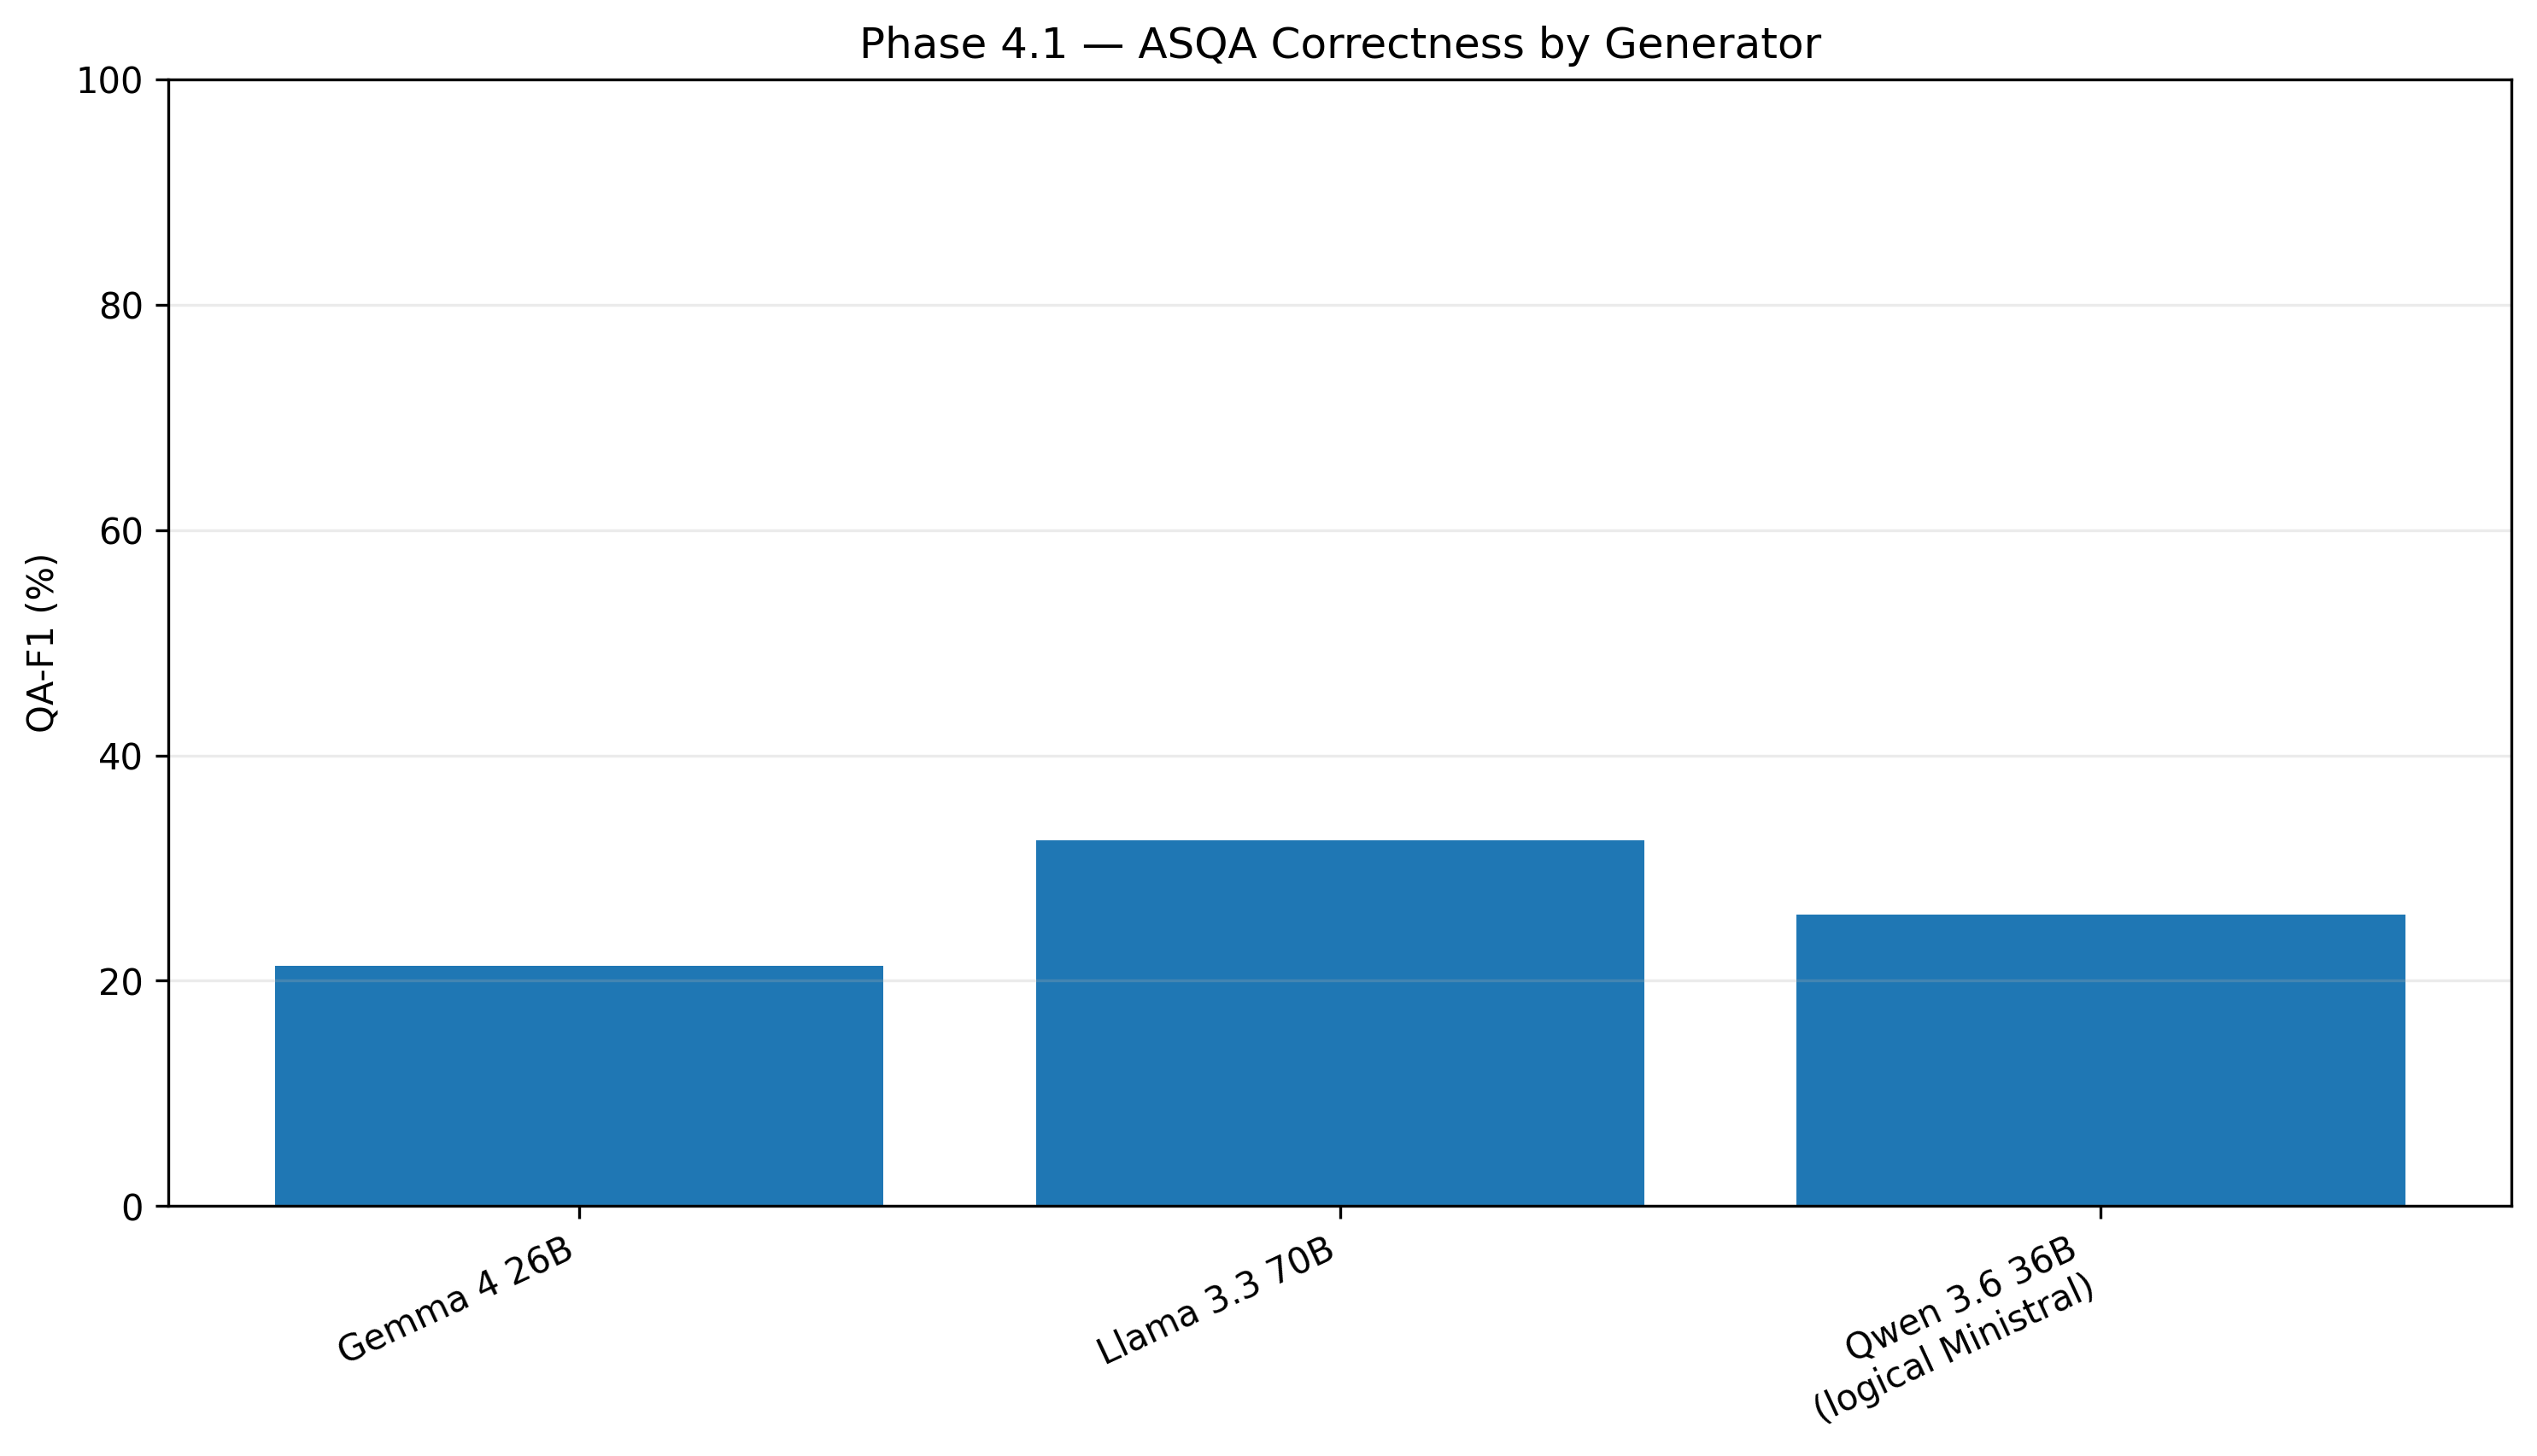

In [5]:
for fid in ["F04", "F05", "F06"]:
    print(fid)
    show_figure(fid)


## 4. Phase 4.2 — Faithfulness and hallucination

The final faithfulness/hallucination operating-point values are represented in the frozen Phase 5.2 reporting table because Phase 5.2 reuses the completed Phase 4.2 measurements for the diversity-versus-faithfulness analysis.


In [6]:
phase52 = load_csv("phase52_operating_point_summary.csv")

print("Frozen faithfulness/hallucination operating-point rows:", len(phase52))
display(phase52.head(15))


Frozen faithfulness/hallucination operating-point rows: 264


,dataset,retriever,condition,logical_model_id,physical_model_id,n,mean_retrieval_diversity,std_retrieval_diversity,mean_faithfulness,std_faithfulness,hallucination_rate,mean_supporting_source_count,mean_claim_count,mean_supported_claim_count
0,asqa,bm25,none,gemma4-26b,gemma4-26b,948,0.574373,0.113910,0.916235,0.242690,0.125527,2.600211,1.548523,1.396624
1,asqa,bm25,mmr_0,gemma4-26b,gemma4-26b,948,0.716571,0.077964,0.907050,0.253471,0.138186,2.454641,1.474684,1.310127
2,asqa,bm25,mmr_0.25,gemma4-26b,gemma4-26b,948,0.676818,0.087331,0.919989,0.242811,0.113924,2.486287,1.505274,1.374473
3,asqa,bm25,mmr_0.5,gemma4-26b,gemma4-26b,948,0.620776,0.105674,0.912060,0.251418,0.126582,2.549578,1.530591,1.373418
4,asqa,bm25,mmr_0.75,gemma4-26b,gemma4-26b,948,0.589559,0.111087,0.918548,0.239558,0.121308,2.597046,1.521097,1.374473
5,asqa,bm25,kmeans_k2,gemma4-26b,gemma4-26b,948,0.603606,0.105114,0.904688,0.268719,0.126582,2.520042,1.492616,1.337553
6,asqa,bm25,agglo_k3,gemma4-26b,gemma4-26b,948,0.614459,0.093493,0.902866,0.263973,0.136076,2.456751,1.506329,1.330169
7,asqa,bm25,dpp_map,gemma4-26b,gemma4-26b,948,0.645566,0.087766,0.918714,0.240535,0.119198,2.503165,1.544304,1.401899
8,asqa,bm25,none,llama-3.3-70b,llama-3.3-70b,944,0.574395,0.113751,0.869048,0.259917,0.263771,2.972458,3.106992,2.670551
9,asqa,bm25,mmr_0,llama-3.3-70b,llama-3.3-70b,947,0.716494,0.077969,0.870204,0.260654,0.258712,2.855333,3.025343,2.613516


F07


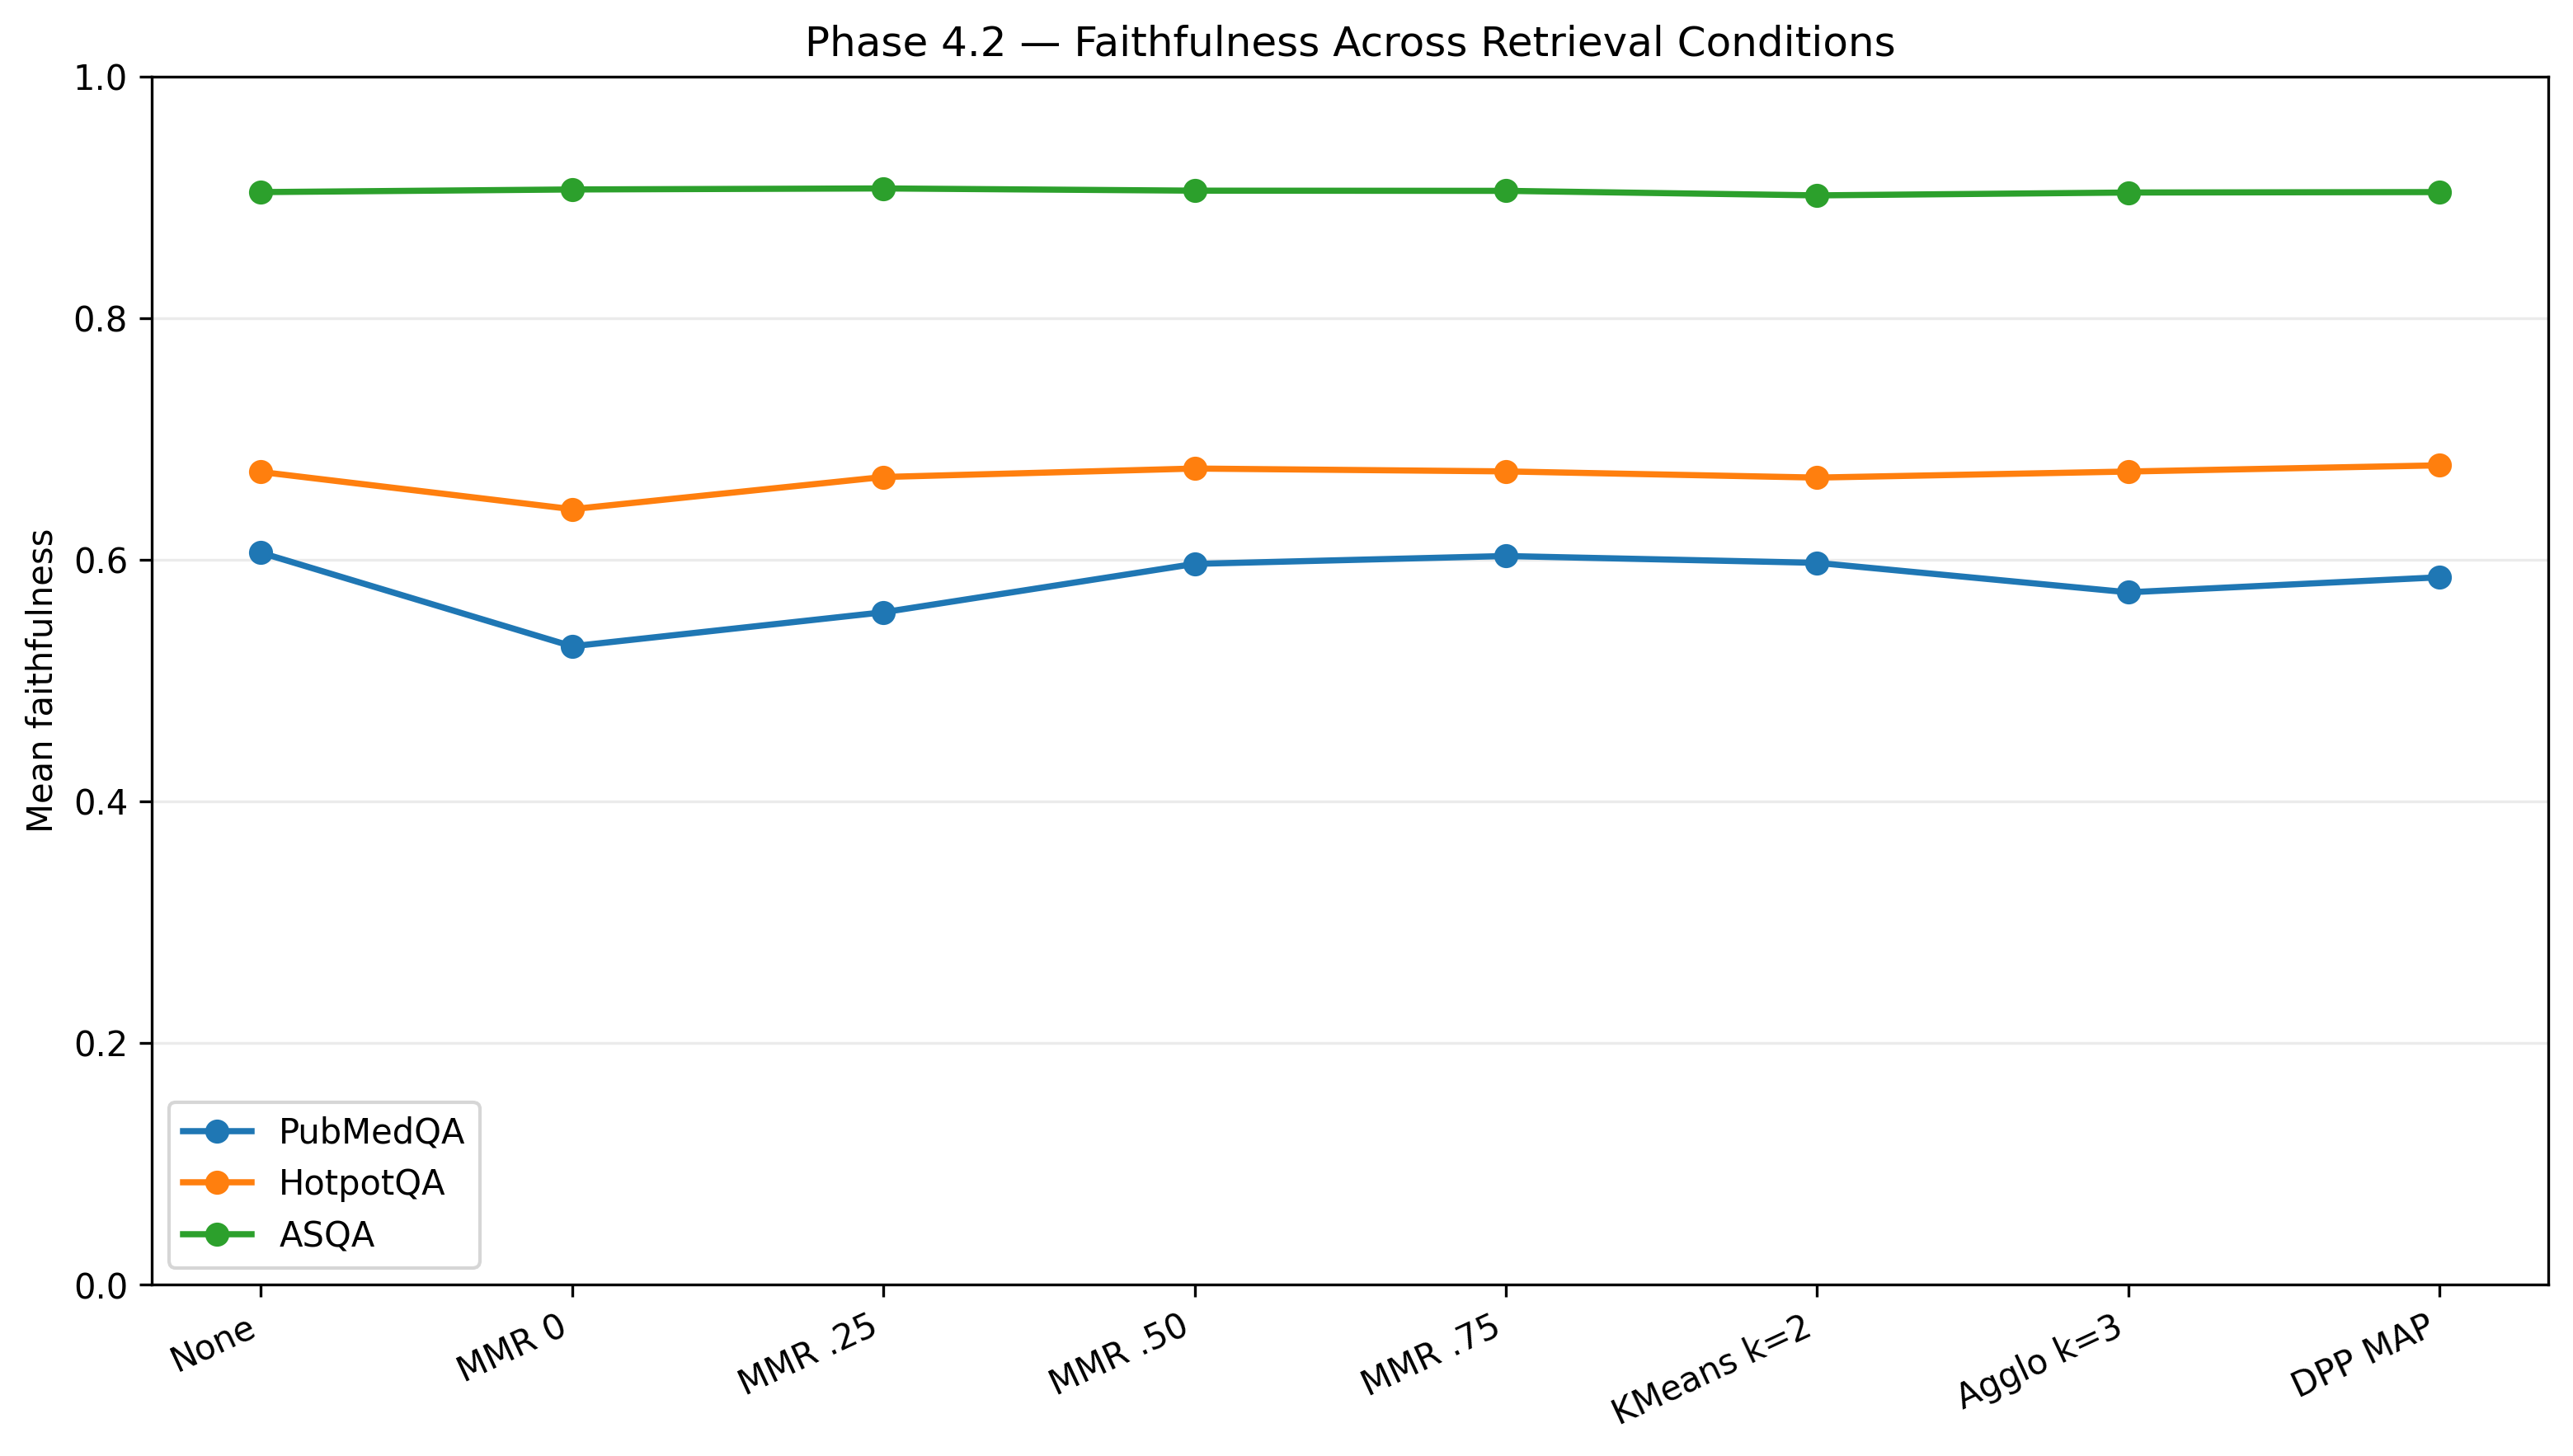

F08


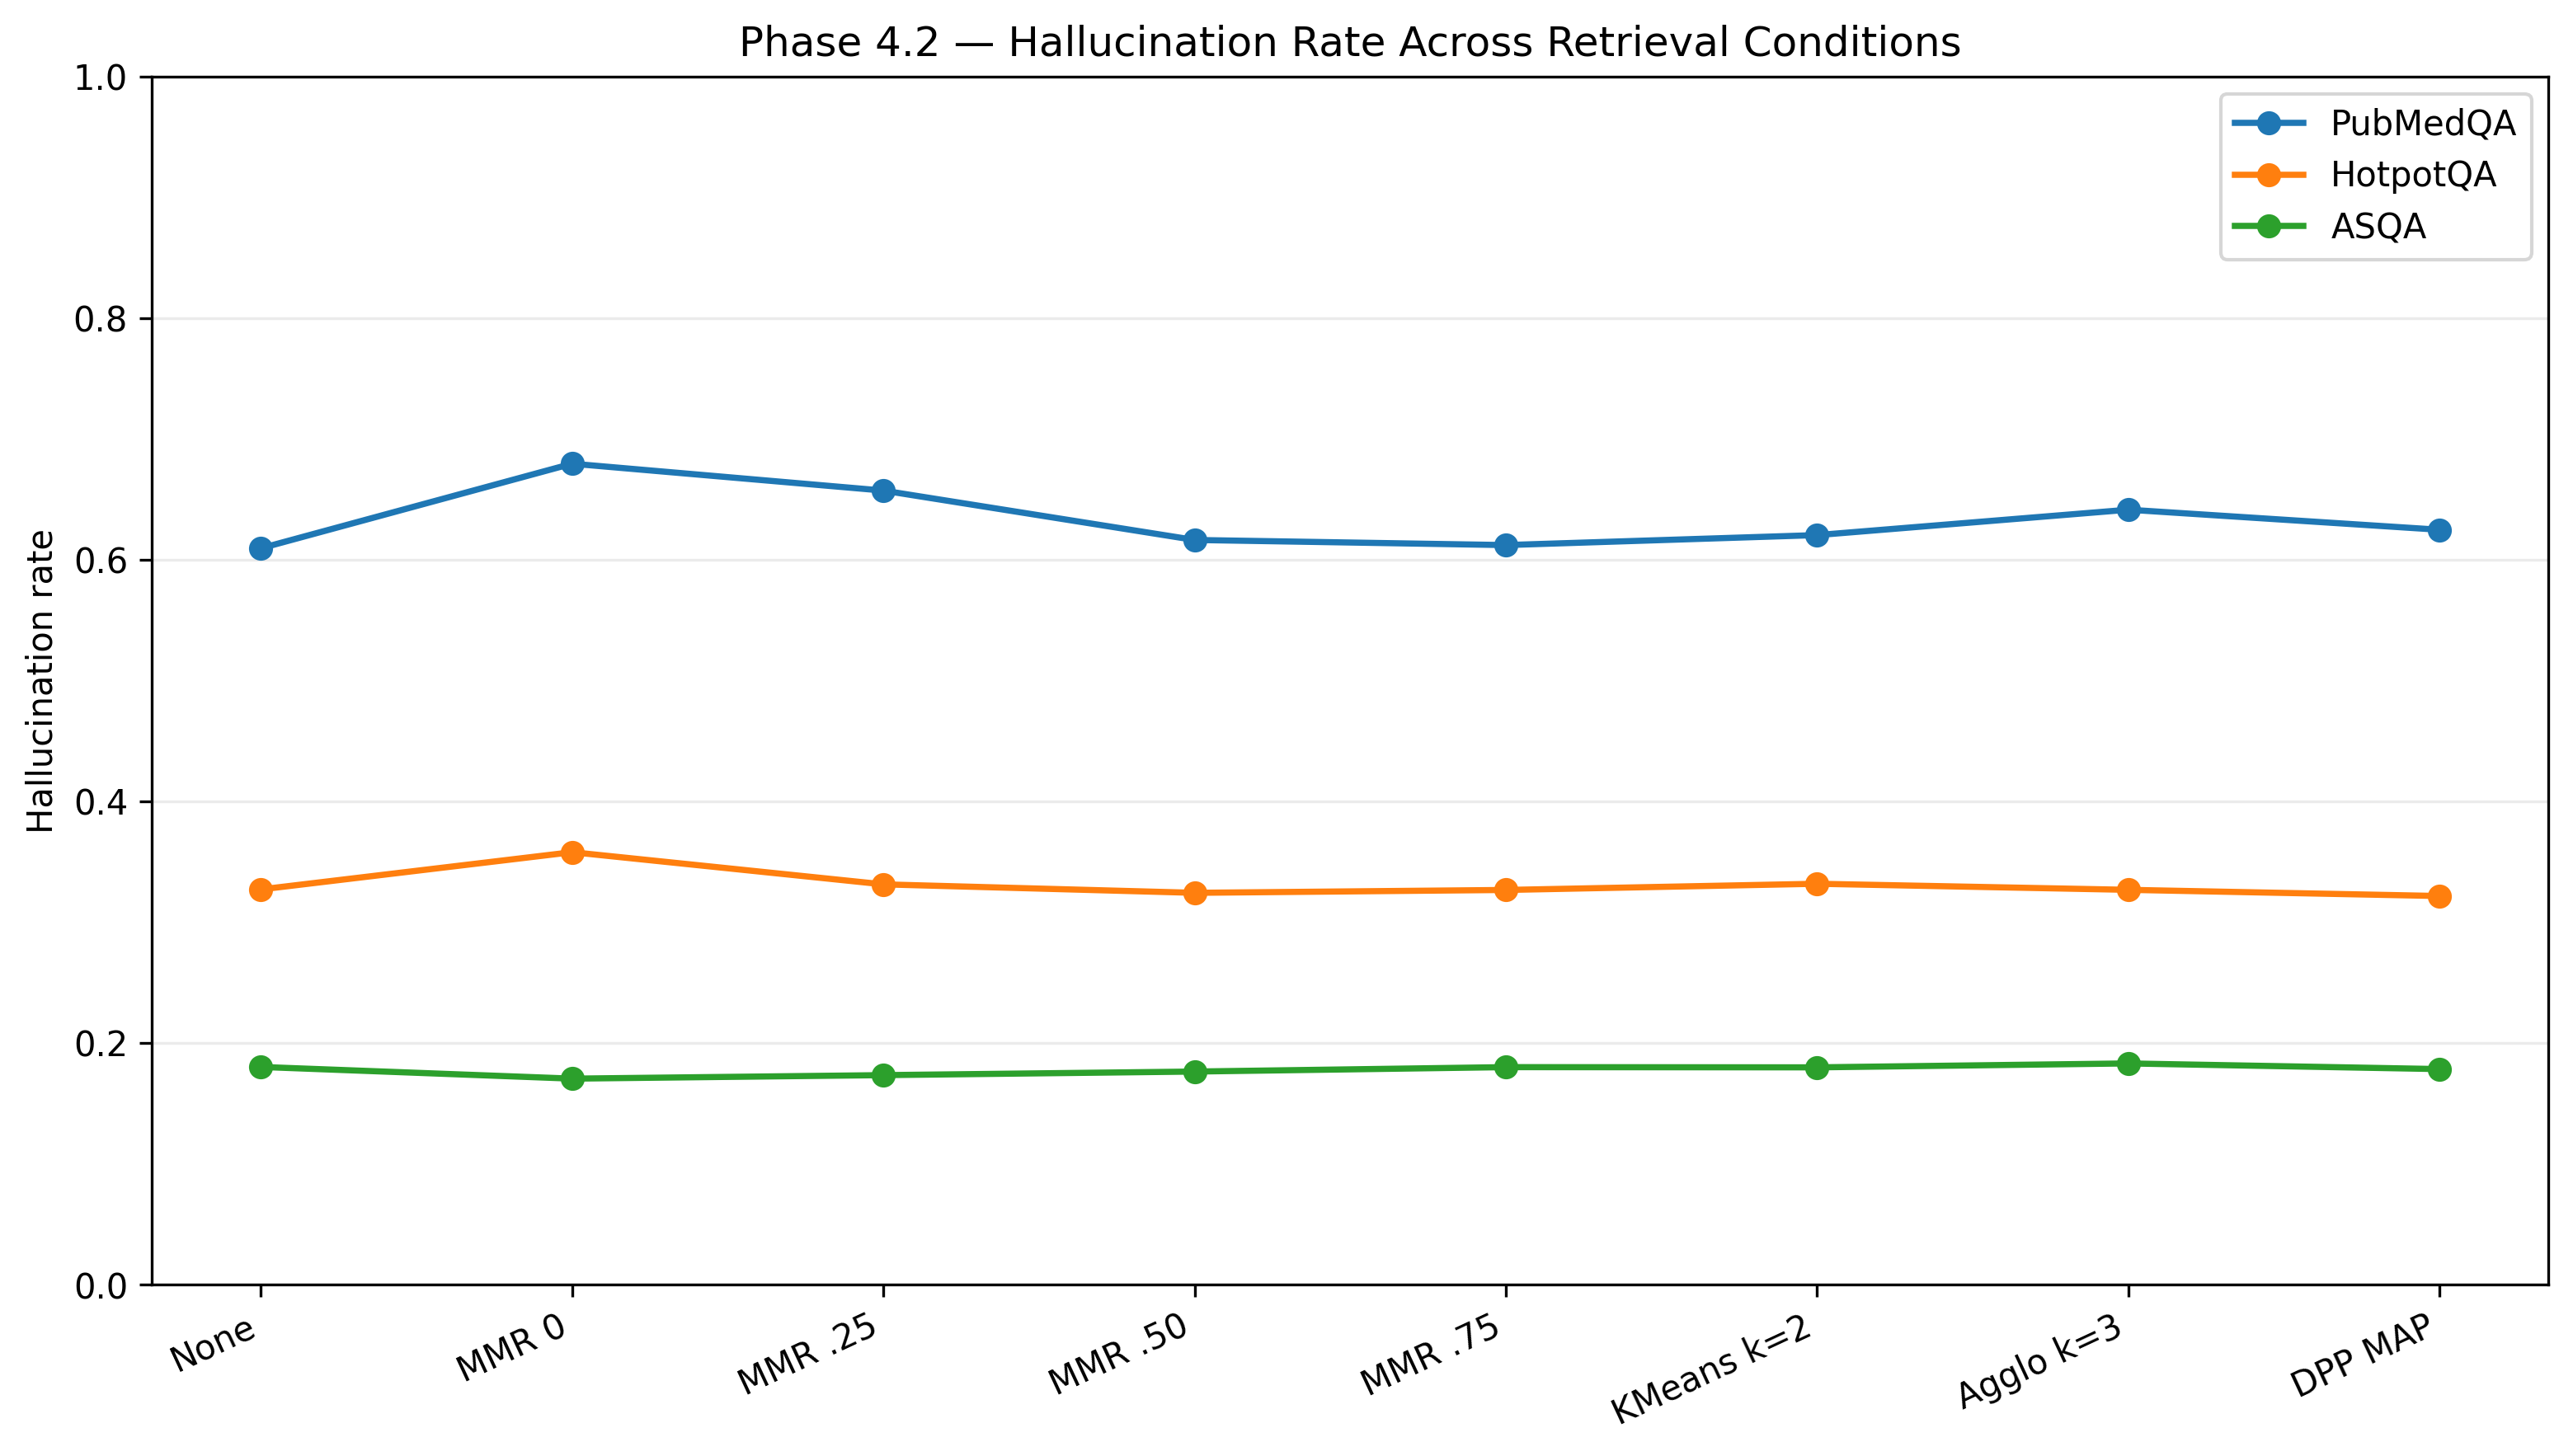

F09


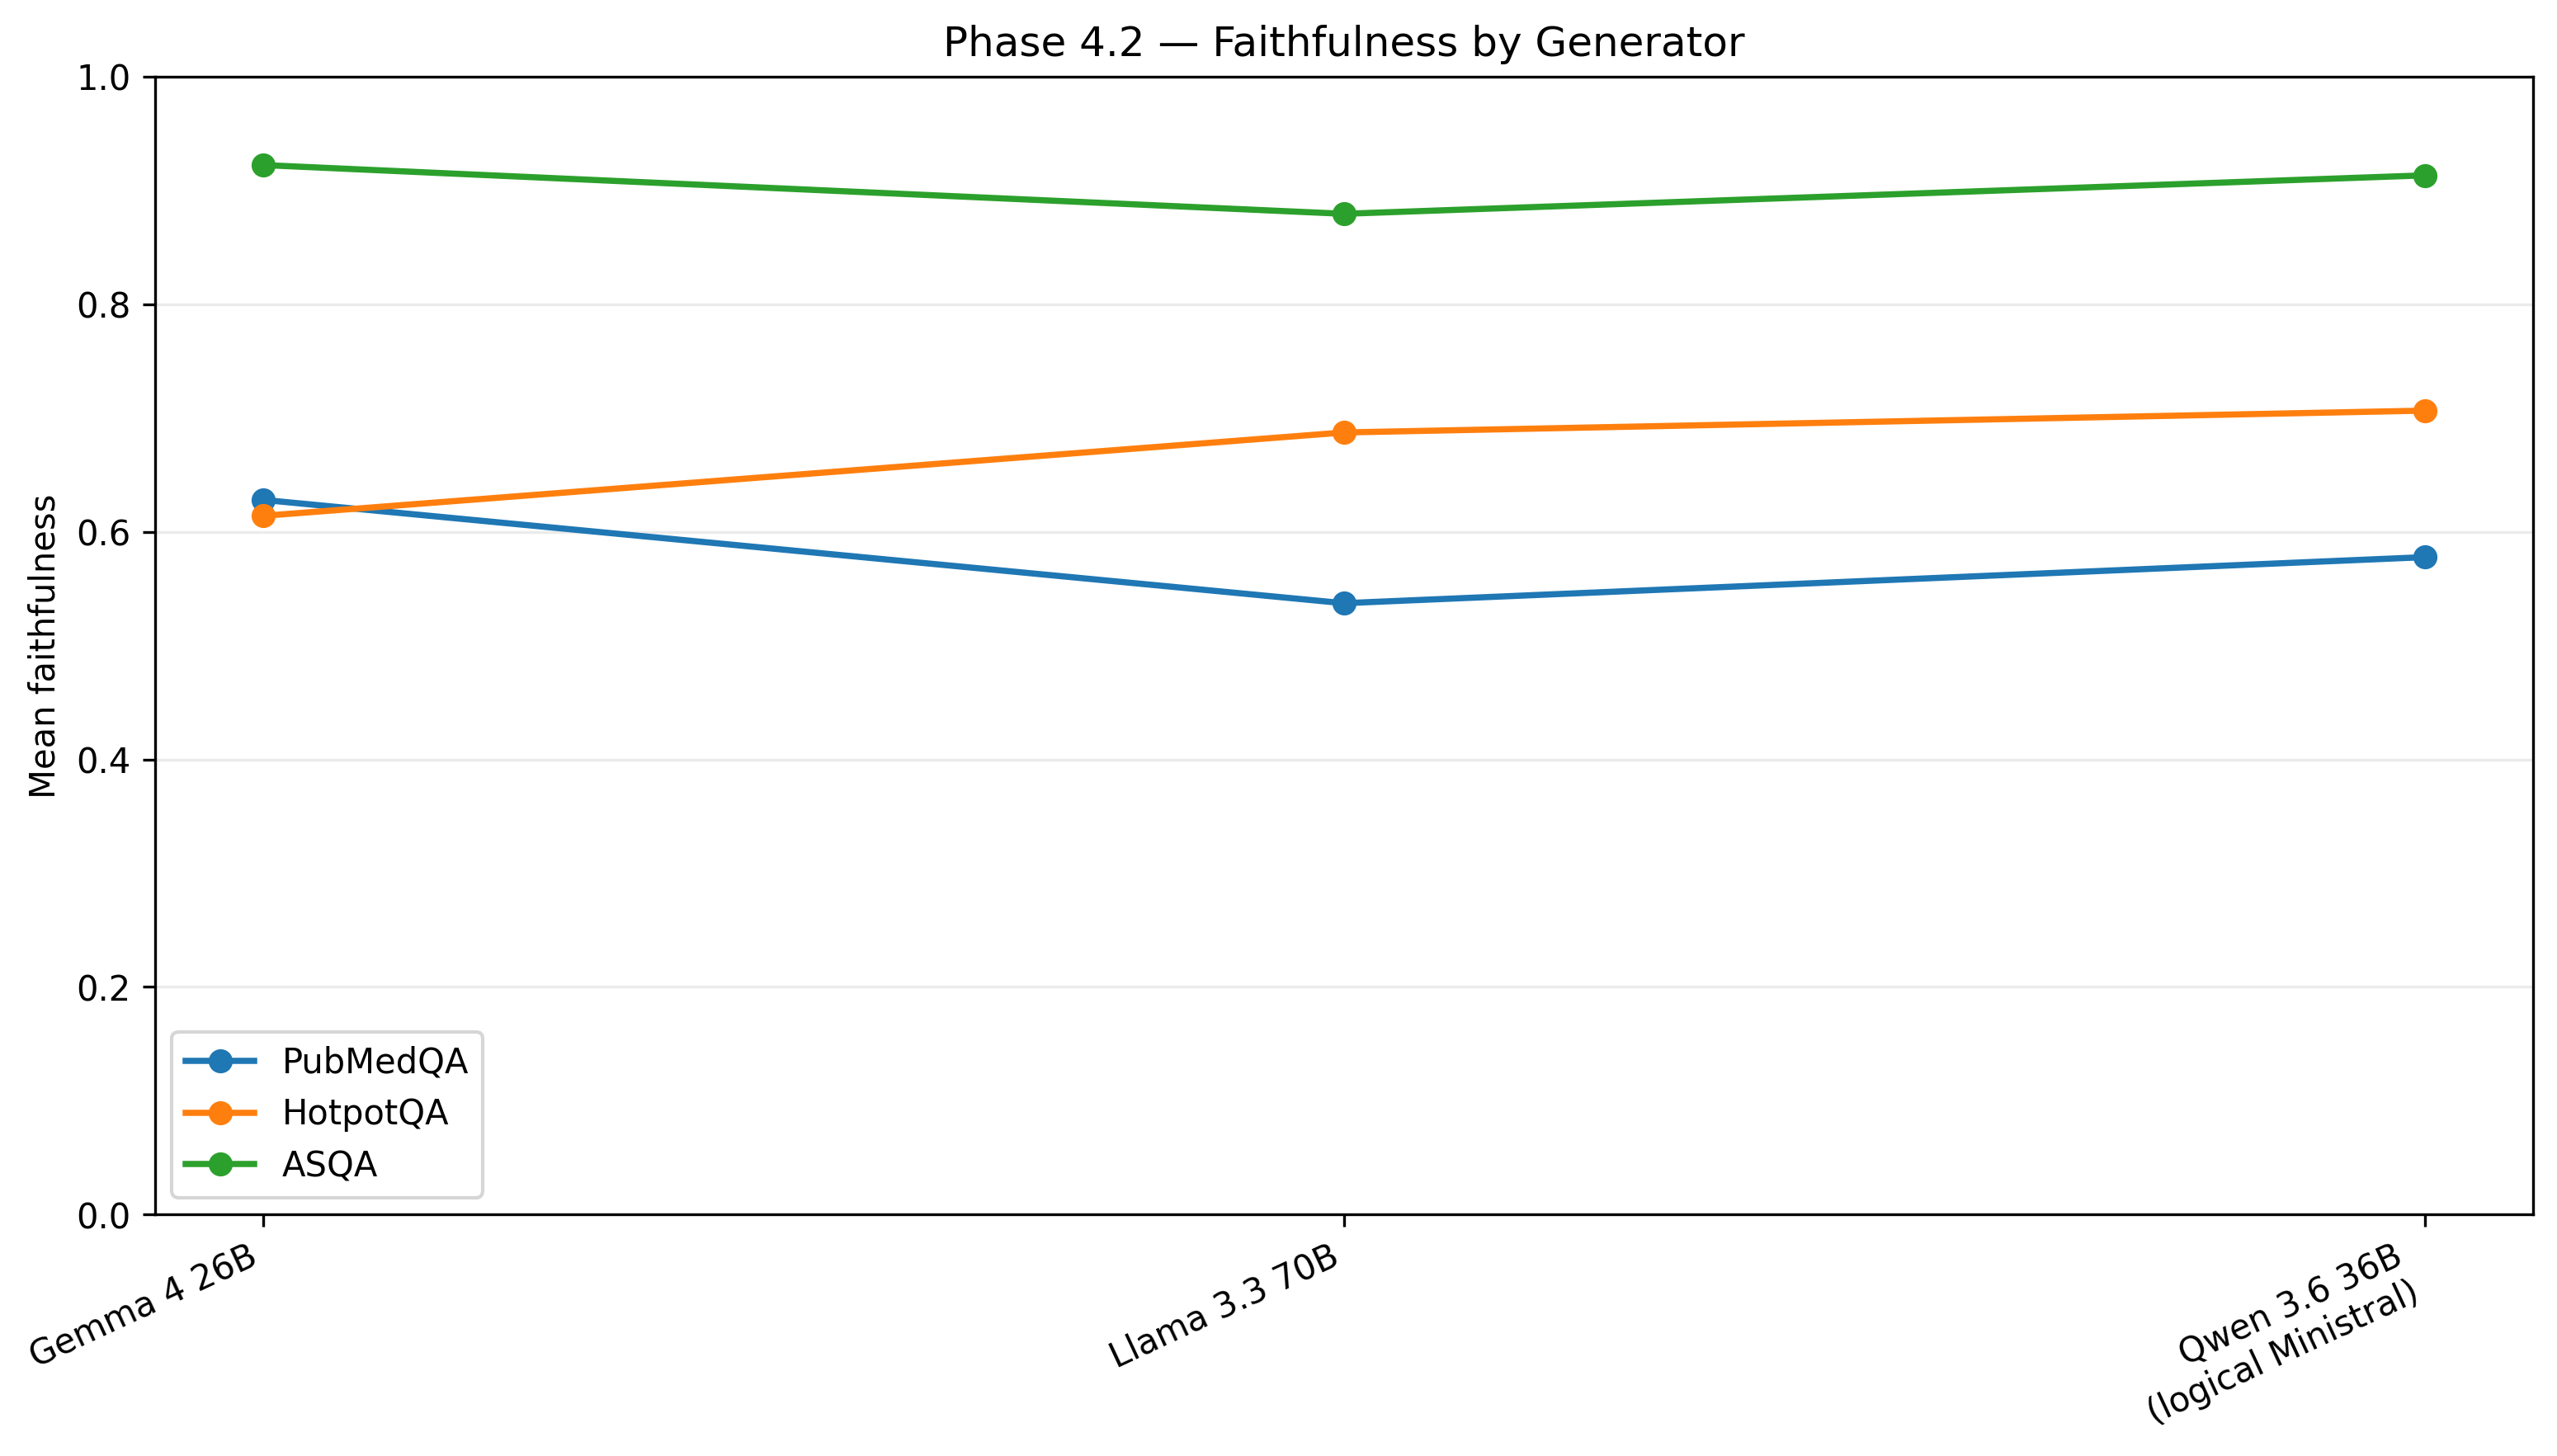

F10


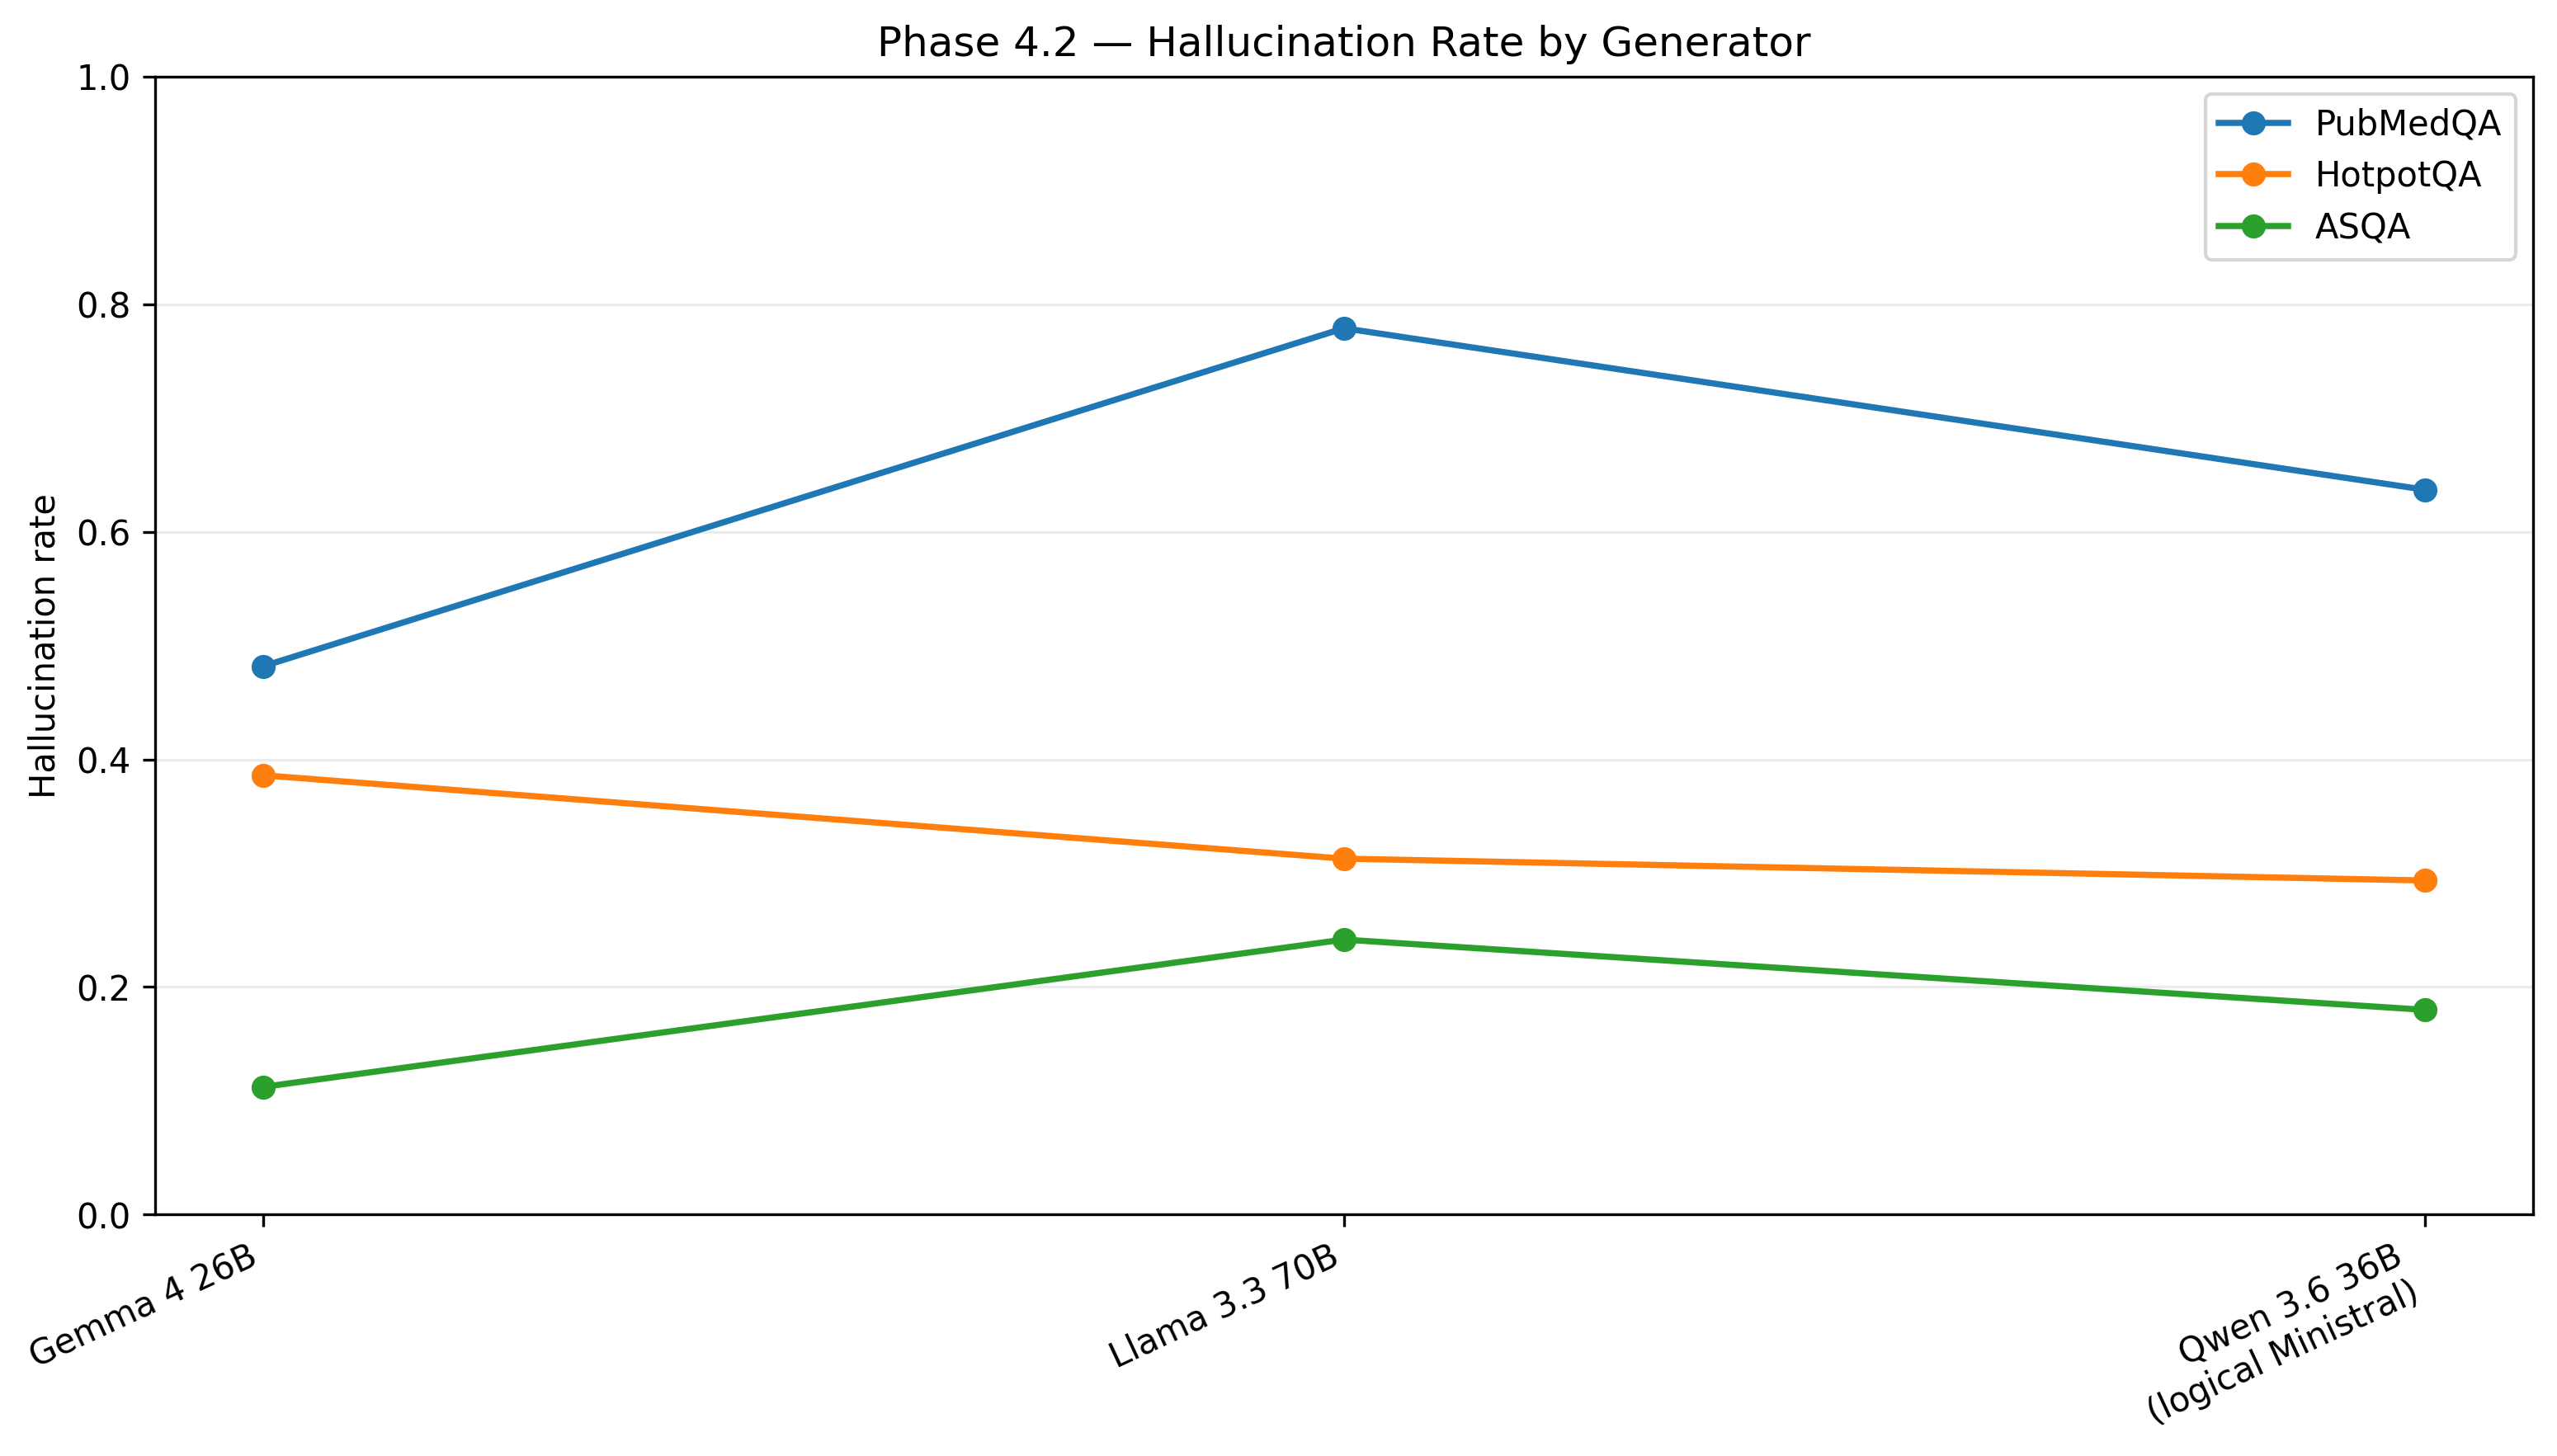

In [7]:
for fid in ["F07", "F08", "F09", "F10"]:
    print(fid)
    show_figure(fid)


The frozen results do not support a claim that diversification consistently improves faithfulness or consistently reduces hallucination.

Effects vary across configurations, and the paired analysis later in this notebook is the more defensible intervention comparison.


## 5. Phase 4.3 — Coverage


In [8]:
pqa_coverage = load_csv("pubmedqa_coverage_summary.csv")
hotpot_coverage = load_csv("hotpotqa_coverage_summary.csv")
asqa_coverage = load_csv("asqa_coverage_summary.csv")

display(pqa_coverage.head(12))
display(hotpot_coverage.head(12))
display(asqa_coverage.head(12))


,dataset,retriever,condition,n,coverage_metric,coverage_value,secondary_metric,secondary_value
0,pubmedqa,bm25,agglo_k3,1000,gold_document_recall_at_5,0.491823,mrr_at_5,0.906567
1,pubmedqa,bm25,dpp_map,1000,gold_document_recall_at_5,0.430894,mrr_at_5,0.911967
2,pubmedqa,bm25,kmeans_k2,1000,gold_document_recall_at_5,0.574450,mrr_at_5,0.908550
3,pubmedqa,bm25,mmr_0,1000,gold_document_recall_at_5,0.285313,mrr_at_5,0.890567
4,pubmedqa,bm25,mmr_0.25,1000,gold_document_recall_at_5,0.333642,mrr_at_5,0.906850
5,pubmedqa,bm25,mmr_0.5,1000,gold_document_recall_at_5,0.489363,mrr_at_5,0.912467
6,pubmedqa,bm25,mmr_0.75,1000,gold_document_recall_at_5,0.568955,mrr_at_5,0.912017
7,pubmedqa,bm25,none,1000,gold_document_recall_at_5,0.599211,mrr_at_5,0.911517
8,pubmedqa,colbertv2,agglo_k3,1000,gold_document_recall_at_5,0.574646,mrr_at_5,0.974567
9,pubmedqa,colbertv2,dpp_map,1000,gold_document_recall_at_5,0.567894,mrr_at_5,0.977117


,dataset,retriever,condition,n,coverage_metric,coverage_value,secondary_metric,secondary_value
0,hotpotqa,bm25,agglo_k3,7405,supporting_document_recall_at_5,0.423363,both_supporting_documents_retrieved_rate,0.141121
1,hotpotqa,bm25,dpp_map,7405,supporting_document_recall_at_5,0.417556,both_supporting_documents_retrieved_rate,0.125321
2,hotpotqa,bm25,kmeans_k2,7405,supporting_document_recall_at_5,0.427616,both_supporting_documents_retrieved_rate,0.146928
3,hotpotqa,bm25,mmr_0,7405,supporting_document_recall_at_5,0.327819,both_supporting_documents_retrieved_rate,0.027954
4,hotpotqa,bm25,mmr_0.25,7405,supporting_document_recall_at_5,0.391425,both_supporting_documents_retrieved_rate,0.094126
5,hotpotqa,bm25,mmr_0.5,7405,supporting_document_recall_at_5,0.427009,both_supporting_documents_retrieved_rate,0.139095
6,hotpotqa,bm25,mmr_0.75,7405,supporting_document_recall_at_5,0.435854,both_supporting_documents_retrieved_rate,0.152600
7,hotpotqa,bm25,none,7405,supporting_document_recall_at_5,0.437272,both_supporting_documents_retrieved_rate,0.155300
8,hotpotqa,colbertv2,agglo_k3,7405,supporting_document_recall_at_5,0.622485,both_supporting_documents_retrieved_rate,0.320729
9,hotpotqa,colbertv2,dpp_map,7405,supporting_document_recall_at_5,0.609251,both_supporting_documents_retrieved_rate,0.290885


,dataset,retriever,condition,logical_model_id,n,coverage_metric,coverage_value,secondary_metric,secondary_value
0,asqa,bm25,agglo_k3,gemma4-26b,948,str_em,0.250949,str_hit,0.083333
1,asqa,bm25,agglo_k3,llama-3.3-70b,947,str_em,0.391482,str_hit,0.146779
2,asqa,bm25,agglo_k3,ministral-3-14b,946,str_em,0.314094,str_hit,0.119450
3,asqa,bm25,dpp_map,gemma4-26b,948,str_em,0.251195,str_hit,0.086498
4,asqa,bm25,dpp_map,llama-3.3-70b,946,str_em,0.394133,str_hit,0.145877
5,asqa,bm25,dpp_map,ministral-3-14b,943,str_em,0.313503,str_hit,0.112407
6,asqa,bm25,kmeans_k2,gemma4-26b,948,str_em,0.251934,str_hit,0.086498
7,asqa,bm25,kmeans_k2,llama-3.3-70b,947,str_em,0.399243,str_hit,0.151003
8,asqa,bm25,kmeans_k2,ministral-3-14b,944,str_em,0.322299,str_hit,0.133475
9,asqa,bm25,mmr_0,gemma4-26b,948,str_em,0.204167,str_hit,0.059072


F11


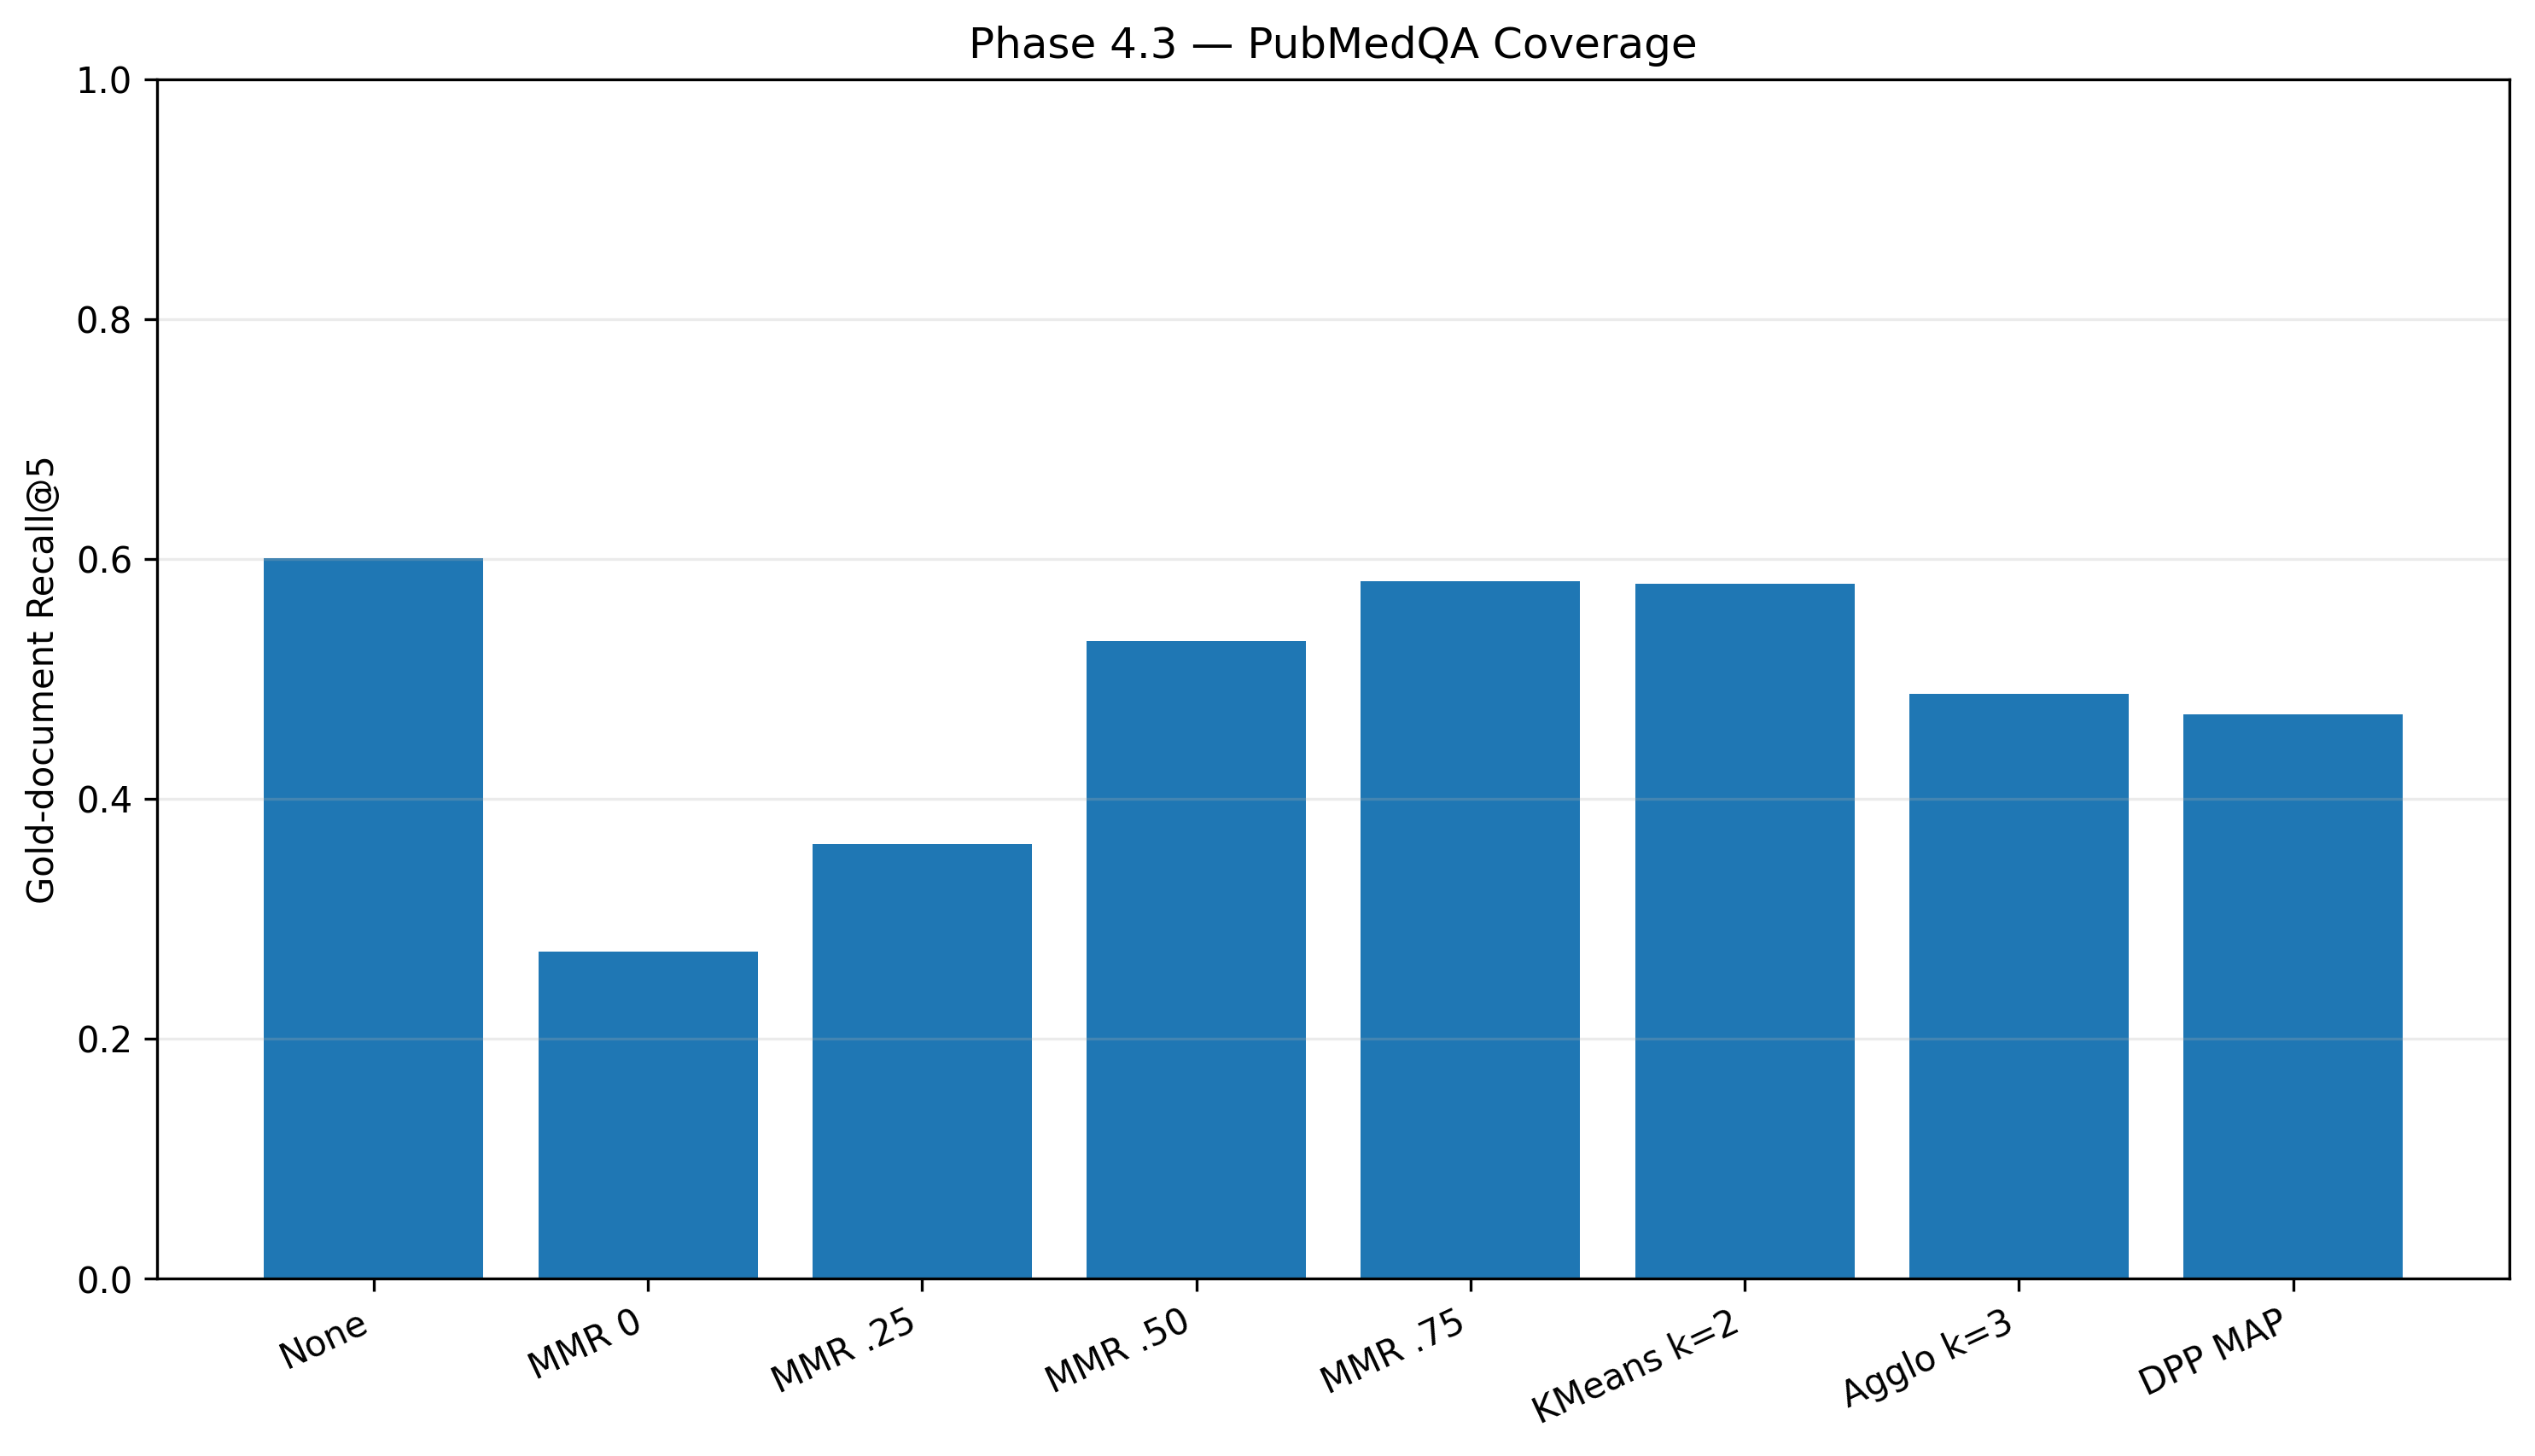

F12


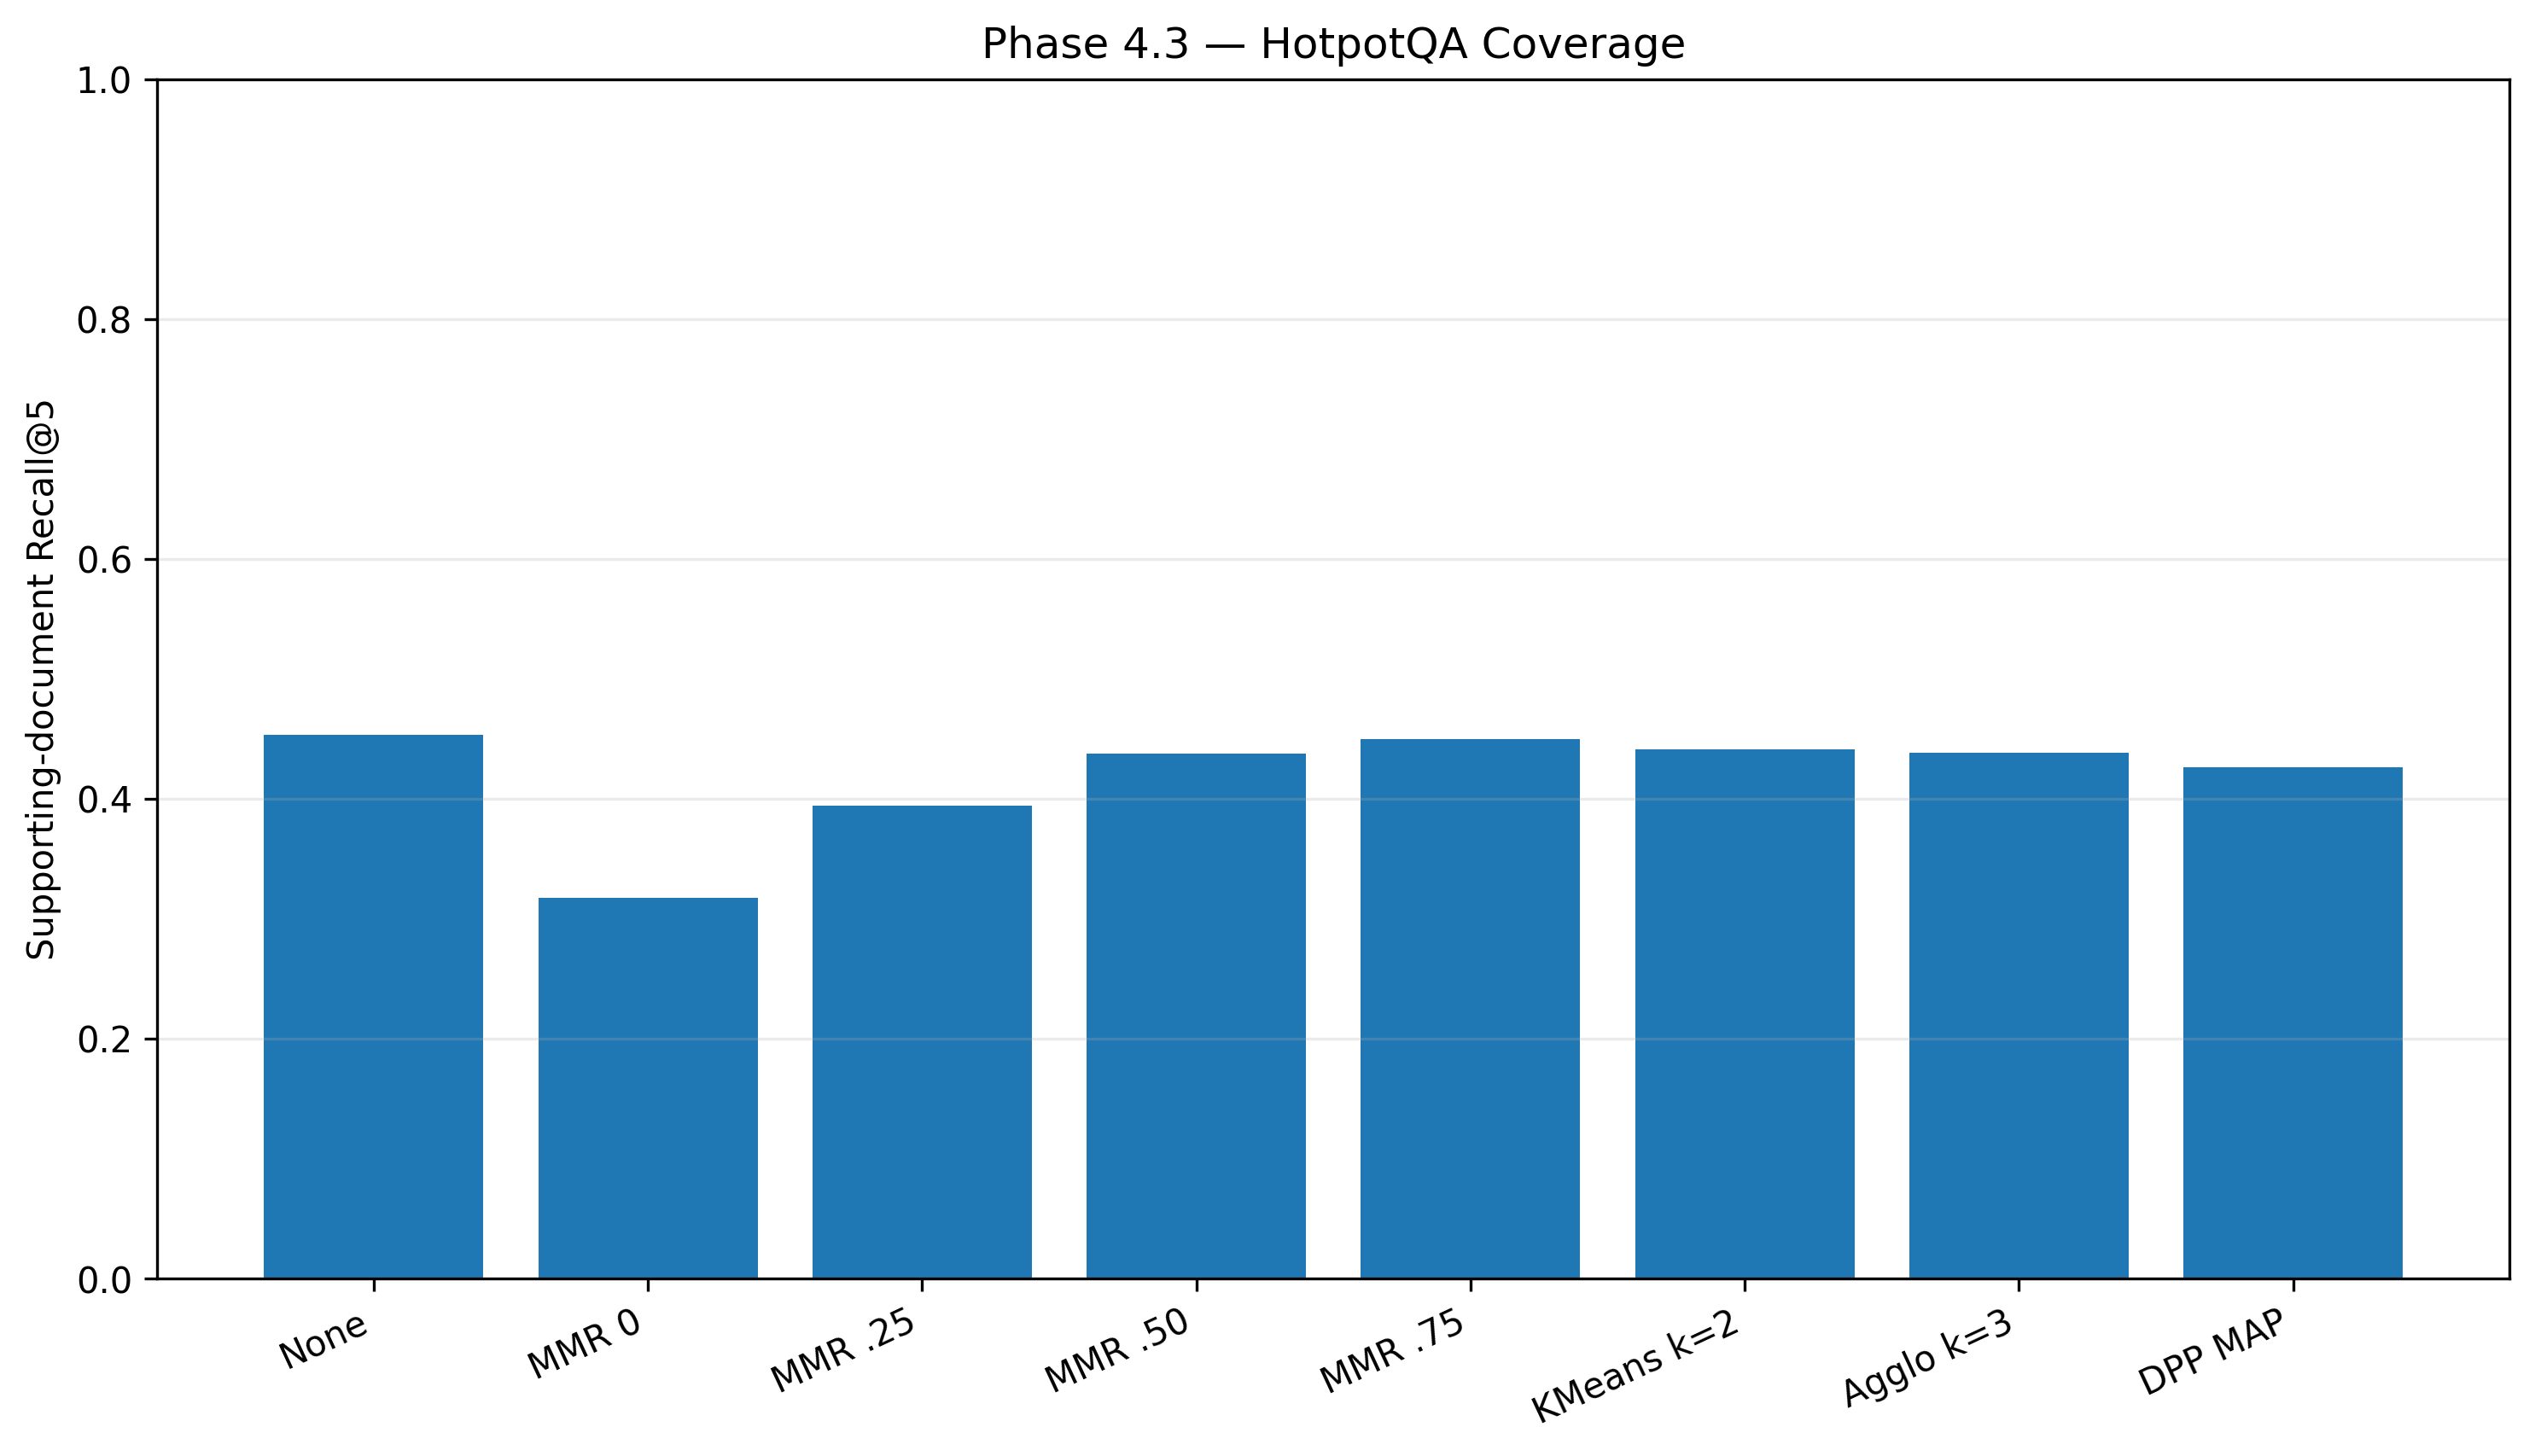

F13


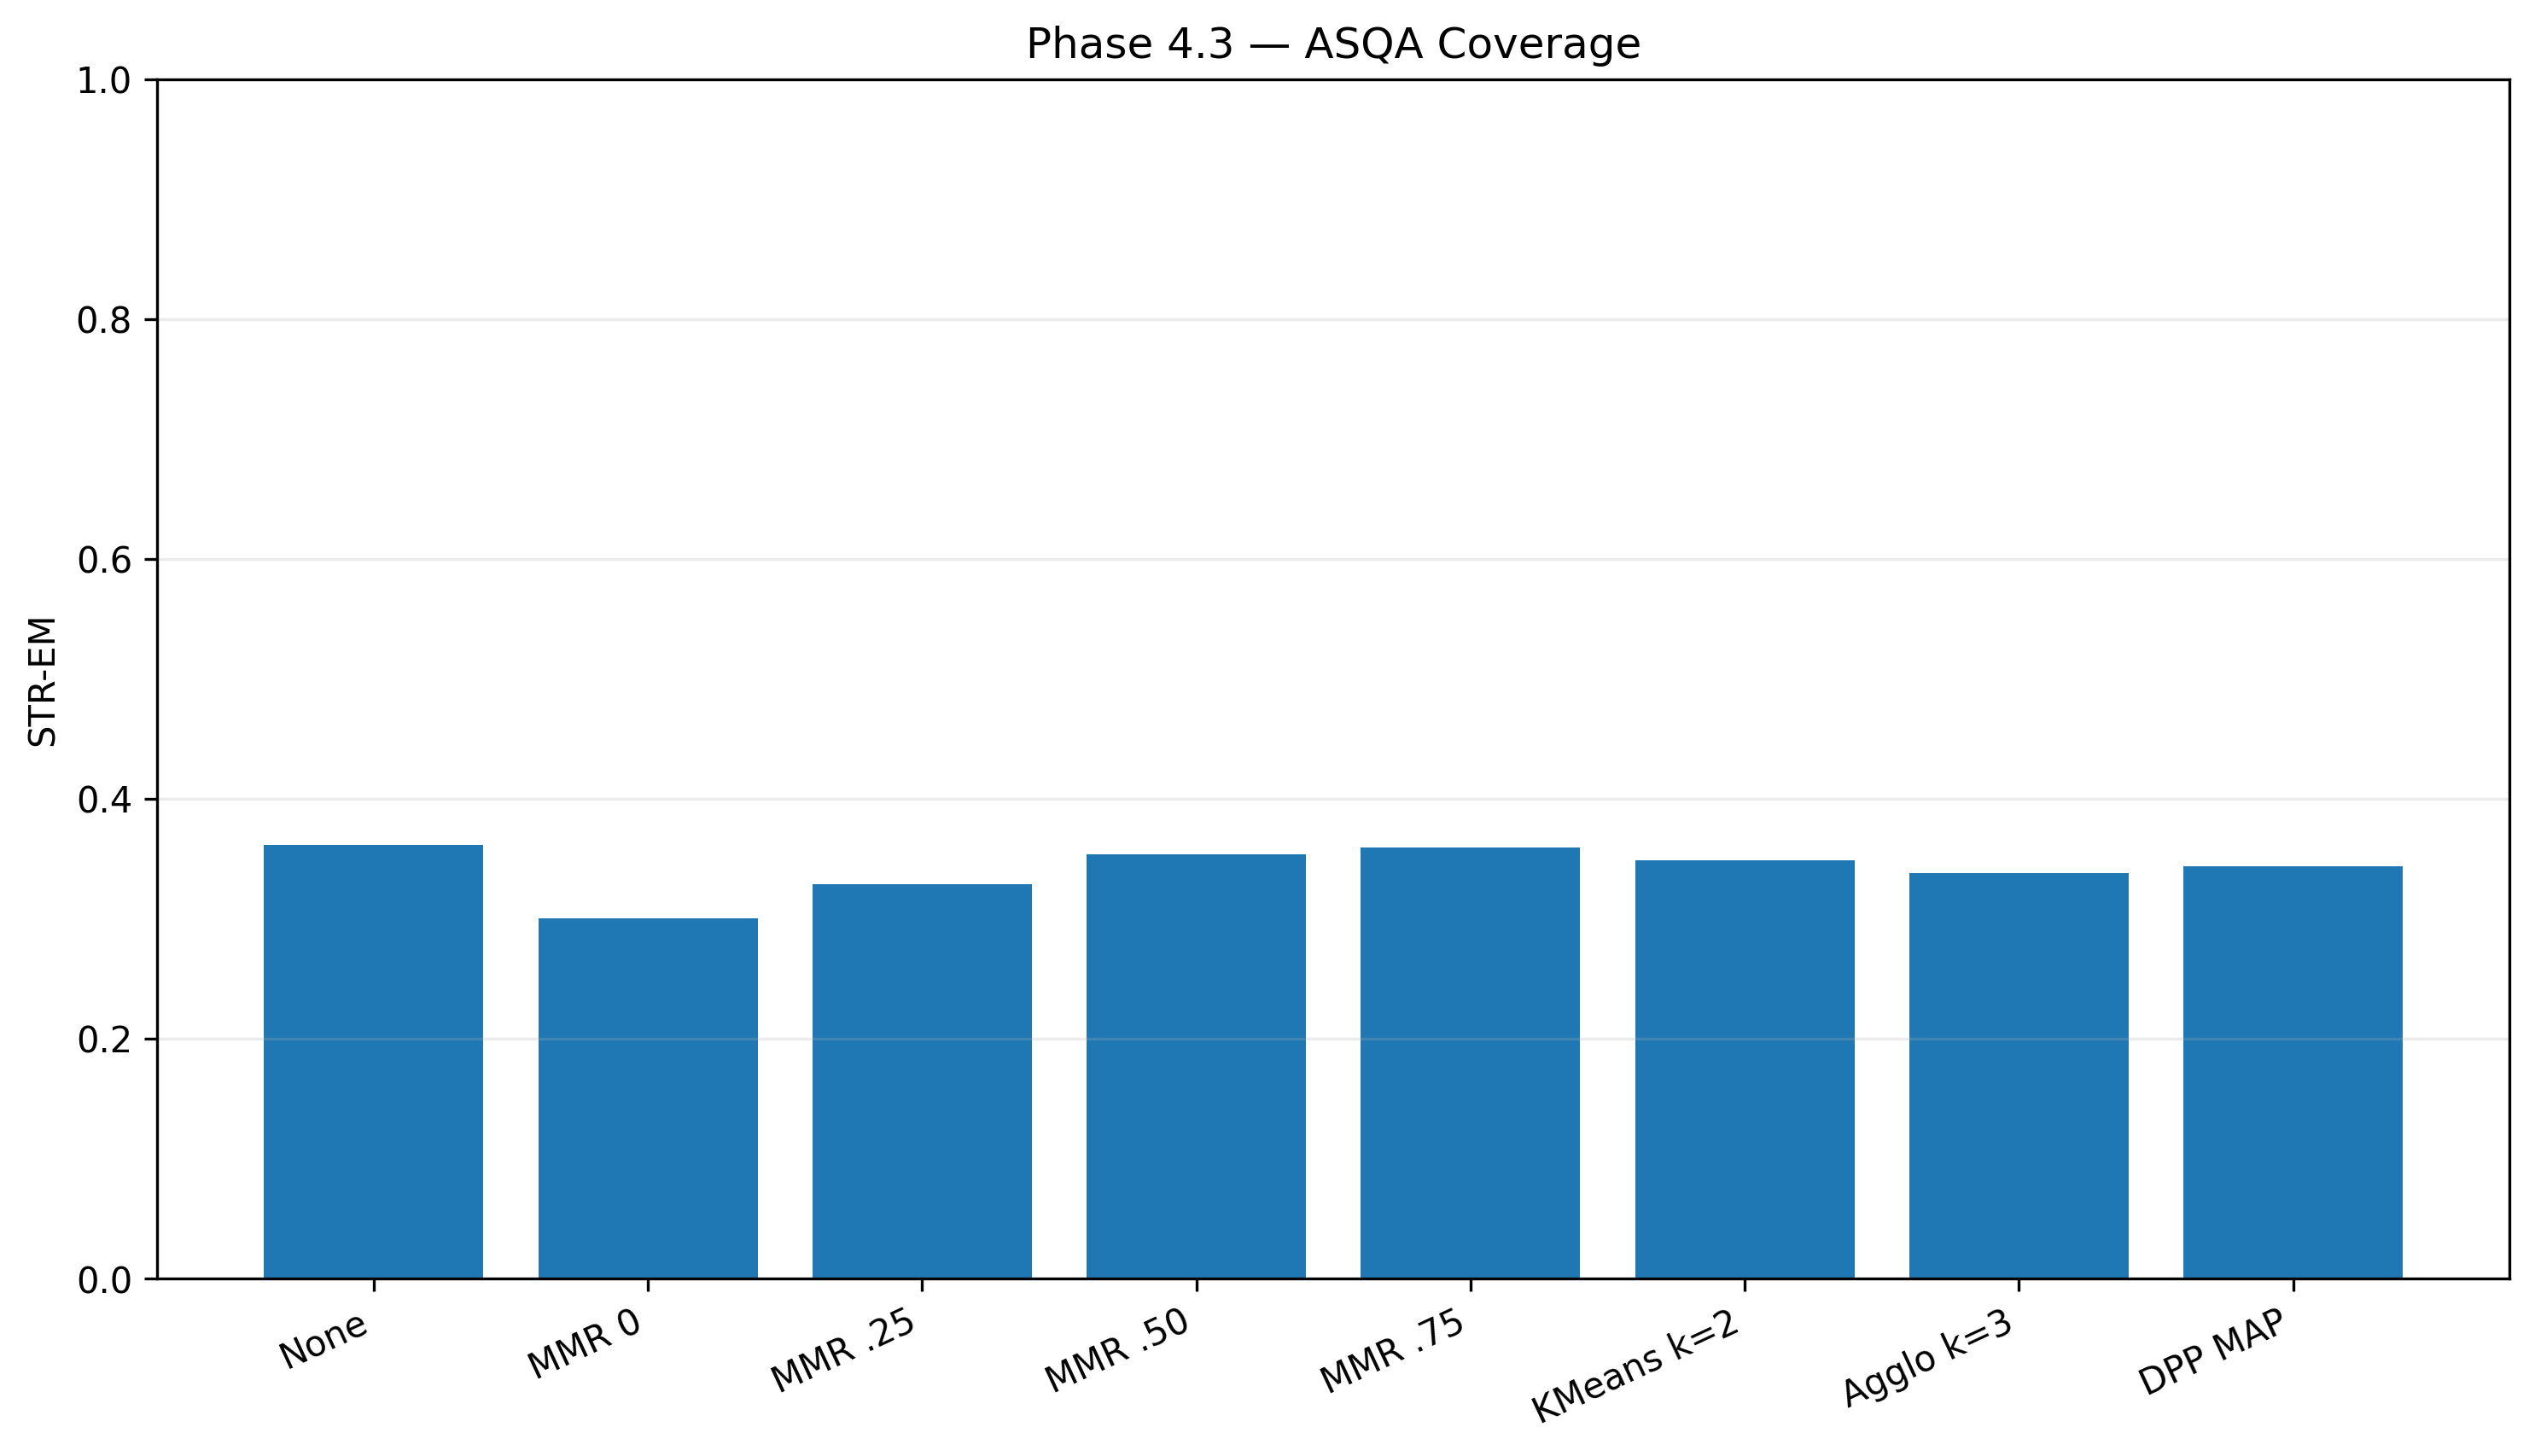

In [9]:
for fid in ["F11", "F12", "F13"]:
    print(fid)
    show_figure(fid)


Coverage remains dataset-specific and must not be interpreted as one common metric across all three datasets.

In particular, ASQA STR-EM / STR-Hit are answer-side metrics and are not substitutes for the unavailable protected-final retrieval aspect metrics.


## 6. Phase 4.4 — Retrieval diversity

Retrieval diversity is a manipulation check: it verifies whether the diversification methods actually changed the composition of the selected Top-5 evidence.


In [10]:
pqa_retrieval_div = load_csv("pubmedqa_retrieval_diversity_summary.csv")
hotpot_retrieval_div = load_csv("hotpotqa_retrieval_diversity_summary.csv")

asqa_bm25_div = load_json(
    "bm25_asqa_project_protected_final_final8_retrieval_diversity_summary_v1.json"
)
asqa_contriever_div = load_json(
    "contriever_asqa_project_protected_final_final8_retrieval_diversity_summary_v1.json"
)
asqa_dpr_div = load_json(
    "dpr_asqa_project_protected_final_final8_retrieval_diversity_summary_v1.json"
)

display(pqa_retrieval_div.head(12))
display(hotpot_retrieval_div.head(12))

print("ASQA BM25 conditions:")
display(pd.DataFrame(asqa_bm25_div["conditions"]).T)

print("ASQA Contriever conditions:")
display(pd.DataFrame(asqa_contriever_div["conditions"]).T)

print("ASQA DPR conditions:")
display(pd.DataFrame(asqa_dpr_div["conditions"]).T)


,dataset,retriever,condition,n,metric,mean_retrieval_diversity,std_retrieval_diversity,median_retrieval_diversity,min_retrieval_diversity,max_retrieval_diversity,embedding_model,embedding_model_revision,top_k
0,pubmedqa,bm25,none,1000,mean_pairwise_cosine_distance_top5,0.541484,0.070897,0.544621,0.327719,0.715482,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
1,pubmedqa,bm25,mmr_0,1000,mean_pairwise_cosine_distance_top5,0.684294,0.037892,0.686144,0.540061,0.797446,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
2,pubmedqa,bm25,mmr_0.25,1000,mean_pairwise_cosine_distance_top5,0.667325,0.045469,0.671840,0.432141,0.764757,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
3,pubmedqa,bm25,mmr_0.5,1000,mean_pairwise_cosine_distance_top5,0.612673,0.066503,0.618201,0.375565,0.773798,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
4,pubmedqa,bm25,mmr_0.75,1000,mean_pairwise_cosine_distance_top5,0.564666,0.071379,0.570377,0.327719,0.754951,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
5,pubmedqa,bm25,kmeans_k2,1000,mean_pairwise_cosine_distance_top5,0.566858,0.063573,0.570560,0.346250,0.735667,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
6,pubmedqa,bm25,agglo_k3,1000,mean_pairwise_cosine_distance_top5,0.586626,0.055100,0.588936,0.389789,0.741636,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
7,pubmedqa,bm25,dpp_map,1000,mean_pairwise_cosine_distance_top5,0.640434,0.052459,0.645512,0.432141,0.770932,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
8,pubmedqa,dpr,none,1000,mean_pairwise_cosine_distance_top5,0.578946,0.051722,0.583349,0.355364,0.719159,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
9,pubmedqa,dpr,mmr_0,1000,mean_pairwise_cosine_distance_top5,0.668177,0.030203,0.667096,0.558681,0.790682,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5


,dataset,retriever,condition,n,metric,mean_retrieval_diversity,std_retrieval_diversity,median_retrieval_diversity,min_retrieval_diversity,max_retrieval_diversity,embedding_model,embedding_model_revision,top_k
0,hotpotqa,bm25,none,7405,mean_pairwise_cosine_distance_top5,0.538038,0.100777,0.556765,0.078922,0.781515,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
1,hotpotqa,bm25,mmr_0,7405,mean_pairwise_cosine_distance_top5,0.650171,0.072129,0.663580,0.236239,0.837133,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
2,hotpotqa,bm25,mmr_0.25,7405,mean_pairwise_cosine_distance_top5,0.623455,0.077813,0.638297,0.185882,0.825383,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
3,hotpotqa,bm25,mmr_0.5,7405,mean_pairwise_cosine_distance_top5,0.580810,0.092084,0.598604,0.086226,0.805915,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
4,hotpotqa,bm25,mmr_0.75,7405,mean_pairwise_cosine_distance_top5,0.554167,0.097996,0.572738,0.078922,0.781515,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
5,hotpotqa,bm25,kmeans_k2,7405,mean_pairwise_cosine_distance_top5,0.563197,0.087107,0.577549,0.112706,0.768396,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
6,hotpotqa,bm25,agglo_k3,7405,mean_pairwise_cosine_distance_top5,0.574572,0.079983,0.588725,0.122262,0.767263,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
7,hotpotqa,bm25,dpp_map,7405,mean_pairwise_cosine_distance_top5,0.605225,0.074901,0.617467,0.228625,0.805915,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
8,hotpotqa,dpr,none,7405,mean_pairwise_cosine_distance_top5,0.577808,0.086299,0.592752,0.126164,0.782133,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5
9,hotpotqa,dpr,mmr_0,7405,mean_pairwise_cosine_distance_top5,0.677157,0.058372,0.686451,0.263776,0.823030,facebook/contriever,2bd46a25019aeea091fd42d1f0fd4801675cf699,5


ASQA BM25 conditions:


,max_retrieval_diversity,mean_retrieval_diversity,min_retrieval_diversity,questions,std_retrieval_diversity
agglo_k3,0.838685,0.614459,0.354166,948.0,0.093443
dpp_map,0.842632,0.645566,0.401500,948.0,0.087720
kmeans_k2,0.838681,0.603606,0.252645,948.0,0.105059
mmr_0,0.880542,0.716571,0.427881,948.0,0.077923
mmr_0.25,0.858152,0.676818,0.380175,948.0,0.087285
mmr_0.5,0.842632,0.620776,0.265713,948.0,0.105618
mmr_0.75,0.842632,0.589559,0.265713,948.0,0.111028
none,0.842632,0.574373,0.184799,948.0,0.113850


ASQA Contriever conditions:


,max_retrieval_diversity,mean_retrieval_diversity,min_retrieval_diversity,questions,std_retrieval_diversity
agglo_k3,0.791704,0.607933,0.327910,948.0,0.075404
dpp_map,0.807368,0.622299,0.370803,948.0,0.073840
kmeans_k2,0.807368,0.597864,0.327546,948.0,0.082346
mmr_0,0.834092,0.692151,0.481553,948.0,0.066120
mmr_0.25,0.820422,0.652128,0.370803,948.0,0.075698
mmr_0.5,0.807368,0.603133,0.327546,948.0,0.083657
mmr_0.75,0.807368,0.580500,0.293618,948.0,0.088551
none,0.807368,0.569581,0.293618,948.0,0.088723


ASQA DPR conditions:


,max_retrieval_diversity,mean_retrieval_diversity,min_retrieval_diversity,questions,std_retrieval_diversity
agglo_k3,0.792046,0.582222,0.353868,948.0,0.080510
dpp_map,0.815841,0.606138,0.370864,948.0,0.081300
kmeans_k2,0.778224,0.563651,0.281323,948.0,0.087705
mmr_0,0.845628,0.679629,0.458586,948.0,0.074358
mmr_0.25,0.817201,0.640158,0.370864,948.0,0.085469
mmr_0.5,0.815841,0.572010,0.309187,948.0,0.096922
mmr_0.75,0.815841,0.539632,0.243850,948.0,0.096866
none,0.792853,0.524387,0.243850,948.0,0.094170


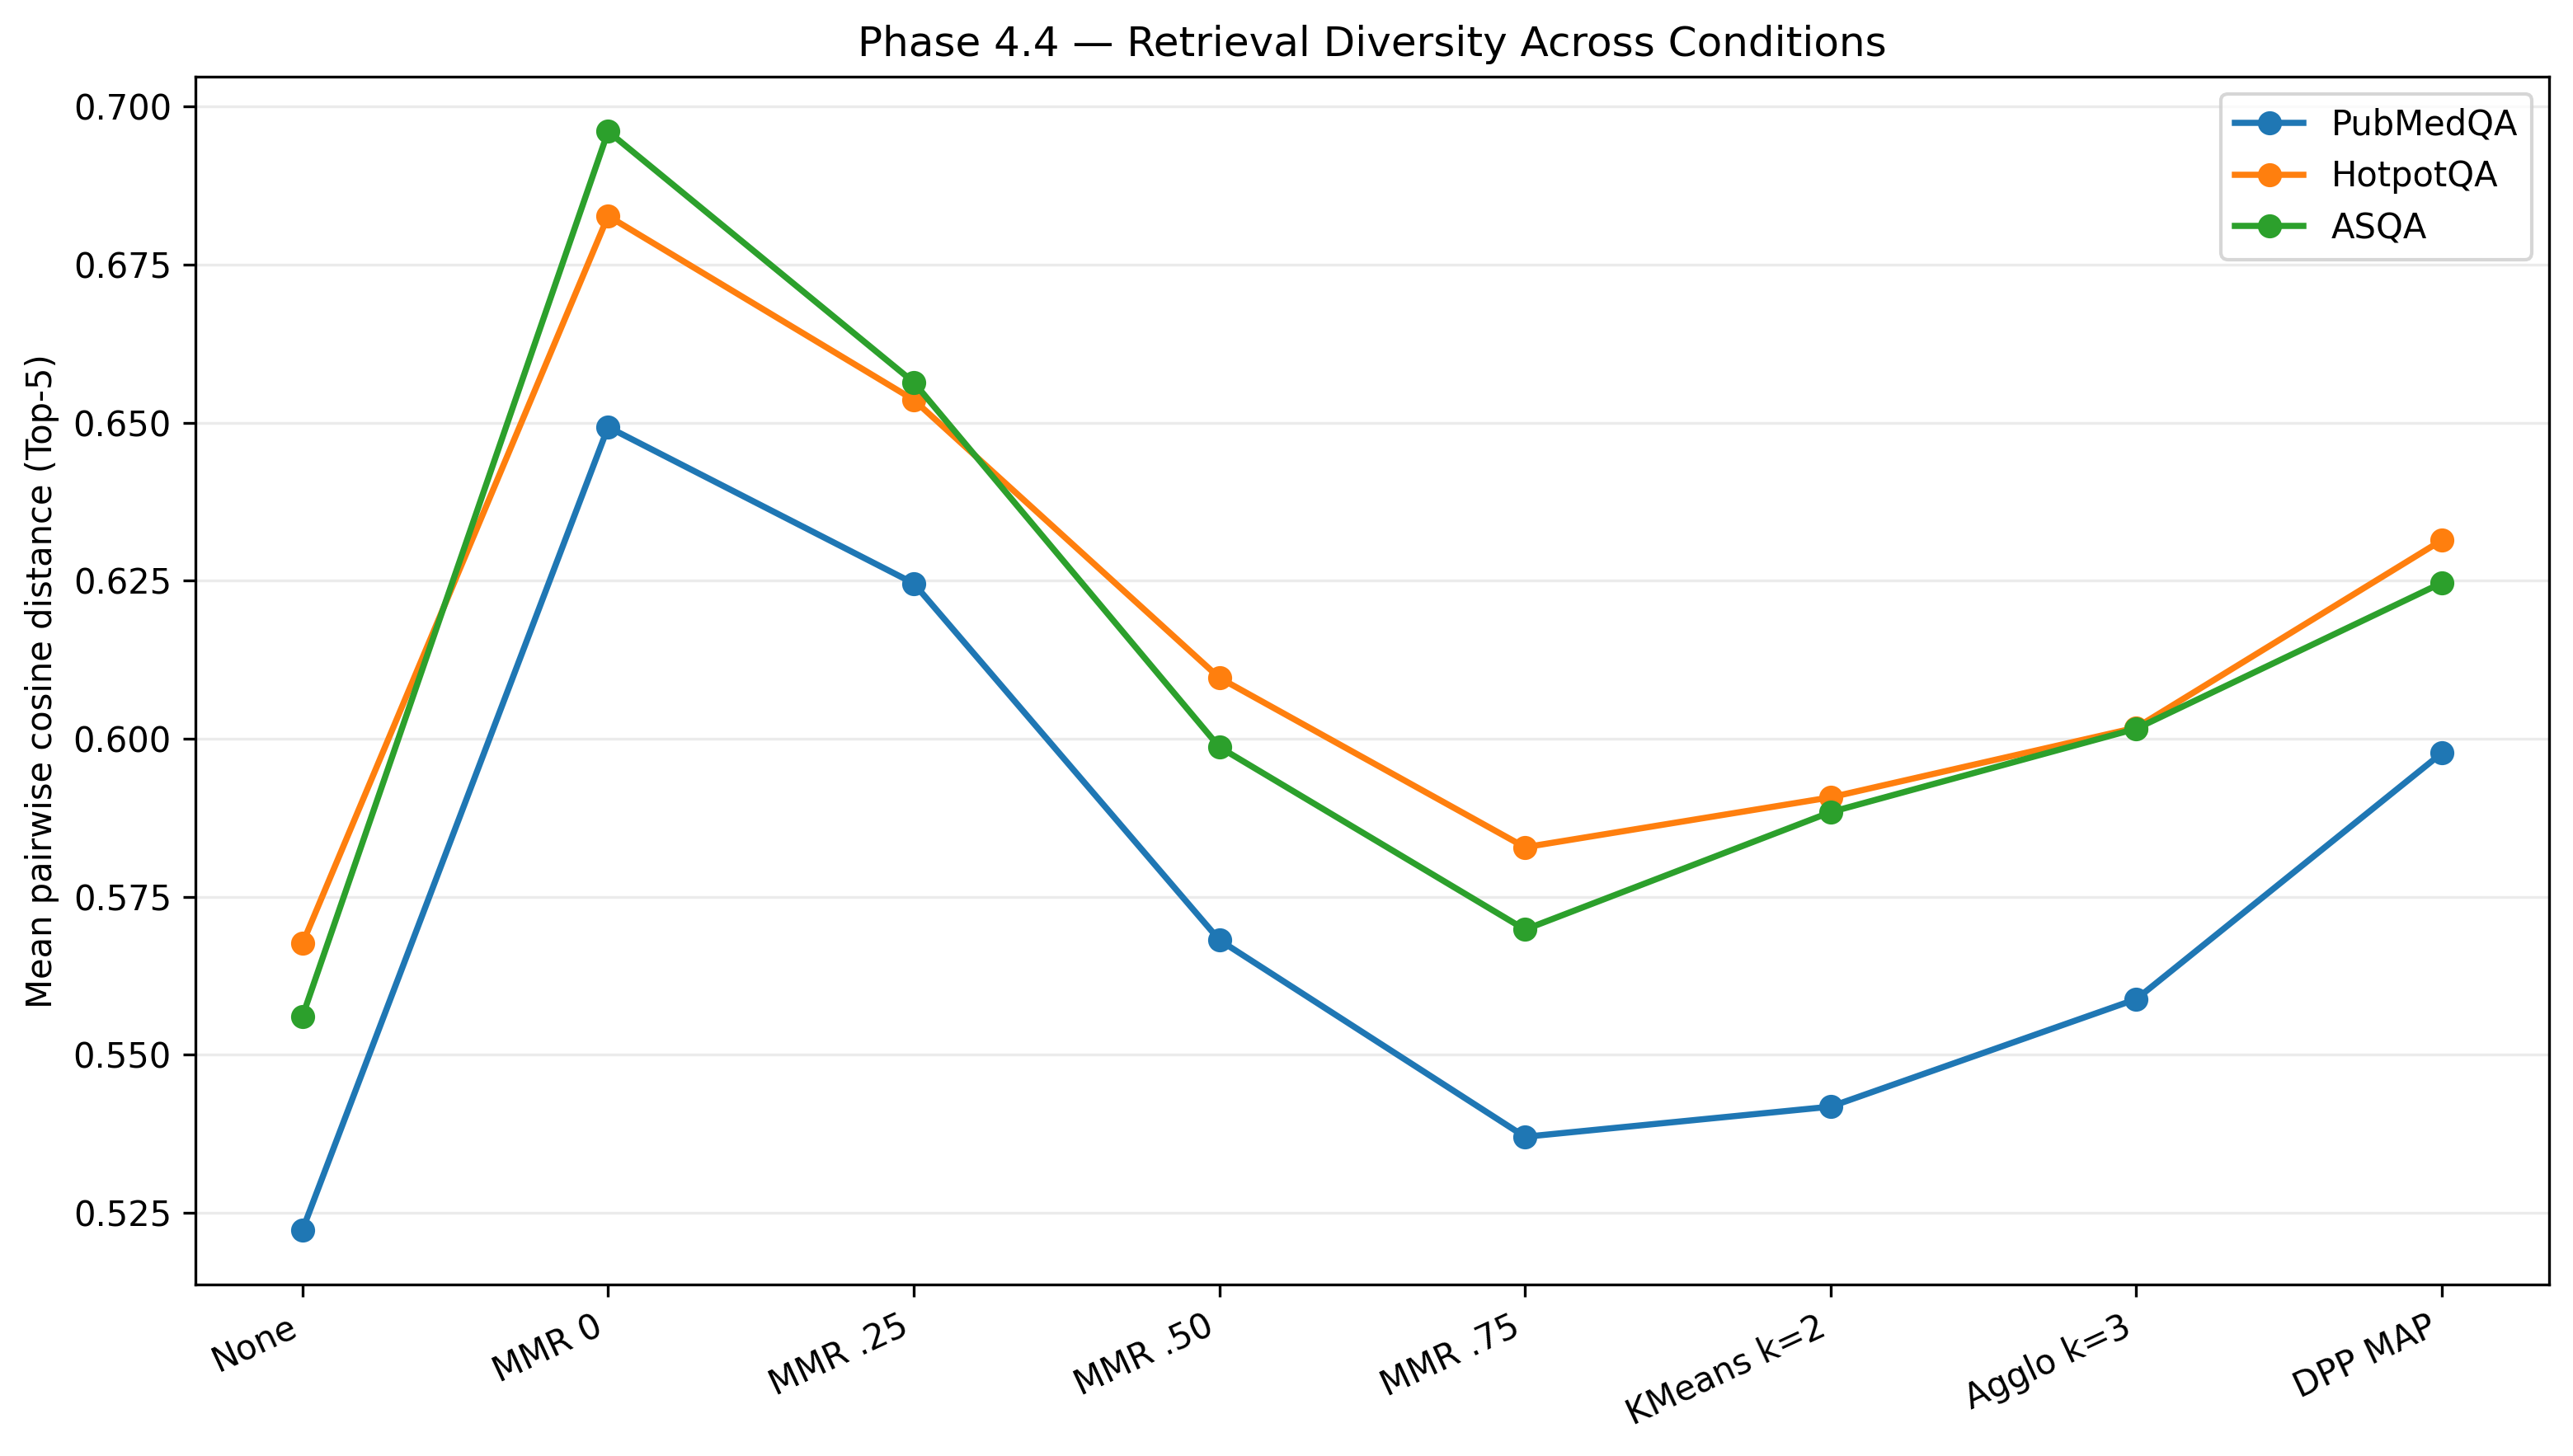

In [11]:
show_figure("F14")


The manipulation succeeded: diversification changes the embedding-space composition of retrieved evidence.

However, because the diagnostic uses passage embeddings related to the diversification machinery, it is not treated as independent evidence that retrieval quality improved.


## 7. Phase 4.5 — ASQA output diversity


In [12]:
asqa_output_div = load_csv("asqa_output_diversity_summary.csv")

print("ASQA output-diversity rows:", len(asqa_output_div))
display(asqa_output_div.head(15))


ASQA output-diversity rows: 72


,retriever,condition,logical_model_id,answers,eligible_answers,ineligible_answers,eligibility_fraction,mean_output_diversity
0,bm25,agglo_k3,gemma4-26b,948,350,598,0.369198,0.383597
1,bm25,agglo_k3,llama-3.3-70b,947,769,178,0.812038,0.377477
2,bm25,agglo_k3,ministral-3-14b,946,760,186,0.803383,0.402341
3,bm25,dpp_map,gemma4-26b,948,369,579,0.389241,0.380437
4,bm25,dpp_map,llama-3.3-70b,946,748,198,0.790698,0.379806
5,bm25,dpp_map,ministral-3-14b,943,758,185,0.803818,0.401041
6,bm25,kmeans_k2,gemma4-26b,948,347,601,0.366034,0.384254
7,bm25,kmeans_k2,llama-3.3-70b,947,752,195,0.794087,0.376193
8,bm25,kmeans_k2,ministral-3-14b,944,755,189,0.799788,0.407781
9,bm25,mmr_0,gemma4-26b,948,353,595,0.372363,0.377510


F15


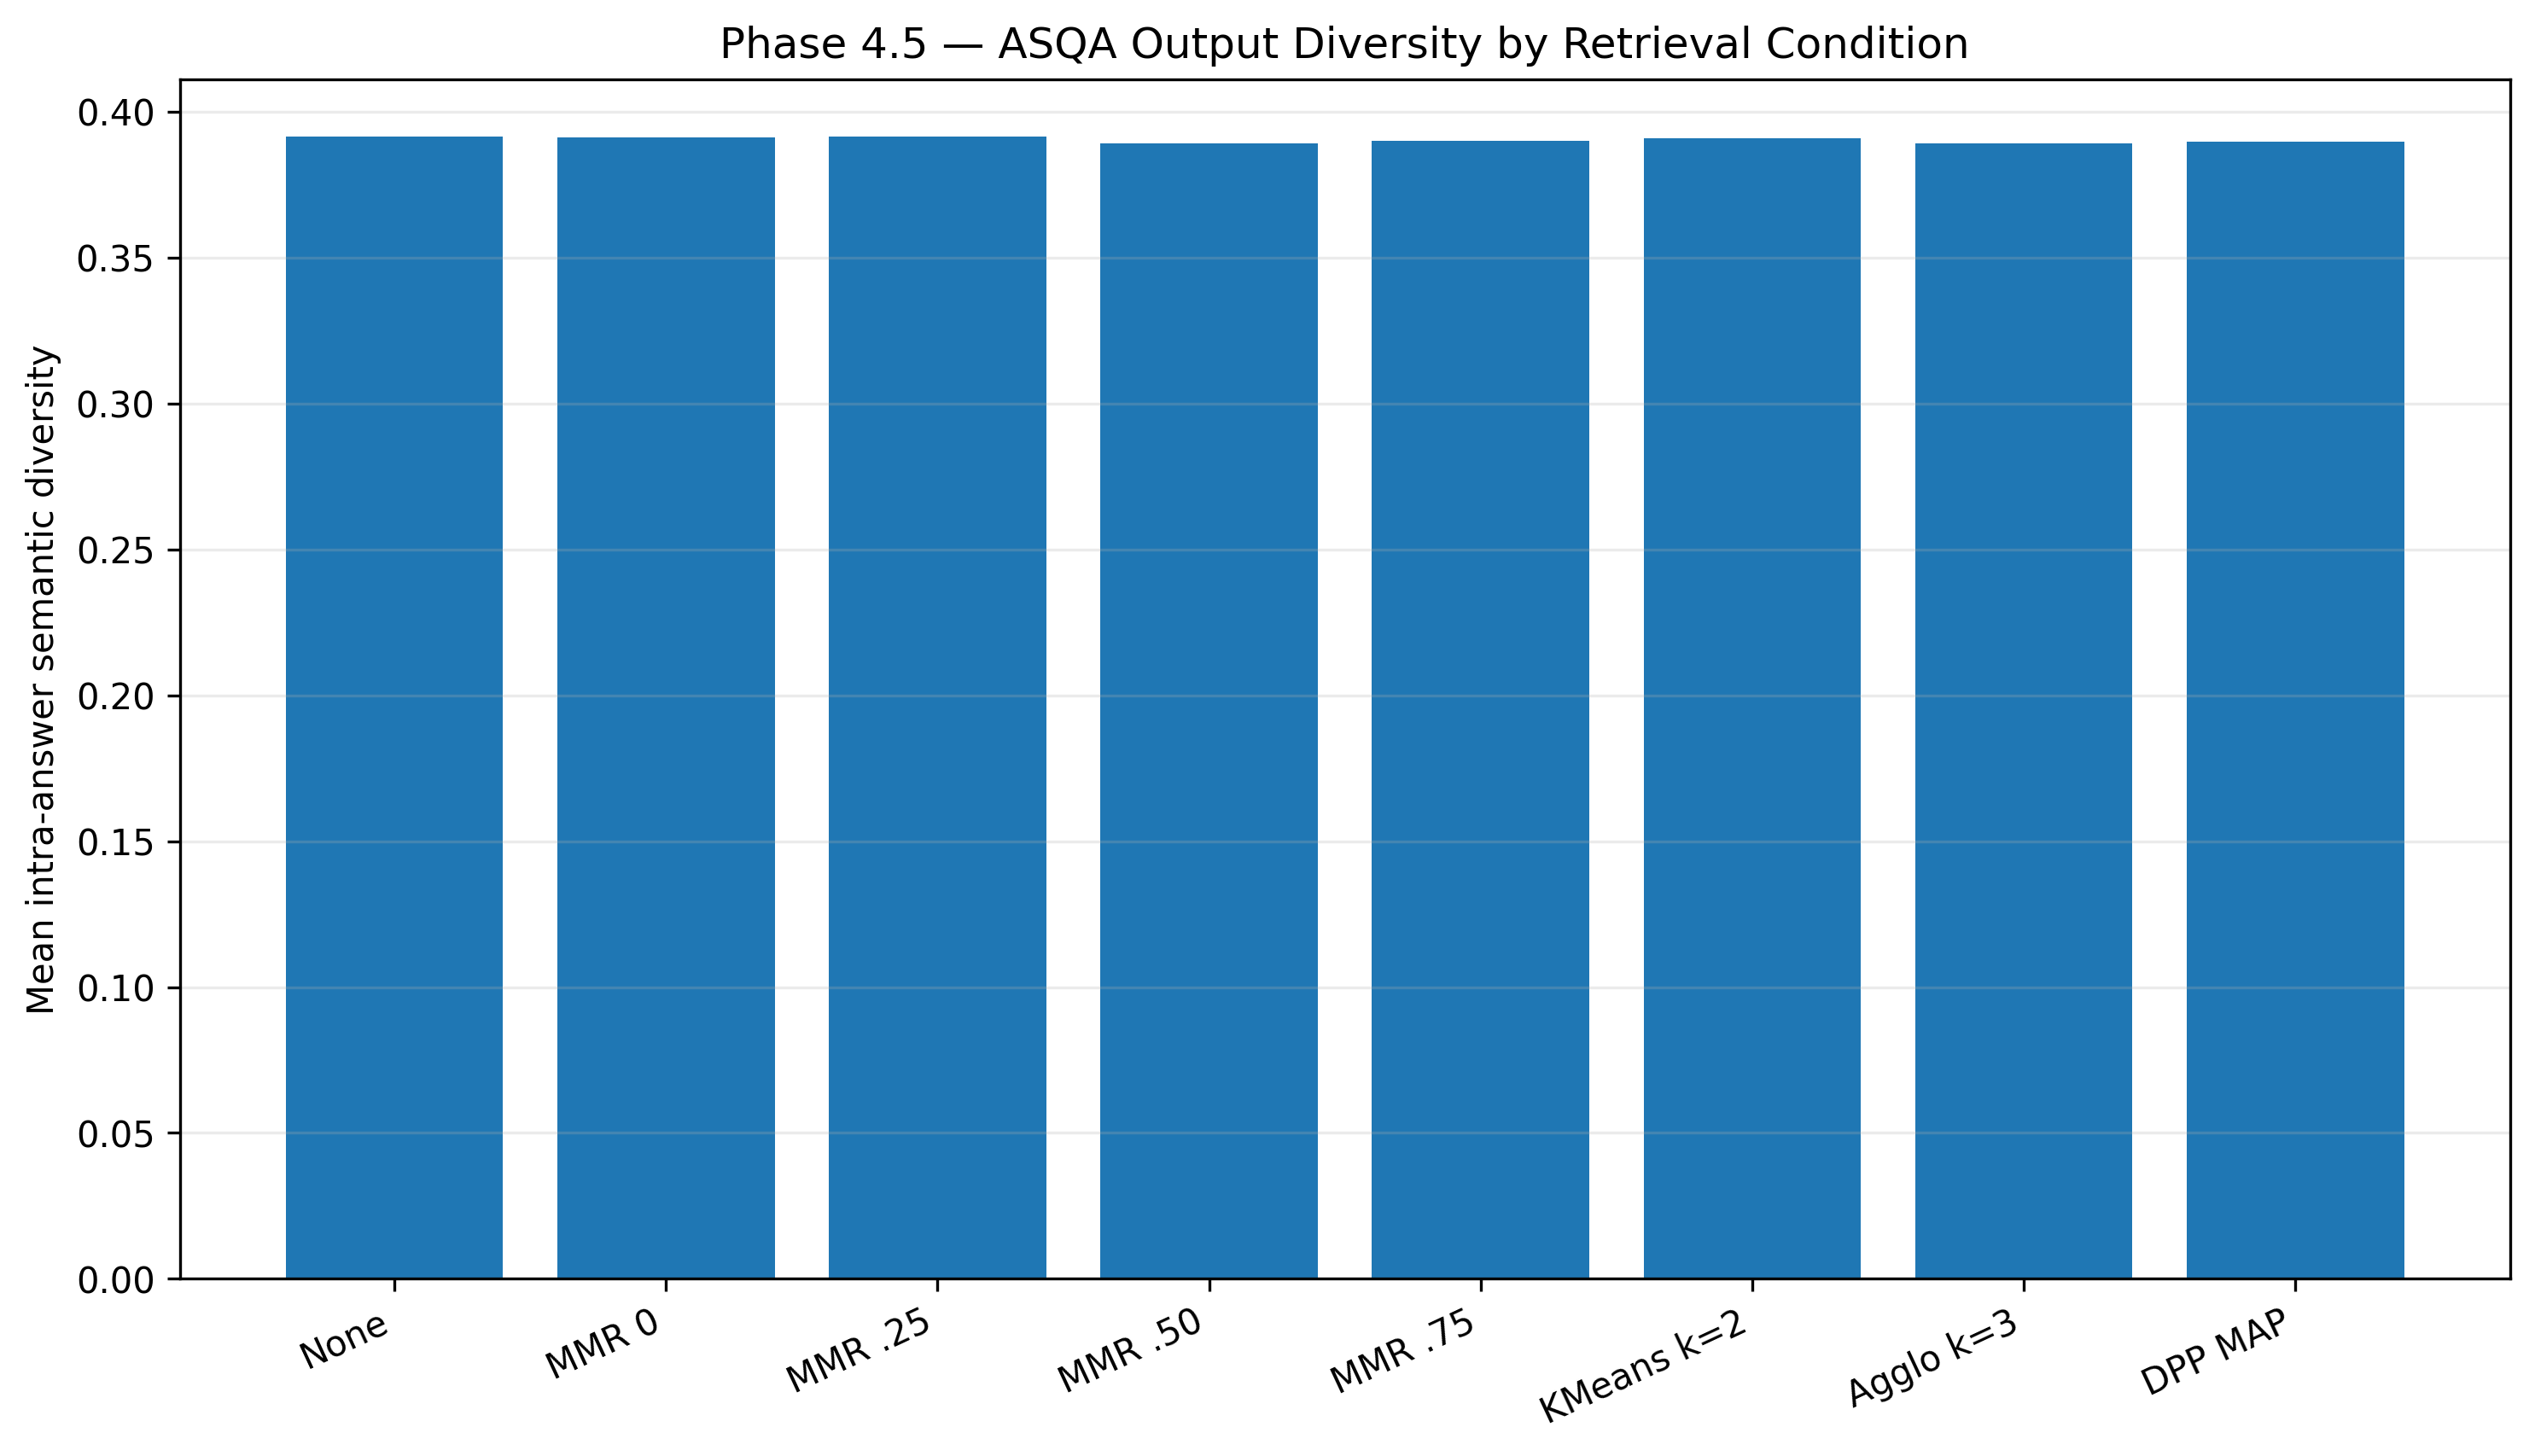

F16


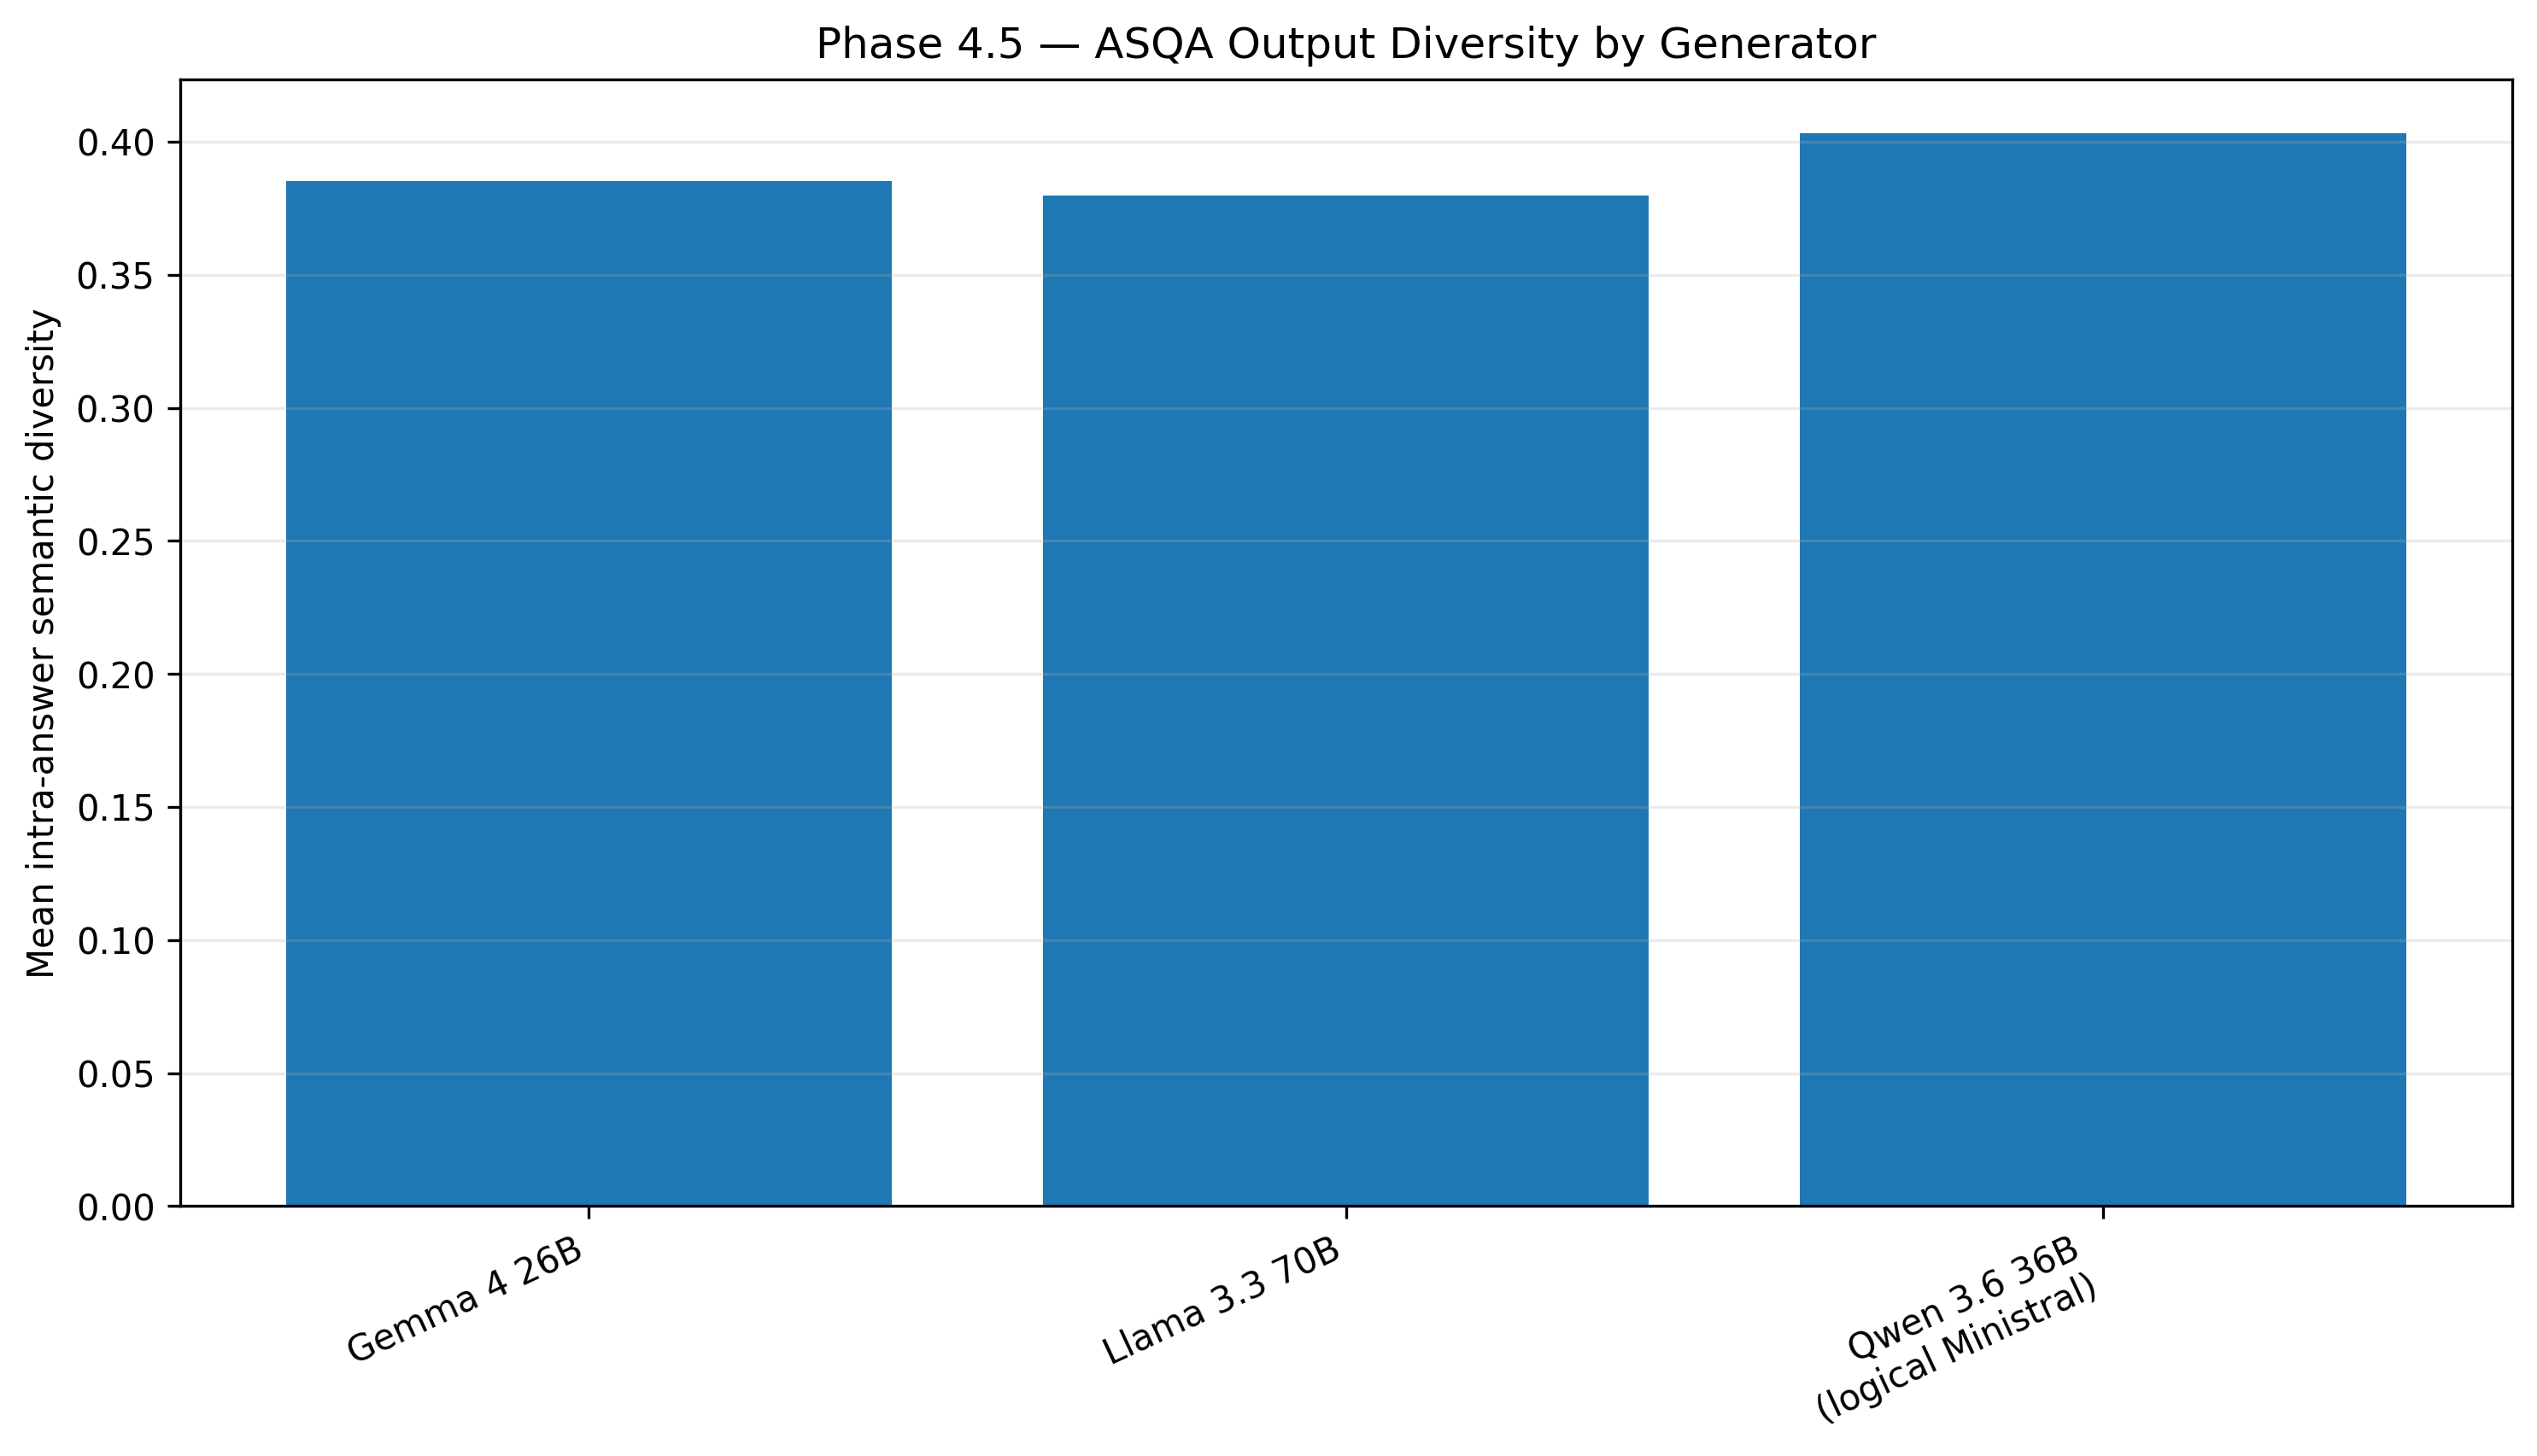

In [13]:
for fid in ["F15", "F16"]:
    print(fid)
    show_figure(fid)


Only answers with at least two sentences are eligible for the output-diversity metric.

Ineligible answers are excluded; they are not assigned zero diversity.


# Phase 5 — Diversity Effects and Robustness


## 8. Phase 5.1 — Diversity versus correctness

The operating-point table describes the cross-sectional relationship among configurations.

The paired table compares each diversification condition with the corresponding `none` baseline for the same query/configuration and is therefore the stronger intervention analysis.


In [14]:
phase51_ops = load_csv("phase51_operating_point_summary.csv")
phase51_paired = load_csv("phase51_paired_summary_vs_none.csv")
hotpot_em_secondary = load_csv("hotpotqa_phase51_em_secondary_summary.csv")

print("Operating points:", len(phase51_ops))
display(phase51_ops.head(15))

print("Paired comparisons versus none:", len(phase51_paired))
display(phase51_paired.head(15))

print("HotpotQA secondary EM rows:", len(hotpot_em_secondary))
display(hotpot_em_secondary.head(12))


Operating points: 264


,dataset,retriever,condition,logical_model_id,physical_model_id,primary_metric,n,mean_retrieval_diversity,std_retrieval_diversity,mean_primary_score,std_primary_score
0,asqa,bm25,none,gemma4-26b,gemma4-26b,qa_f1,948,0.574373,0.113910,0.206041,0.284211
1,asqa,bm25,mmr_0,gemma4-26b,gemma4-26b,qa_f1,948,0.716571,0.077964,0.164400,0.251443
2,asqa,bm25,mmr_0.25,gemma4-26b,gemma4-26b,qa_f1,948,0.676818,0.087331,0.182421,0.266539
3,asqa,bm25,mmr_0.5,gemma4-26b,gemma4-26b,qa_f1,948,0.620776,0.105674,0.199001,0.278474
4,asqa,bm25,mmr_0.75,gemma4-26b,gemma4-26b,qa_f1,948,0.589559,0.111087,0.206542,0.282744
5,asqa,bm25,kmeans_k2,gemma4-26b,gemma4-26b,qa_f1,948,0.603606,0.105114,0.199883,0.279731
6,asqa,bm25,agglo_k3,gemma4-26b,gemma4-26b,qa_f1,948,0.614459,0.093493,0.197757,0.271289
7,asqa,bm25,dpp_map,gemma4-26b,gemma4-26b,qa_f1,948,0.645566,0.087766,0.195833,0.278979
8,asqa,bm25,none,llama-3.3-70b,llama-3.3-70b,qa_f1,944,0.574395,0.113751,0.327957,0.299461
9,asqa,bm25,mmr_0,llama-3.3-70b,llama-3.3-70b,qa_f1,947,0.716494,0.077969,0.297017,0.281430


Paired comparisons versus none: 231


,dataset,retriever,condition,logical_model_id,physical_model_id,primary_metric,n_pairs,mean_delta_retrieval_diversity,median_delta_retrieval_diversity,mean_delta_primary_score,median_delta_primary_score,fraction_score_improved,fraction_score_worsened,fraction_score_unchanged
0,asqa,bm25,mmr_0,gemma4-26b,gemma4-26b,qa_f1,948,0.142198,0.130106,-0.041641,0.0,0.113924,0.201477,0.684599
1,asqa,bm25,mmr_0.25,gemma4-26b,gemma4-26b,qa_f1,948,0.102444,0.086499,-0.023620,0.0,0.089662,0.138186,0.772152
2,asqa,bm25,mmr_0.5,gemma4-26b,gemma4-26b,qa_f1,948,0.046403,0.032387,-0.007041,0.0,0.071730,0.081224,0.847046
3,asqa,bm25,mmr_0.75,gemma4-26b,gemma4-26b,qa_f1,948,0.015186,0.000000,0.000500,0.0,0.065401,0.051688,0.882911
4,asqa,bm25,kmeans_k2,gemma4-26b,gemma4-26b,qa_f1,948,0.029233,0.012474,-0.006158,0.0,0.100211,0.101266,0.798523
5,asqa,bm25,agglo_k3,gemma4-26b,gemma4-26b,qa_f1,948,0.040085,0.027588,-0.008284,0.0,0.101266,0.117089,0.781646
6,asqa,bm25,dpp_map,gemma4-26b,gemma4-26b,qa_f1,948,0.071193,0.057455,-0.010209,0.0,0.081224,0.098101,0.820675
7,asqa,bm25,mmr_0,llama-3.3-70b,llama-3.3-70b,qa_f1,944,0.142176,0.130177,-0.030261,0.0,0.168432,0.245763,0.585805
8,asqa,bm25,mmr_0.25,llama-3.3-70b,llama-3.3-70b,qa_f1,943,0.102430,0.086599,-0.014654,0.0,0.143160,0.190880,0.665960
9,asqa,bm25,mmr_0.5,llama-3.3-70b,llama-3.3-70b,qa_f1,942,0.046344,0.032387,-0.001710,0.0,0.118896,0.129512,0.751592


HotpotQA secondary EM rows: 96


,dataset,retriever,condition,logical_model_id,physical_model_id,secondary_metric,n,mean_secondary_score,std_secondary_score
0,hotpotqa,bm25,agglo_k3,gemma4-26b,gemma4-26b,em,7391,0.272223,0.445134
1,hotpotqa,bm25,agglo_k3,llama-3.3-70b,llama-3.3-70b,em,7354,0.396791,0.489265
2,hotpotqa,bm25,agglo_k3,ministral-3-14b,qwen3.6-36b,em,7249,0.390537,0.487904
3,hotpotqa,bm25,dpp_map,gemma4-26b,gemma4-26b,em,7386,0.265502,0.441630
4,hotpotqa,bm25,dpp_map,llama-3.3-70b,llama-3.3-70b,em,7355,0.392658,0.488375
5,hotpotqa,bm25,dpp_map,ministral-3-14b,qwen3.6-36b,em,7264,0.385876,0.486835
6,hotpotqa,bm25,kmeans_k2,gemma4-26b,gemma4-26b,em,7386,0.268481,0.443199
7,hotpotqa,bm25,kmeans_k2,llama-3.3-70b,llama-3.3-70b,em,7357,0.398532,0.489629
8,hotpotqa,bm25,kmeans_k2,ministral-3-14b,qwen3.6-36b,em,7243,0.390446,0.487884
9,hotpotqa,bm25,mmr_0,gemma4-26b,gemma4-26b,em,7387,0.214702,0.410643


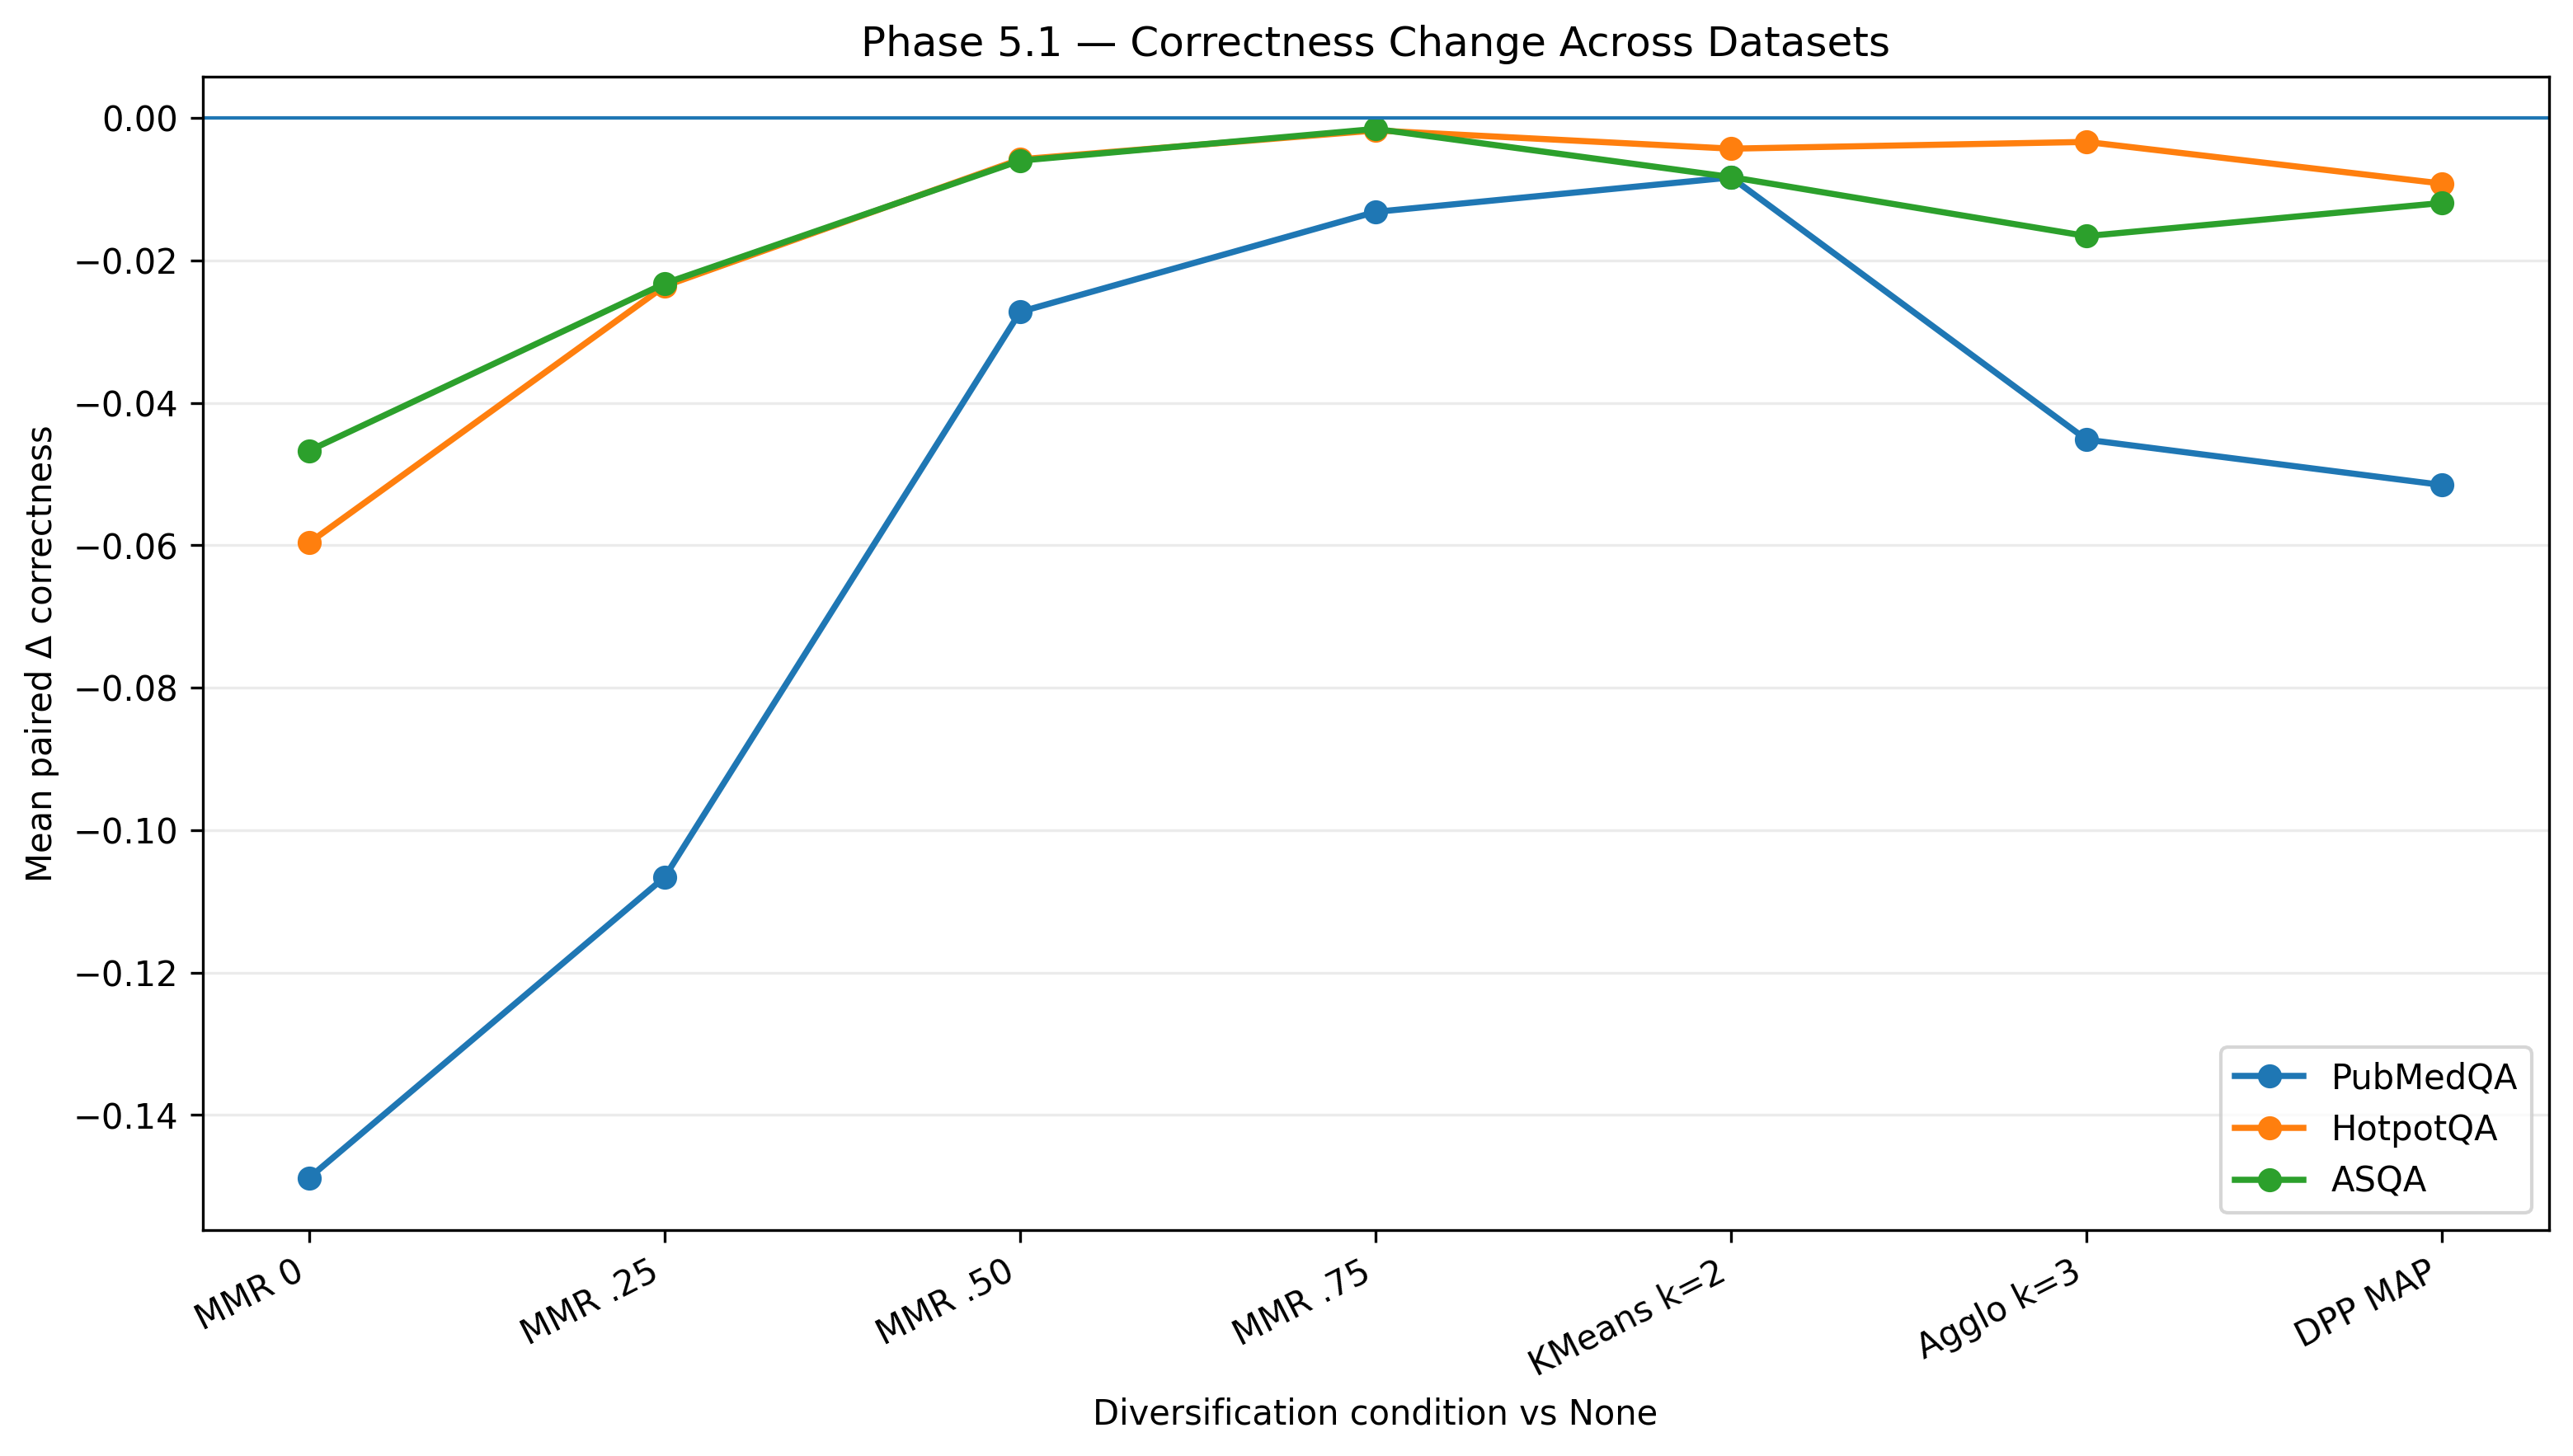

In [15]:
show_figure("F17")


Across the frozen paired comparisons, increasing retrieval diversity does not produce a consistent correctness gain.

The project therefore reports a trade-off rather than a universal benefit or universal harm.


## 9. Phase 5.2 — Diversity versus faithfulness and hallucination


In [16]:
phase52_paired = load_csv("phase52_paired_summary_vs_none.csv")

print("Operating points:", len(phase52))
display(phase52.head(15))

print("Paired comparisons versus none:", len(phase52_paired))
display(phase52_paired.head(15))


Operating points: 264


,dataset,retriever,condition,logical_model_id,physical_model_id,n,mean_retrieval_diversity,std_retrieval_diversity,mean_faithfulness,std_faithfulness,hallucination_rate,mean_supporting_source_count,mean_claim_count,mean_supported_claim_count
0,asqa,bm25,none,gemma4-26b,gemma4-26b,948,0.574373,0.113910,0.916235,0.242690,0.125527,2.600211,1.548523,1.396624
1,asqa,bm25,mmr_0,gemma4-26b,gemma4-26b,948,0.716571,0.077964,0.907050,0.253471,0.138186,2.454641,1.474684,1.310127
2,asqa,bm25,mmr_0.25,gemma4-26b,gemma4-26b,948,0.676818,0.087331,0.919989,0.242811,0.113924,2.486287,1.505274,1.374473
3,asqa,bm25,mmr_0.5,gemma4-26b,gemma4-26b,948,0.620776,0.105674,0.912060,0.251418,0.126582,2.549578,1.530591,1.373418
4,asqa,bm25,mmr_0.75,gemma4-26b,gemma4-26b,948,0.589559,0.111087,0.918548,0.239558,0.121308,2.597046,1.521097,1.374473
5,asqa,bm25,kmeans_k2,gemma4-26b,gemma4-26b,948,0.603606,0.105114,0.904688,0.268719,0.126582,2.520042,1.492616,1.337553
6,asqa,bm25,agglo_k3,gemma4-26b,gemma4-26b,948,0.614459,0.093493,0.902866,0.263973,0.136076,2.456751,1.506329,1.330169
7,asqa,bm25,dpp_map,gemma4-26b,gemma4-26b,948,0.645566,0.087766,0.918714,0.240535,0.119198,2.503165,1.544304,1.401899
8,asqa,bm25,none,llama-3.3-70b,llama-3.3-70b,944,0.574395,0.113751,0.869048,0.259917,0.263771,2.972458,3.106992,2.670551
9,asqa,bm25,mmr_0,llama-3.3-70b,llama-3.3-70b,947,0.716494,0.077969,0.870204,0.260654,0.258712,2.855333,3.025343,2.613516


Paired comparisons versus none: 231


,dataset,retriever,condition,logical_model_id,physical_model_id,n_pairs,mean_delta_retrieval_diversity,median_delta_retrieval_diversity,mean_delta_faithfulness,median_delta_faithfulness,mean_delta_hallucination,mean_delta_supporting_source_count,fraction_faithfulness_improved,fraction_faithfulness_worsened,fraction_faithfulness_unchanged,fraction_hallucination_improved,fraction_hallucination_worsened,fraction_hallucination_unchanged
0,asqa,bm25,mmr_0,gemma4-26b,gemma4-26b,948,0.142198,0.130106,-0.009185,0.0,0.012658,-0.145570,0.093882,0.111814,0.794304,0.087553,0.100211,0.812236
1,asqa,bm25,mmr_0.25,gemma4-26b,gemma4-26b,948,0.102444,0.086499,0.003755,0.0,-0.011603,-0.113924,0.092827,0.080169,0.827004,0.082278,0.070675,0.847046
2,asqa,bm25,mmr_0.5,gemma4-26b,gemma4-26b,948,0.046403,0.032387,-0.004174,0.0,0.001055,-0.050633,0.068565,0.079114,0.852321,0.063291,0.064346,0.872363
3,asqa,bm25,mmr_0.75,gemma4-26b,gemma4-26b,948,0.015186,0.000000,0.002313,0.0,-0.004219,-0.003165,0.053797,0.056962,0.889241,0.046414,0.042194,0.911392
4,asqa,bm25,kmeans_k2,gemma4-26b,gemma4-26b,948,0.029233,0.012474,-0.011546,0.0,0.001055,-0.080169,0.073840,0.082278,0.843882,0.067511,0.068565,0.863924
5,asqa,bm25,agglo_k3,gemma4-26b,gemma4-26b,948,0.040085,0.027588,-0.013369,0.0,0.010549,-0.143460,0.071730,0.086498,0.841772,0.062236,0.072785,0.864979
6,asqa,bm25,dpp_map,gemma4-26b,gemma4-26b,948,0.071193,0.057455,0.002479,0.0,-0.006329,-0.097046,0.081224,0.075949,0.842827,0.070675,0.064346,0.864979
7,asqa,bm25,mmr_0,llama-3.3-70b,llama-3.3-70b,944,0.142176,0.130177,0.000743,0.0,-0.004237,-0.117585,0.201271,0.193856,0.604873,0.156780,0.152542,0.690678
8,asqa,bm25,mmr_0.25,llama-3.3-70b,llama-3.3-70b,943,0.102430,0.086599,-0.000850,0.0,0.004242,-0.121951,0.171792,0.164369,0.663839,0.116649,0.120891,0.762460
9,asqa,bm25,mmr_0.5,llama-3.3-70b,llama-3.3-70b,942,0.046344,0.032387,-0.008665,0.0,0.009554,-0.074310,0.121019,0.142251,0.736730,0.078556,0.088110,0.833333


F18


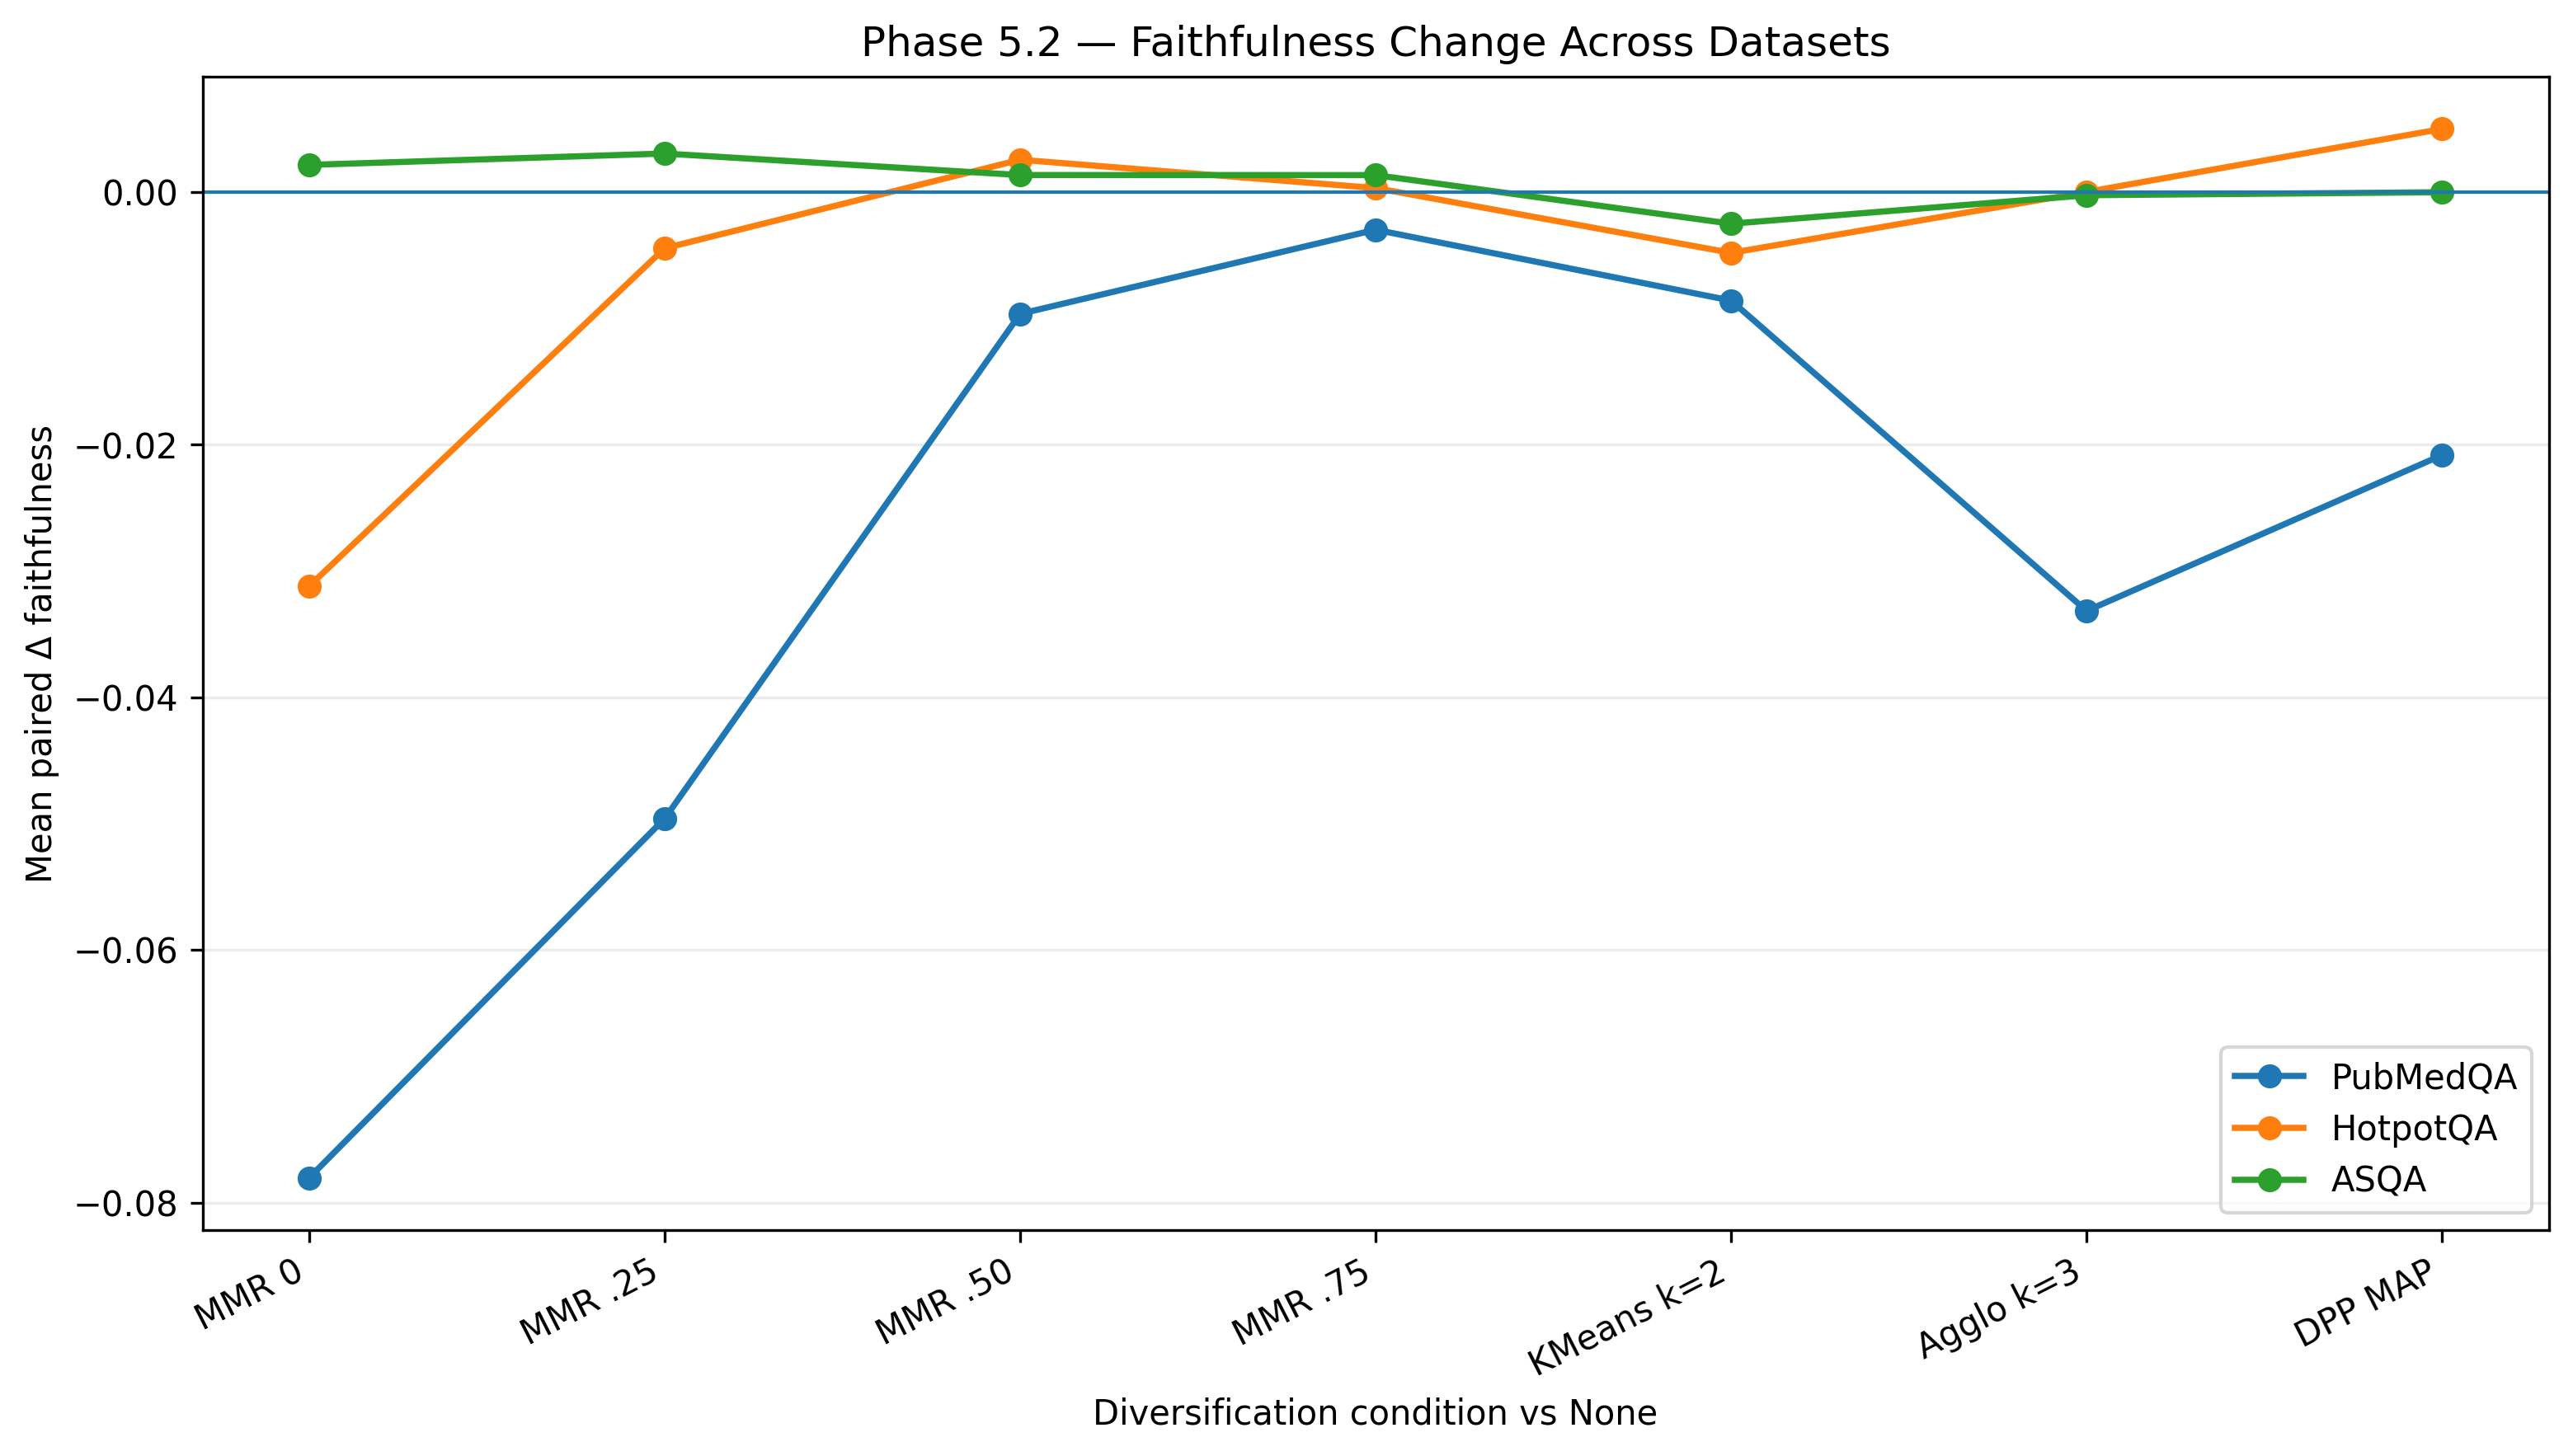

F19


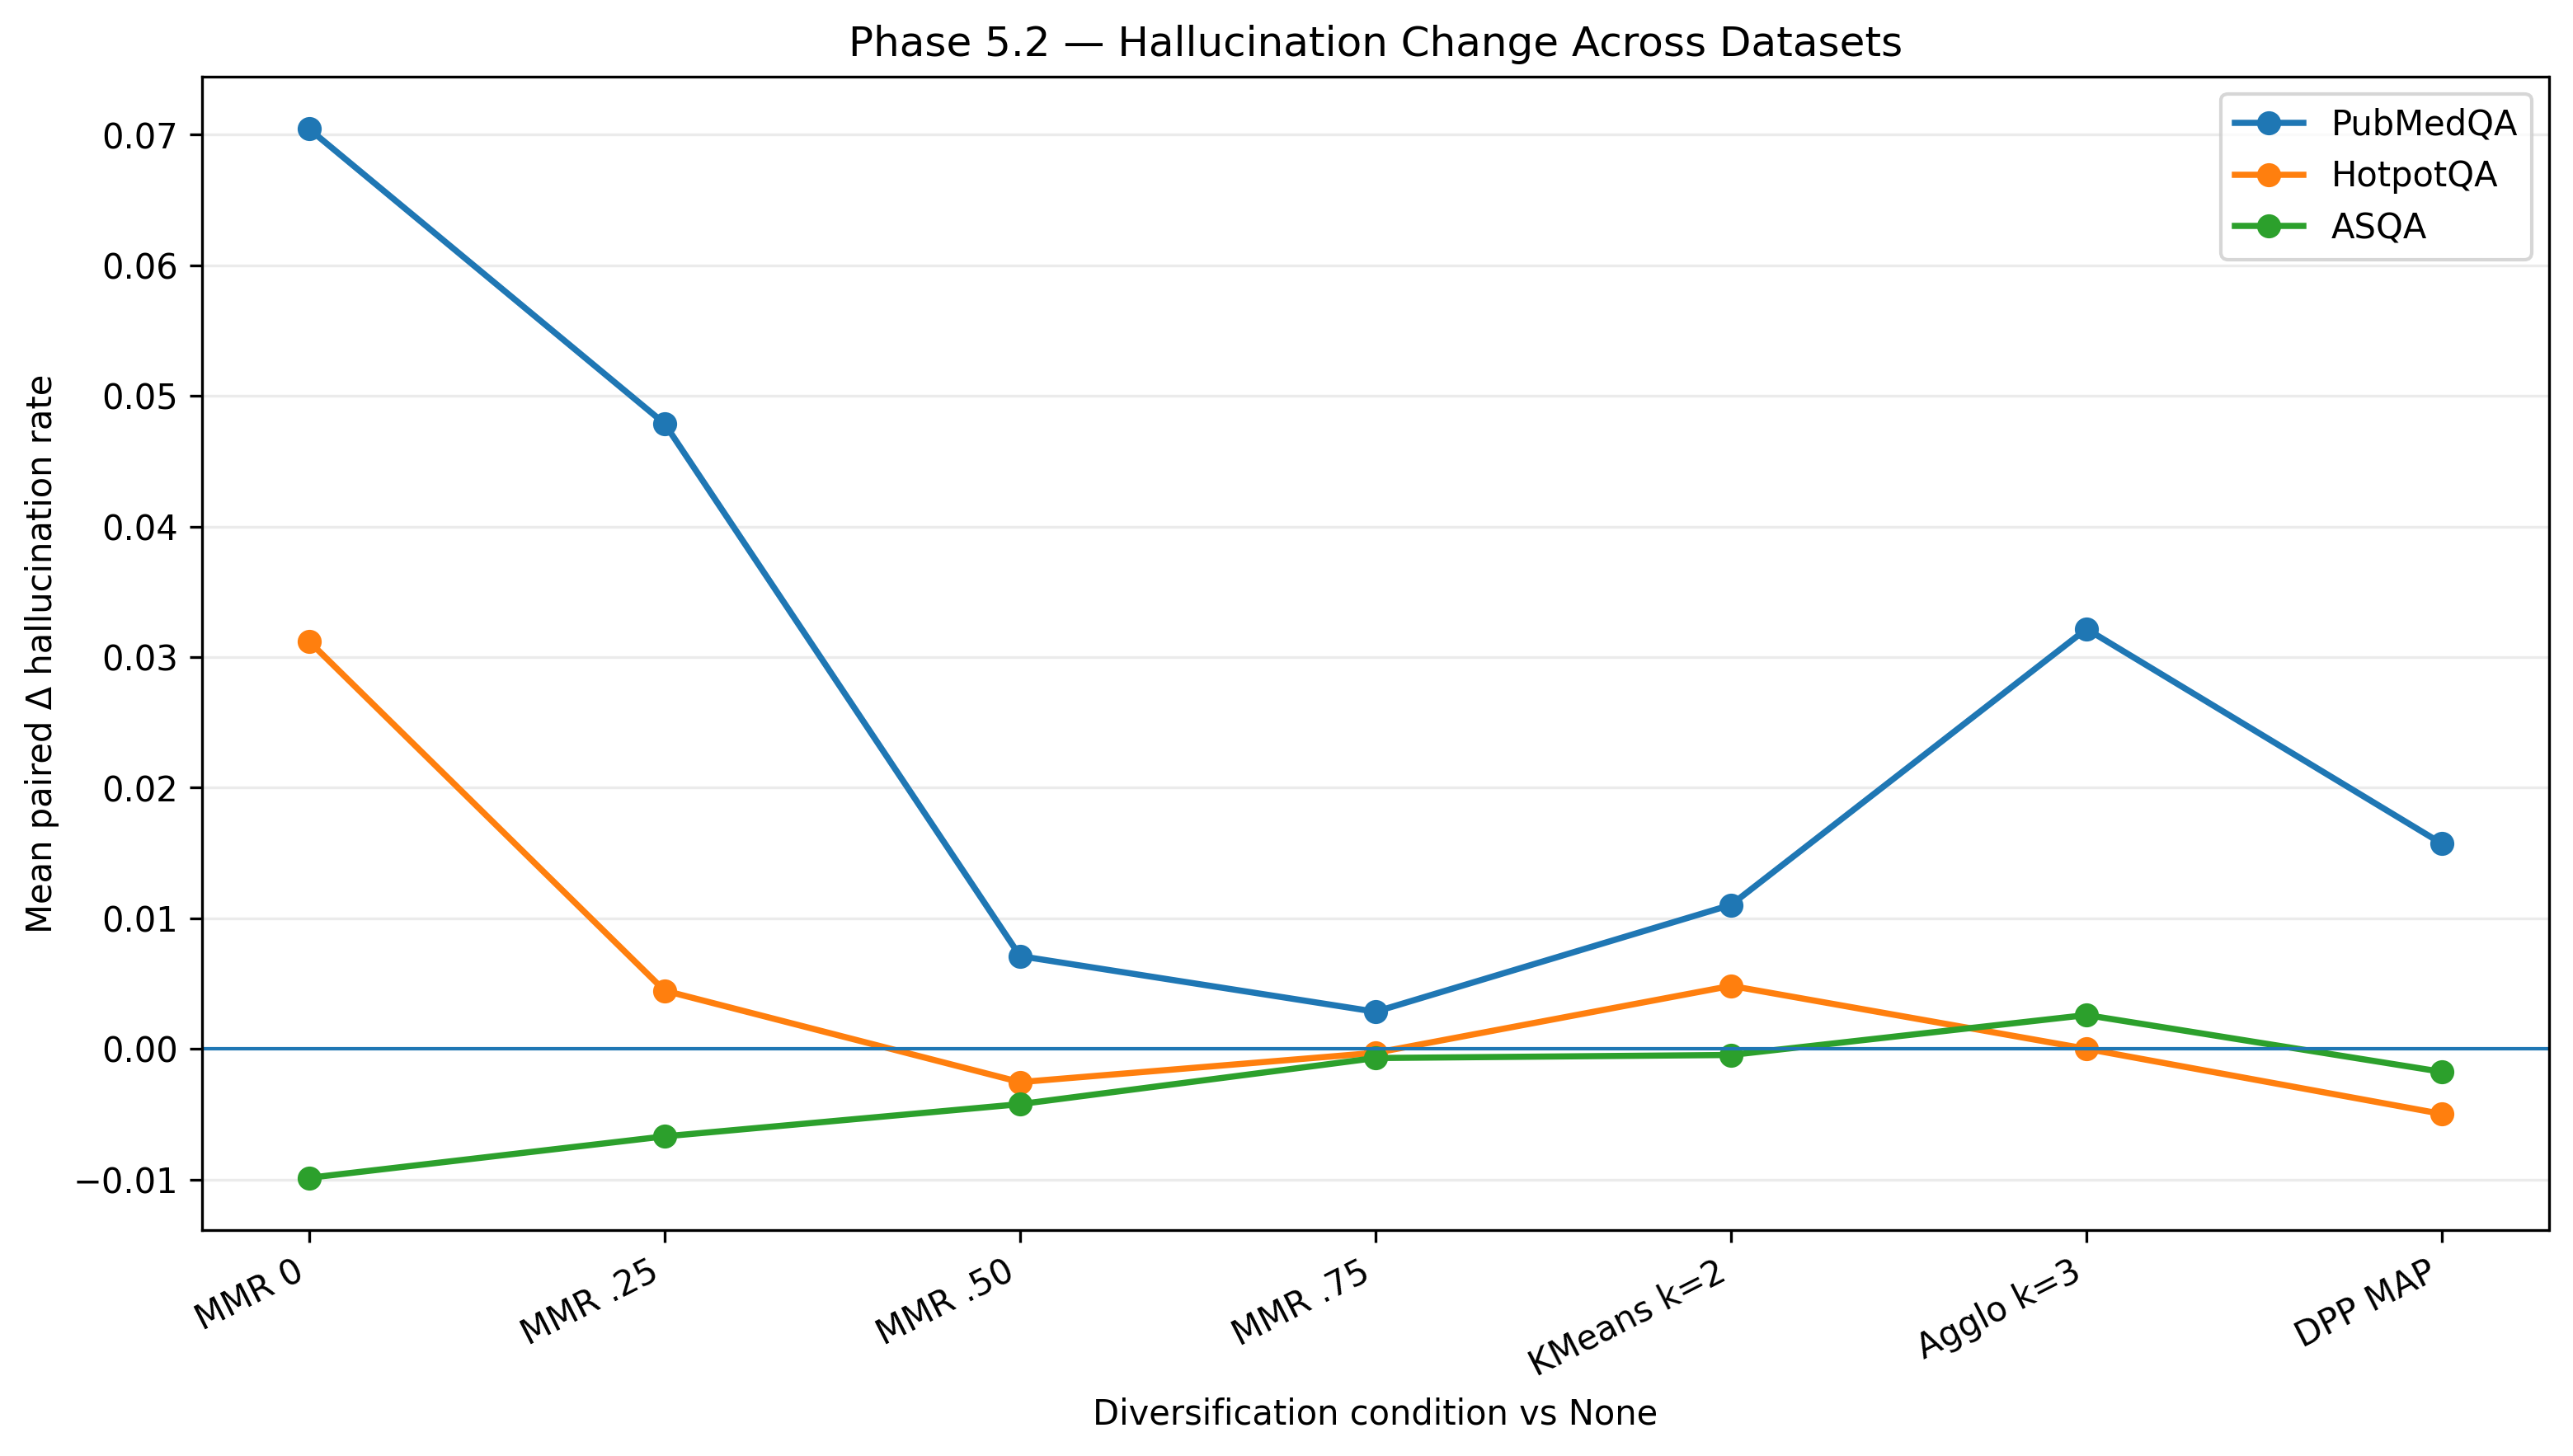

In [17]:
for fid in ["F18", "F19"]:
    print(fid)
    show_figure(fid)


The frozen paired evidence is configuration-dependent.

No stable project-wide rule emerges that greater retrieval diversity necessarily increases faithfulness or necessarily lowers hallucination.


## 10. Phase 5.3 — Context diversity versus output diversity

This phase distinguishes two different questions:

1. **Cross-sectional association:** do configurations with more diverse retrieved contexts also tend to produce more diverse answers?
2. **Paired intervention association:** when diversification changes context diversity relative to `none`, does the answer diversity change in the same direction?


In [18]:
phase53_ops = load_csv("phase53_operating_point_summary.csv")
phase53_paired = load_csv("phase53_paired_summary_vs_none.csv")
phase53_row_assoc = load_csv("phase53_row_level_associations.csv")
phase53_delta_assoc = load_csv("phase53_paired_delta_associations.csv")

print("Operating points:")
display(phase53_ops.head(15))

print("Paired comparisons:")
display(phase53_paired.head(15))

print("Cross-sectional associations:")
display(phase53_row_assoc)

print("Paired delta associations:")
display(phase53_delta_assoc)


Operating points:


,retriever,condition,logical_model_id,physical_model_id,n,mean_sentence_count,mean_retrieval_diversity,std_retrieval_diversity,mean_output_diversity,std_output_diversity,median_output_diversity
0,bm25,none,gemma4-26b,gemma4-26b,376,2.382979,0.582092,0.113474,0.375877,0.116026,0.364810
1,bm25,mmr_0,gemma4-26b,gemma4-26b,353,2.274788,0.718923,0.075499,0.377510,0.105603,0.367605
2,bm25,mmr_0.25,gemma4-26b,gemma4-26b,360,2.330556,0.678883,0.083639,0.370862,0.115628,0.362186
3,bm25,mmr_0.5,gemma4-26b,gemma4-26b,366,2.374317,0.621211,0.107755,0.374788,0.120795,0.358821
4,bm25,mmr_0.75,gemma4-26b,gemma4-26b,376,2.313830,0.593120,0.108964,0.376449,0.121605,0.360297
5,bm25,kmeans_k2,gemma4-26b,gemma4-26b,347,2.345821,0.616491,0.103821,0.384254,0.125371,0.371868
6,bm25,agglo_k3,gemma4-26b,gemma4-26b,350,2.371429,0.616925,0.093953,0.383597,0.114306,0.373020
7,bm25,dpp_map,gemma4-26b,gemma4-26b,369,2.398374,0.647844,0.086485,0.380437,0.116778,0.365265
8,bm25,none,llama-3.3-70b,llama-3.3-70b,756,3.630952,0.583664,0.115365,0.379639,0.103725,0.372966
9,bm25,mmr_0,llama-3.3-70b,llama-3.3-70b,758,3.530343,0.721751,0.077061,0.383974,0.103737,0.376837


Paired comparisons:


,retriever,condition,logical_model_id,physical_model_id,n_pairs,mean_delta_retrieval_diversity,median_delta_retrieval_diversity,mean_delta_output_diversity,median_delta_output_diversity,mean_delta_sentence_count,fraction_output_diversity_increased,fraction_output_diversity_decreased,fraction_output_diversity_unchanged
0,bm25,mmr_0,gemma4-26b,gemma4-26b,211,0.130994,0.124408,0.004276,0.000000,-0.132701,0.497630,0.483412,0.018957
1,bm25,mmr_0.25,gemma4-26b,gemma4-26b,254,0.092346,0.077808,-0.004980,0.005196,-0.090551,0.531496,0.452756,0.015748
2,bm25,mmr_0.5,gemma4-26b,gemma4-26b,271,0.040883,0.026453,0.004435,0.001675,-0.047970,0.516605,0.439114,0.044280
3,bm25,mmr_0.75,gemma4-26b,gemma4-26b,311,0.015475,0.000000,0.006037,0.000000,-0.054662,0.495177,0.456592,0.048232
4,bm25,kmeans_k2,gemma4-26b,gemma4-26b,250,0.025972,0.008588,0.000146,0.000000,-0.080000,0.492000,0.472000,0.036000
5,bm25,agglo_k3,gemma4-26b,gemma4-26b,248,0.035860,0.020735,0.004738,0.000000,-0.044355,0.491935,0.495968,0.012097
6,bm25,dpp_map,gemma4-26b,gemma4-26b,270,0.067520,0.054459,0.001384,0.000867,-0.014815,0.514815,0.440741,0.044444
7,bm25,mmr_0,llama-3.3-70b,llama-3.3-70b,678,0.138293,0.125705,0.002511,0.002174,-0.129794,0.510324,0.483776,0.005900
8,bm25,mmr_0.25,llama-3.3-70b,llama-3.3-70b,689,0.095939,0.079695,0.003444,0.000000,0.027576,0.490566,0.473149,0.036284
9,bm25,mmr_0.5,llama-3.3-70b,llama-3.3-70b,697,0.045726,0.029046,-0.001002,0.000000,-0.053085,0.420373,0.421808,0.157819


Cross-sectional associations:


,scope,retriever,logical_model_id,n,pearson_r,spearman_rho,mean_retrieval_diversity,mean_output_diversity
0,overall,NaN,NaN,44993,0.129185,0.122233,0.612831,0.390444
1,retriever,bm25,NaN,15009,0.125366,0.119267,0.635273,0.389356
2,retriever,contriever,NaN,15546,0.092541,0.090037,0.618063,0.388672
3,retriever,dpr,NaN,14438,0.189672,0.184711,0.583866,0.393484
4,logical_model,NaN,gemma4-26b,8753,0.053704,0.043601,0.610491,0.385110
5,logical_model,NaN,llama-3.3-70b,17889,0.141770,0.139670,0.614118,0.379799
6,logical_model,NaN,ministral-3-14b,18351,0.159275,0.148645,0.612691,0.403365
7,retriever_x_logical_model,bm25,gemma4-26b,2897,0.075641,0.082521,0.633870,0.377906
8,retriever_x_logical_model,bm25,llama-3.3-70b,6044,0.137464,0.130493,0.638252,0.379879
9,retriever_x_logical_model,bm25,ministral-3-14b,6068,0.146432,0.136348,0.632976,0.404260


Paired delta associations:


,scope,retriever,logical_model_id,n_pairs,pearson_r_delta,spearman_rho_delta,mean_delta_retrieval_diversity,mean_delta_output_diversity
0,overall,NaN,NaN,34725,0.018586,0.022035,0.058759,0.000278
1,retriever,bm25,NaN,11569,0.019046,0.030486,0.059272,0.000521
2,retriever,contriever,NaN,12081,-0.002117,0.005372,0.050158,-0.001023
3,retriever,dpr,NaN,11075,0.034534,0.028788,0.067604,0.001443
4,logical_model,NaN,gemma4-26b,5531,0.006174,0.005343,0.055898,0.000331
5,logical_model,NaN,llama-3.3-70b,14452,0.033254,0.030604,0.059125,0.000214
6,logical_model,NaN,ministral-3-14b,14742,0.009559,0.020283,0.059473,0.000321
7,retriever_x_logical_model,bm25,gemma4-26b,1815,-0.024595,-0.005673,0.055429,0.002370
8,retriever_x_logical_model,bm25,llama-3.3-70b,4895,0.075978,0.059445,0.060128,-0.000486
9,retriever_x_logical_model,bm25,ministral-3-14b,4859,-0.020592,0.013060,0.059846,0.000845


F20


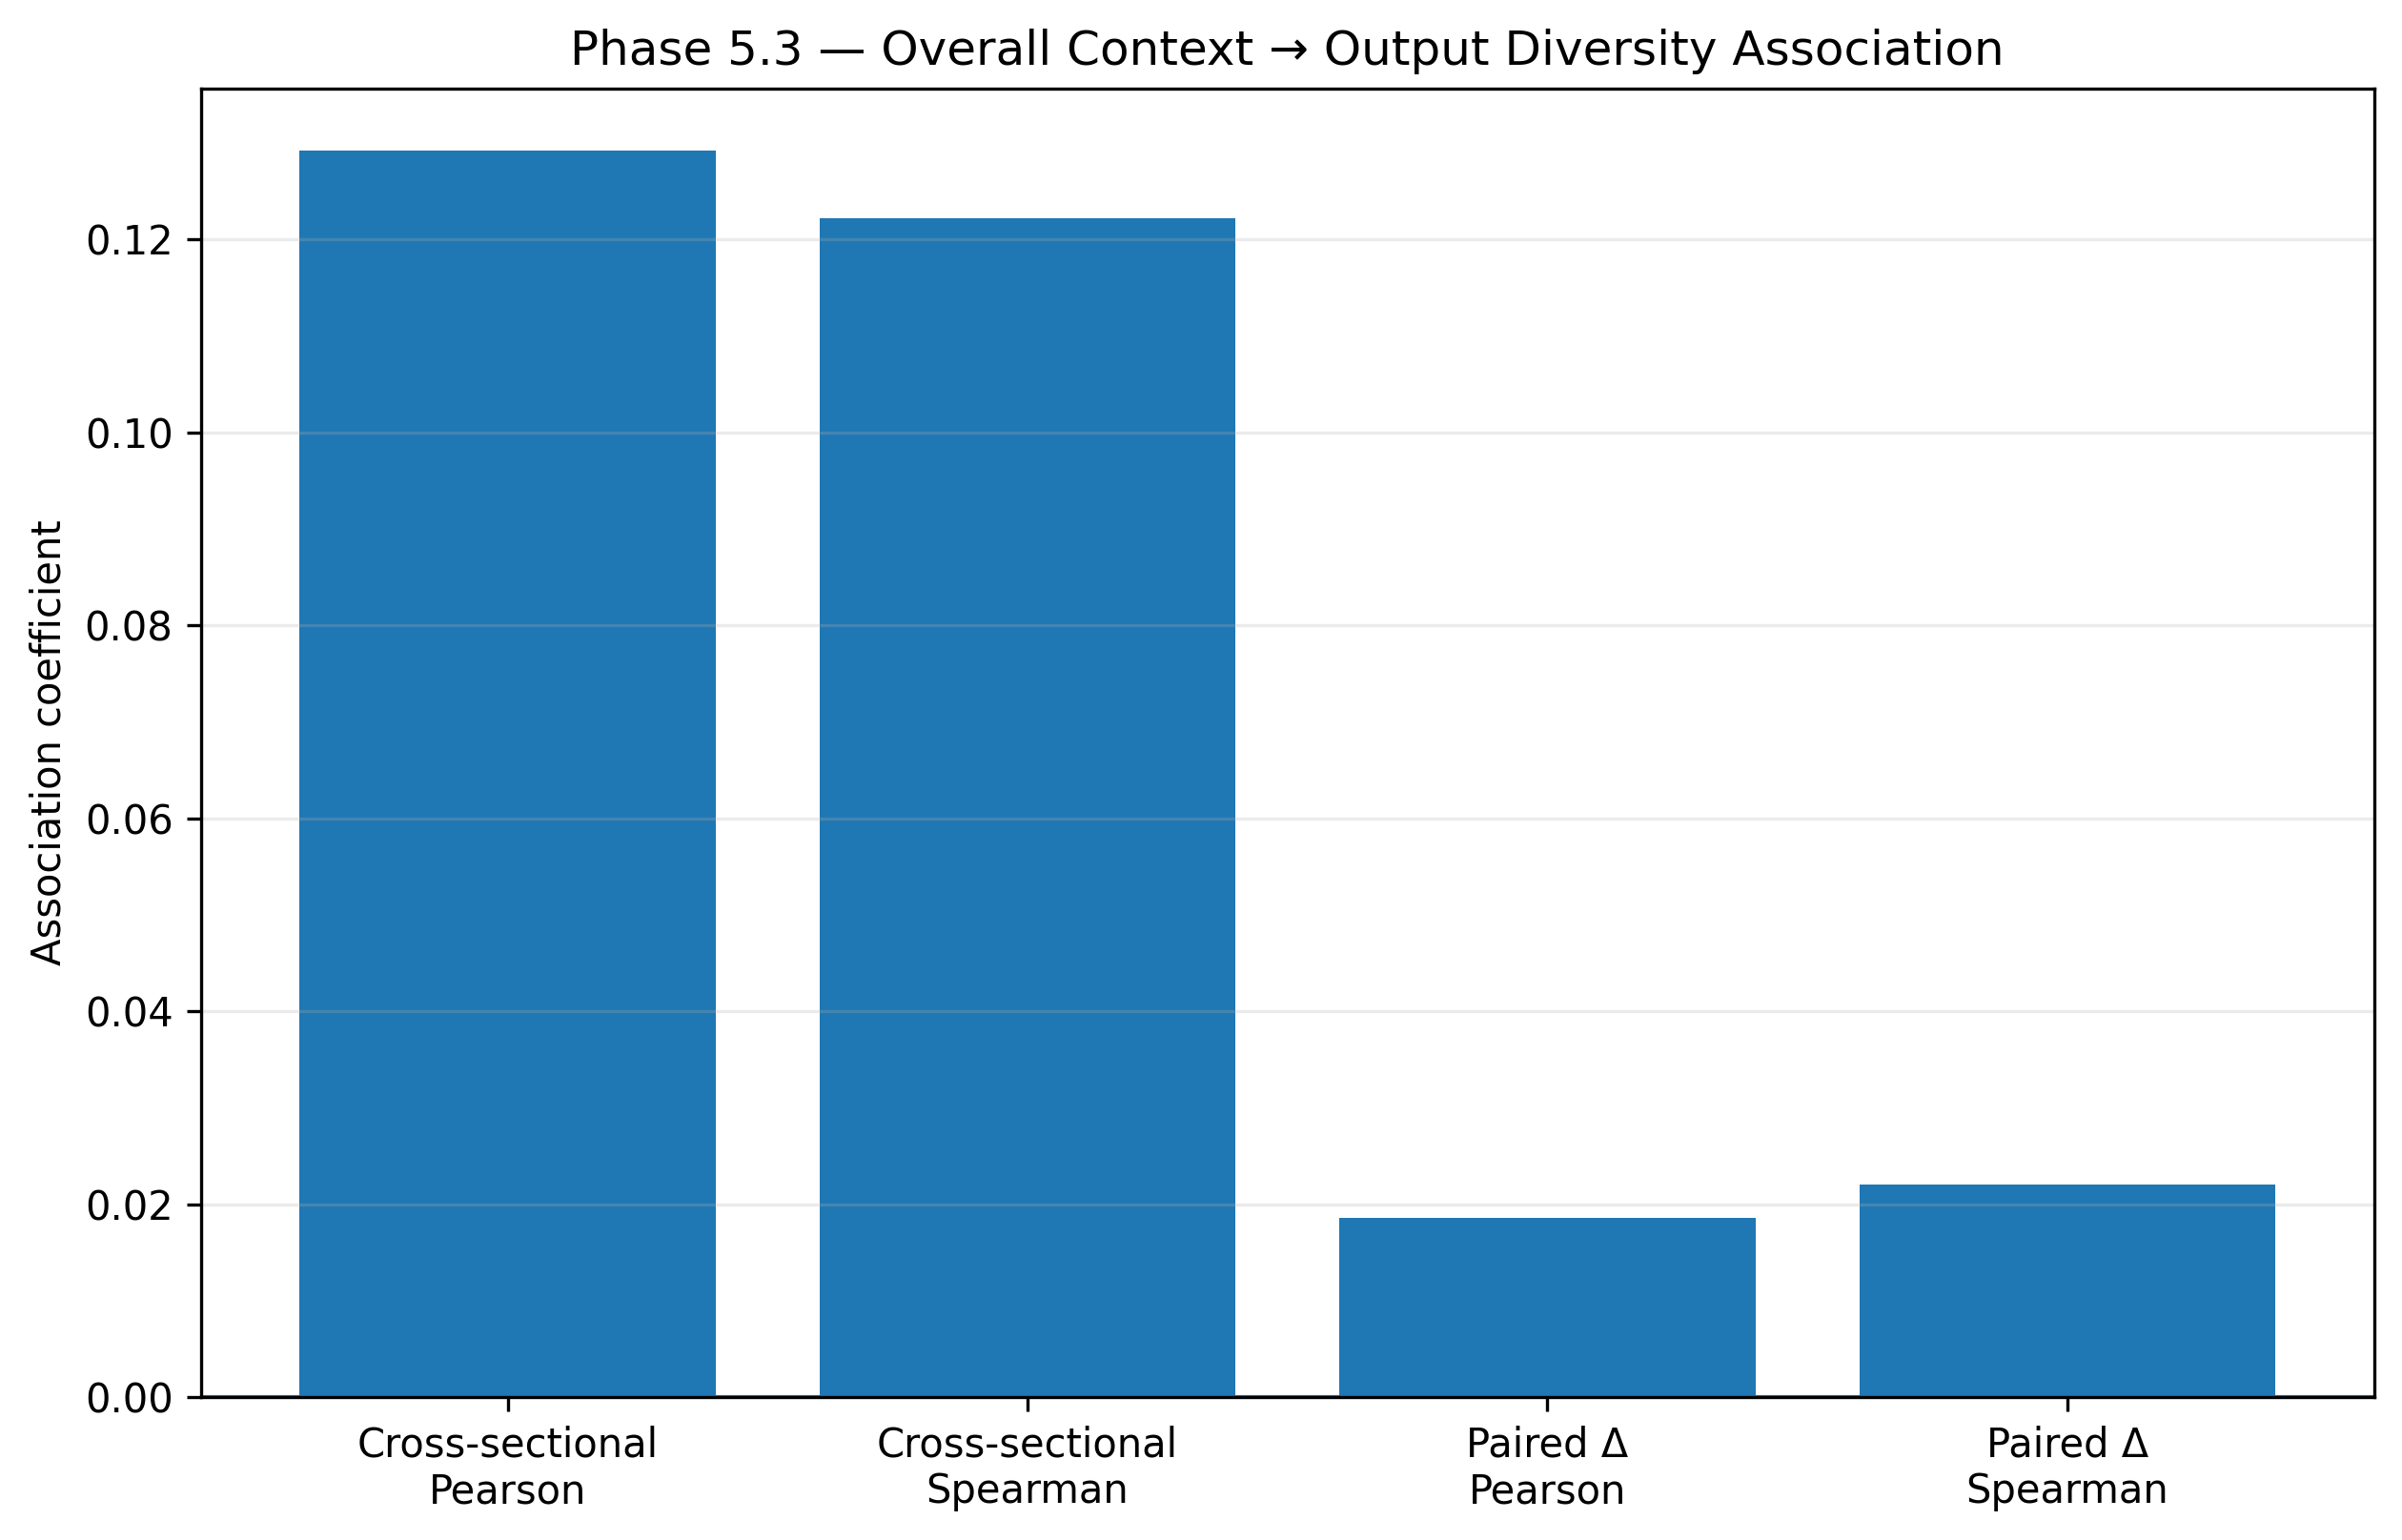

F21


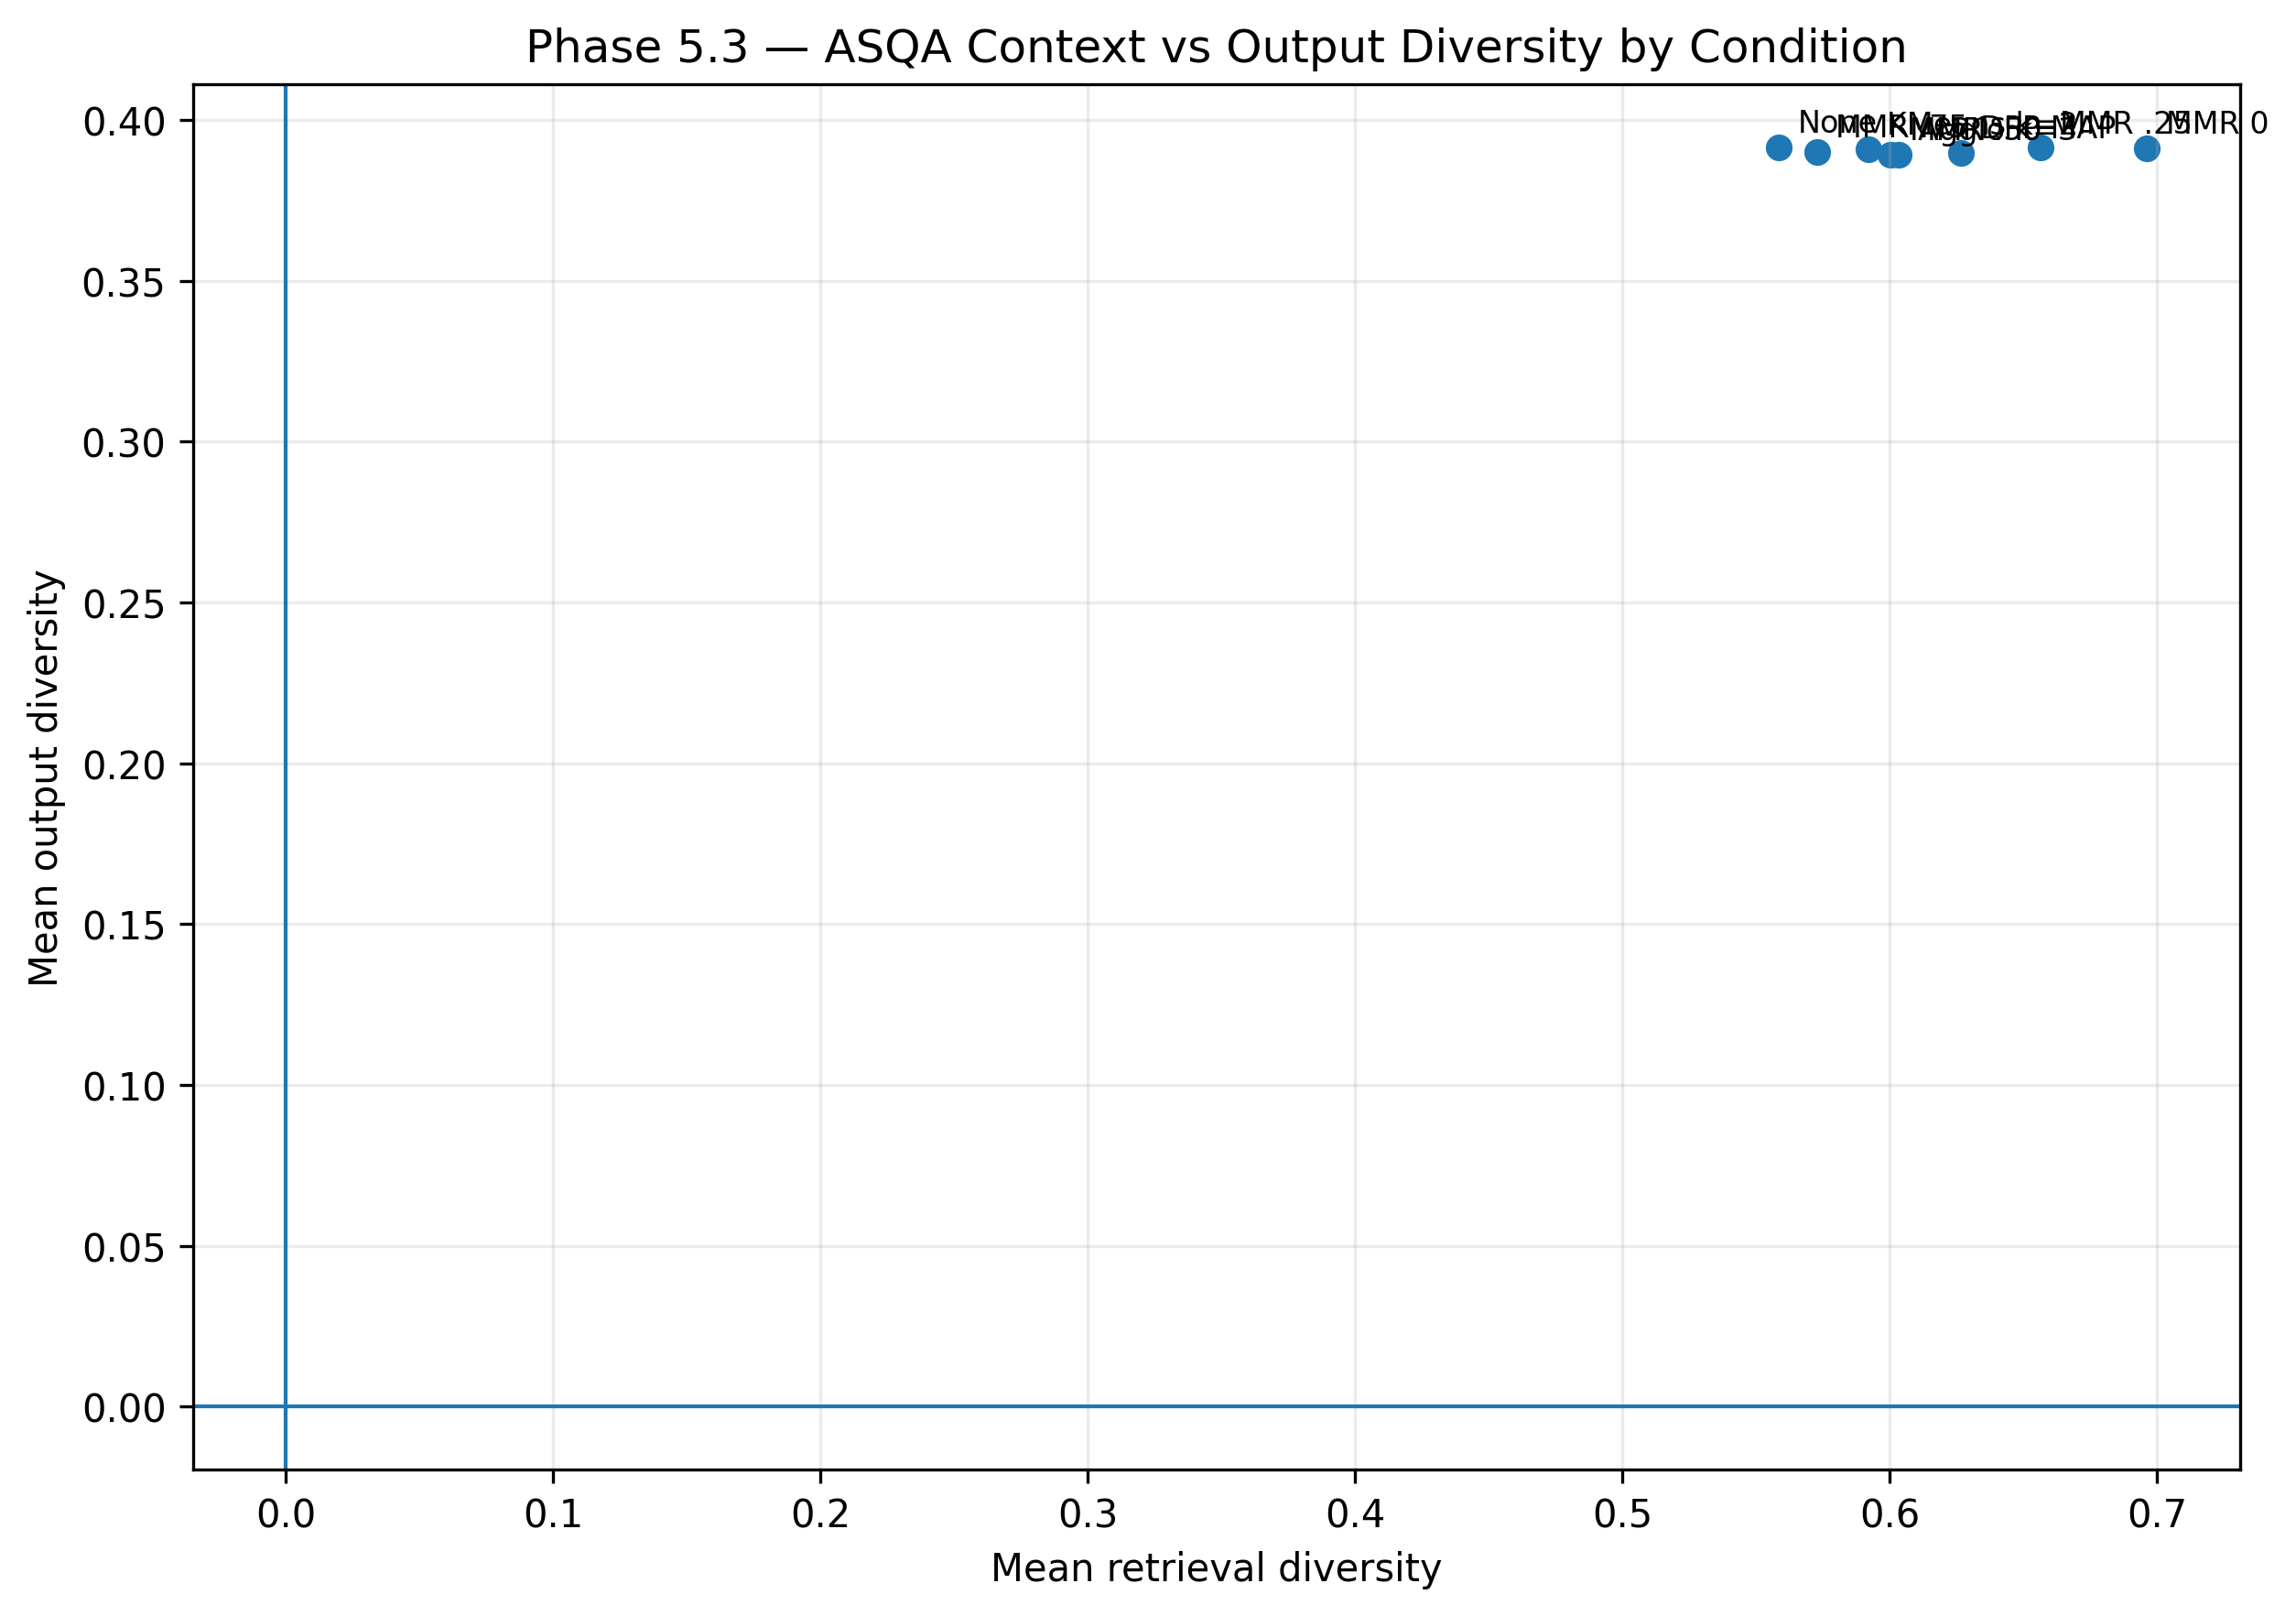

In [19]:
for fid in ["F20", "F21"]:
    print(fid)
    show_figure(fid)


The frozen Phase 5.3 result shows a **weak positive cross-sectional relationship** between context diversity and output diversity, but the paired intervention relationship is close to flat.

Therefore, configurations that are diverse in context space may also appear somewhat diverse in output space, while directly increasing retrieval diversity does not reliably cause a meaningful increase in output diversity.


## 11. Phase 5.4 — Paraphrase robustness

This is a **DEVELOPMENT-scope** robustness analysis on 30 human-validated ASQA paraphrase pairs.

Jaccard overlap measures retrieval invariance under paraphrasing:

- higher Jaccard = more invariant retrieval
- it is **not** a retrieval-quality score


In [20]:
phase54 = load_json("phase54_asqa_robustness_summary_v1.json")

print("Phase:", phase54["phase"])
print("Role:", phase54["role"])
print(
    "Validated paraphrase pairs:",
    phase54["validated_paraphrase_pairs"]
)

display(
    pd.DataFrame(phase54["retrievers"]).T
)

print("Overall pooled:")
display(pd.Series(phase54["overall_pooled"]))


Phase: 5.4
Role: DEVELOPMENT
Validated paraphrase pairs: 30


,mean_jaccard_at20,mean_jaccard_at5_mmr_0.5,mean_jaccard_at5_none,n,ordered_top5_identity_rate_mmr_0.5,ordered_top5_identity_rate_none
bm25,0.307432,0.245503,0.263228,30.0,0.033333,0.033333
contriever,0.502374,0.453836,0.498016,30.0,0.000000,0.033333
dpr,0.544559,0.529762,0.503836,30.0,0.066667,0.000000


Overall pooled:


mean_jaccard_at20                      0.451455
mean_jaccard_at5_mmr_0.5               0.409700
mean_jaccard_at5_none                  0.421693
n                                     90.000000
ordered_top5_identity_rate_mmr_0.5     0.033333
ordered_top5_identity_rate_none        0.022222
dtype: float64

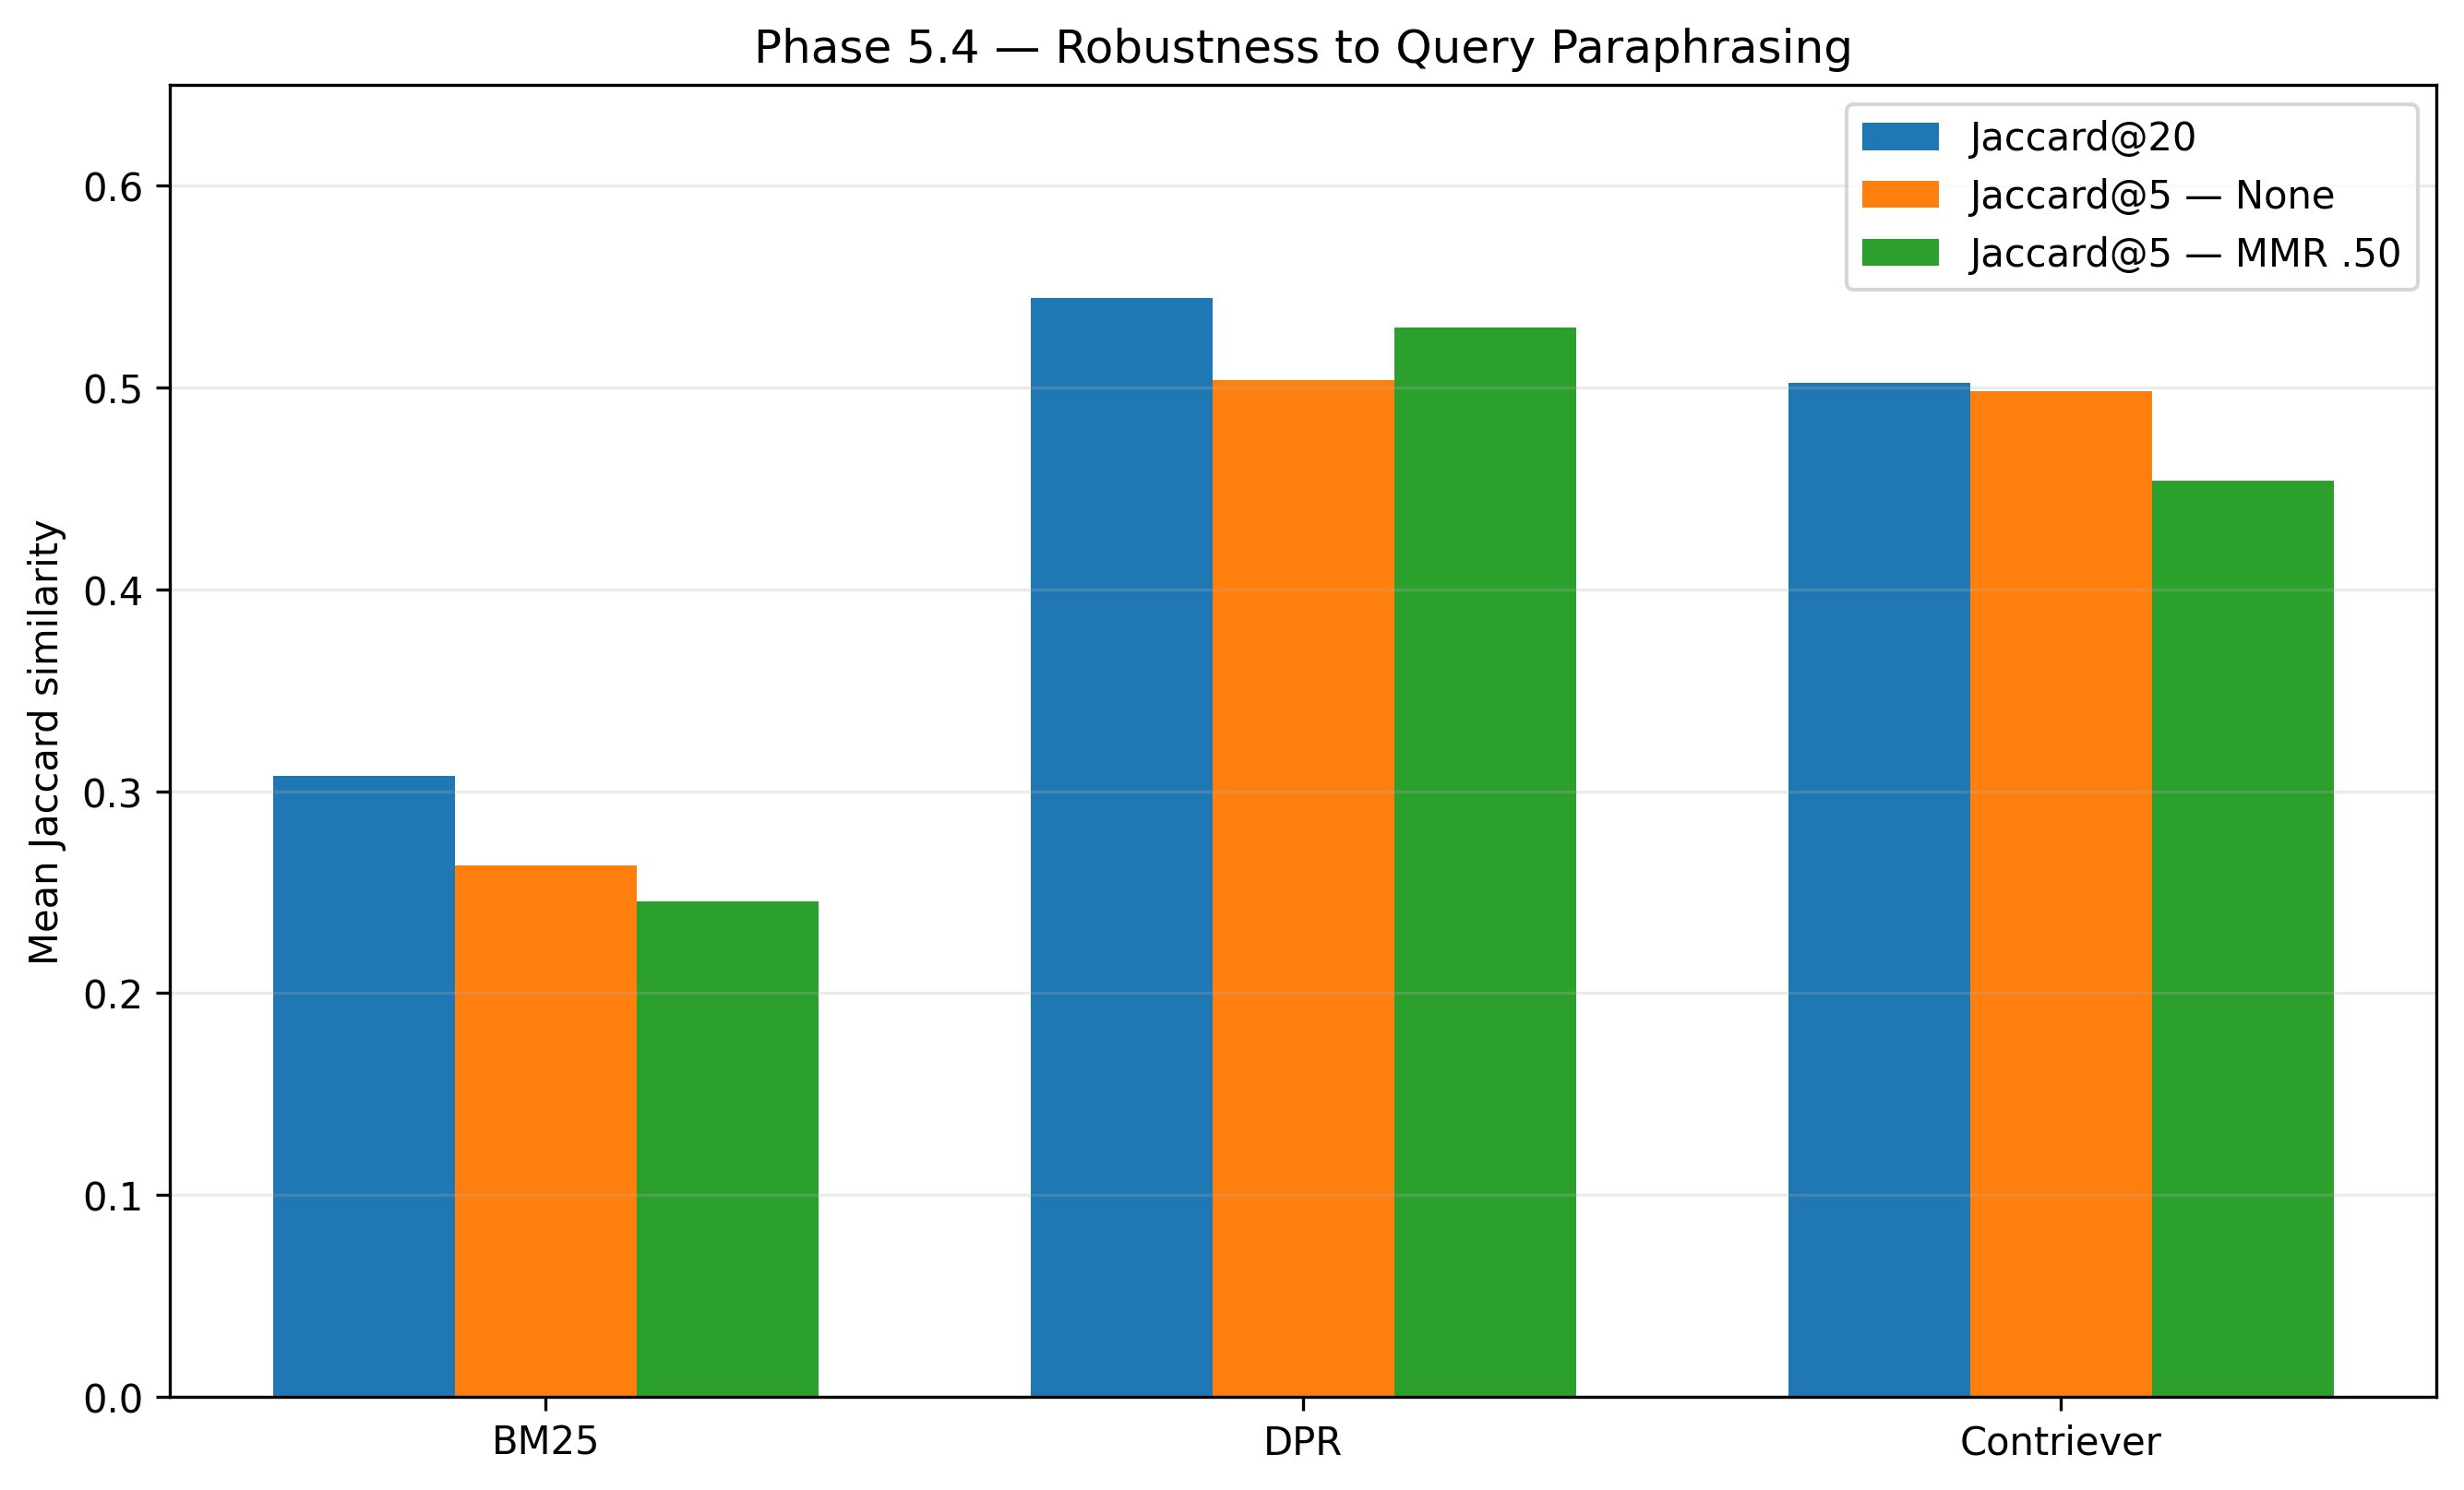

In [21]:
show_figure("F22")


The robustness analysis is retriever-dependent.

MMR 0.5 does not consistently make retrieval more invariant to paraphrasing: DPR improves in the frozen comparison, while BM25 and Contriever do not show the same pattern.

This phase is developmental evidence and is not presented as a protected-final generation result.


# 12. Overall findings

The frozen project evidence supports the following conclusions:

1. **Diversification successfully changes retrieved evidence composition.**
2. **More diversity can reduce relevance or supporting-evidence coverage.**
3. **Downstream correctness effects are configuration-dependent.**
4. **Faithfulness and hallucination do not show a consistent universal improvement from diversification.**
5. **ASQA output diversity has only a weak cross-sectional relationship with context diversity, while the paired intervention relationship is close to flat.**
6. **Paraphrase robustness is imperfect and retriever-dependent.**
7. The project therefore supports a **trade-off view** rather than “diversity is always better” or “diversity is always worse.”


# 13. Reporting limitations

The final notebook preserves the frozen project boundaries:

- ASQA ColBERTv2 final full-corpus experiments were not completed.
- Protected-final ASQA `S-Recall@5`, `alpha-nDCG@5`, coverability and `c*` numeric artifacts are unavailable and are not reconstructed.
- ASQA STR-EM / STR-Hit are answer-side metrics, not retrieval aspect-coverage metrics.
- Retrieval diversity is an embedding-based manipulation diagnostic.
- Phase 5.4 uses 30 human-validated ASQA DEVELOPMENT paraphrase pairs.
- Output-diversity evaluation excludes answers with fewer than two sentences.
- Historical generator alias `ministral-3-14b` physically corresponds to Qwen 3.6 36B in the final project reporting.
- Historical Sprint 1 outputs are not substituted for later controlled final evaluation results.


In [22]:
# Final structural validation only.
assert len(package_manifest) == 51
assert (
    package_manifest["package_group"]
    .value_counts()
    .to_dict()
    == {
        "PRIMARY_RESULT": 22,
        "FROZEN_FIGURE": 22,
        "SOURCE_OF_TRUTH": 7,
    }
)

expected_figures = {f"F{i:02d}" for i in range(1, 23)}

observed_figures = set(
    package_manifest.loc[
        package_manifest["package_group"] == "FROZEN_FIGURE",
        "phase_or_id",
    ]
)

assert observed_figures == expected_figures

for relative_path in package_manifest["relative_path"]:
    assert (PKG / relative_path).is_file()

print("SPRINT3_NOTEBOOK_DATA_VALIDATION=PASS")
print("SCIENTIFIC_RERUN=NO")
print("METRIC_RECOMPUTATION=NO")
print("RETRIEVAL_RERUN=NO")
print("GENERATION_RERUN=NO")
print("EMBEDDING_RERUN=NO")
print("PLOT_REGENERATION=NO")


SPRINT3_NOTEBOOK_DATA_VALIDATION=PASS
SCIENTIFIC_RERUN=NO
METRIC_RECOMPUTATION=NO
RETRIEVAL_RERUN=NO
GENERATION_RERUN=NO
EMBEDDING_RERUN=NO
PLOT_REGENERATION=NO
